# mcPHASES-ML Pipeline
**Multimodal Temporal Representation Learning for Personalized Menstrual Cycle Modeling**

Annie Luo | Computer Science | Wake Forest University

---
## Part 1: Exploratory Data Analysis (EDA)

Sections:
- 1.1 Load all CSV files
- 1.2 Shape & data types audit
- 1.3 Missing value analysis (per-file + per-participant)
- 1.4 Participant coverage across modalities
- 1.5 Hormone distributions (LH, estrogen, PDG)
- 1.6 Wearable signal time series plots
- 1.7 Phase label distribution & balance
- 1.8 Cross-modal correlation matrix

In [2]:
# ============================================================
# Cell 1.0 — Imports & Config (FIXED)
# ============================================================
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ 直接用你已经确认过的正确路径
DATA_DIR = "/Users/luozixiao/Desktop/mcphases/mcphases"

# ── sanity check ─────────────────────────────────────────────
if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(f"DATA_DIR not found: {DATA_DIR}")

print("DATA_DIR exists ✓")

# 看看里面到底有什么（防止再错）
print("Sample files:", os.listdir(DATA_DIR)[:5])

# ── plotting style ──────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})

DATA_DIR exists ✓
Sample files: ['sleep_score.csv', 'wrist_temperature.csv', 'stress_score.csv', 'computed_temperature.csv', 'demographic_vo2_max.csv']


In [3]:
# ============================================================
# Cell 1.1 — Load all CSV files into a dictionary
# ============================================================
# We store each CSV as dfs[filename_without_extension]
# This makes it easy to inspect any table later.

CSV_FILES = [
    'active_minutes',
    'active_zone_minutes',
    'altitude',
    'calories',
    'computed_temperature',
    'demographic_vo2_max',
    'distance',
    'estimated_oxygen_variation',
    'exercise',
    'glucose',
    'heart_rate',
    'heart_rate_variability_details',
    'height_and_weight',
    'hormones_and_selfreport',
    'respiratory_rate_summary',
    'resting_heart_rate',
    'sleep',
    'sleep_score',
    'steps',
    'stress_score',
    'subject-info',
    'time_in_heart_rate_zones',
    'wrist_temperature',
]

dfs = {}
missing_files = []

for name in CSV_FILES:
    path = os.path.join(DATA_DIR, f'{name}.csv')
    if os.path.exists(path):
        dfs[name] = pd.read_csv(path, low_memory=False)
        print(f'  ✓  {name:<40}  {dfs[name].shape}')
    else:
        missing_files.append(name)
        print(f'  ✗  {name:<40}  FILE NOT FOUND')

print(f'\nLoaded: {len(dfs)}/{len(CSV_FILES)} files')
if missing_files:
    print(f'Missing: {missing_files}')

  ✓  active_minutes                            (5552, 8)
  ✓  active_zone_minutes                       (154482, 7)
  ✓  altitude                                  (90878, 6)
  ✓  calories                                  (20166975, 6)
  ✓  computed_temperature                      (5575, 14)
  ✓  demographic_vo2_max                       (11482, 8)
  ✓  distance                                  (7666949, 6)
  ✓  estimated_oxygen_variation                (3070312, 6)
  ✓  exercise                                  (7282, 26)
  ✓  glucose                                   (837130, 6)
  ✓  heart_rate                                (63100276, 7)
  ✓  heart_rate_variability_details            (436262, 9)
  ✓  height_and_weight                         (42, 5)
  ✓  hormones_and_selfreport                   (5659, 22)
  ✓  respiratory_rate_summary                  (6301, 17)
  ✓  resting_heart_rate                        (13737, 6)
  ✓  sleep                                     (14765, 18)
  ✓ 

In [4]:
# ============================================================
# Cell 1.2 — Shape & Data Types Audit
# ============================================================
# Why: 确认每个file有多少rows/columns，
# 以及primary key (id, day_in_study) 是否存在。

audit_rows = []
for name, df in dfs.items():
    has_id       = 'id' in df.columns
    has_day      = 'day_in_study' in df.columns
    has_ts       = 'timestamp' in df.columns
    n_participants = df['id'].nunique() if has_id else np.nan
    audit_rows.append({
        'table':         name,
        'rows':          len(df),
        'columns':       df.shape[1],
        'has_id':        has_id,
        'has_day':       has_day,
        'has_timestamp': has_ts,
        'n_participants': n_participants,
    })

audit = pd.DataFrame(audit_rows)

# ── display with colour coding ──────────────────────────────
def style_bool(v):
    color = 'color: green' if v else 'color: #cc4444'
    return color

display(
    audit.style
    .applymap(style_bool, subset=['has_id', 'has_day', 'has_timestamp'])
    .format({'rows': '{:,}', 'n_participants': '{:.0f}'})
    .set_caption('Table Audit — shape, keys, participant coverage')
)

,table,rows,columns,has_id,has_day,has_timestamp,n_participants
0,active_minutes,"5,552",8,True,True,False,42
1,active_zone_minutes,"154,482",7,True,True,True,42
2,altitude,"90,878",6,True,True,True,42
3,calories,"20,166,975",6,True,True,True,42
4,computed_temperature,"5,575",14,True,False,False,42
5,demographic_vo2_max,"11,482",8,True,True,False,42
6,distance,"7,666,949",6,True,True,True,42
7,estimated_oxygen_variation,"3,070,312",6,True,True,True,42
8,exercise,"7,282",26,True,False,False,31
9,glucose,"837,130",6,True,True,True,42


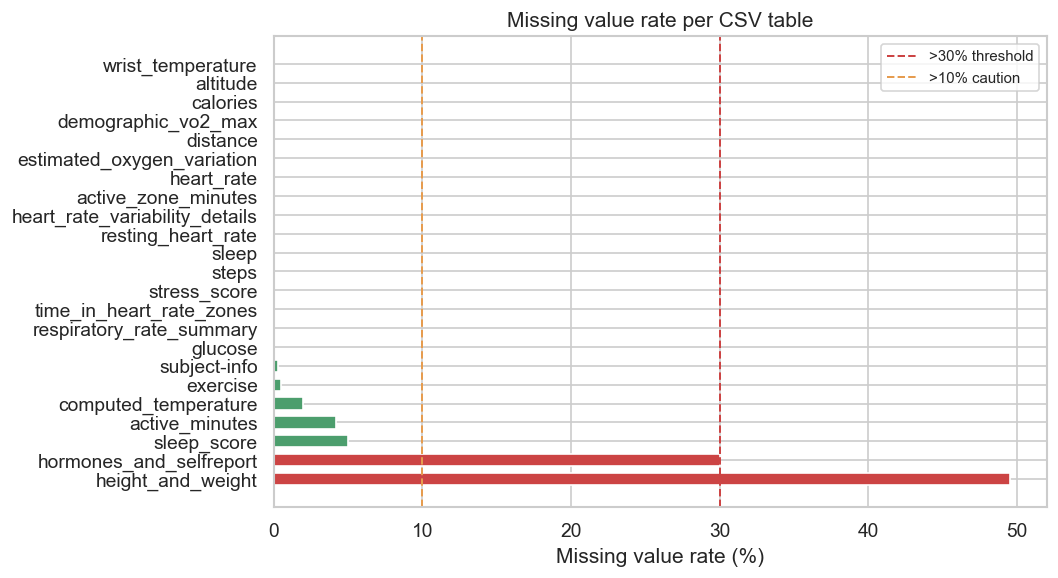


Tables with >30% missing:
                  table  miss_pct
      height_and_weight 49.523810
hormones_and_selfreport 30.001285


In [5]:
# ============================================================
# Cell 1.3a — Missing Value Rate per Table
# ============================================================
# Why: 我们需要知道每个table整体缺失率，
# 决定是否要impute / drop / flag。

missing_summary = []
for name, df in dfs.items():
    total_cells   = df.size
    missing_cells = df.isnull().sum().sum()
    pct           = 100 * missing_cells / total_cells if total_cells > 0 else 0
    missing_summary.append({
        'table':       name,
        'total_cells': total_cells,
        'missing':     missing_cells,
        'miss_pct':    pct
    })

miss_df = pd.DataFrame(missing_summary).sort_values('miss_pct', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#cc4444' if x > 30 else '#e69c4f' if x > 10 else '#4c9e6d'
          for x in miss_df['miss_pct']]
bars = ax.barh(miss_df['table'], miss_df['miss_pct'], color=colors, height=0.65)
ax.axvline(30, ls='--', color='#cc4444', lw=1.2, label='>30% threshold')
ax.axvline(10, ls='--', color='#e69c4f', lw=1.2, label='>10% caution')
ax.set_xlabel('Missing value rate (%)')
ax.set_title('Missing value rate per CSV table')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('\nTables with >30% missing:')
print(miss_df[miss_df['miss_pct'] > 30][['table', 'miss_pct']].to_string(index=False))

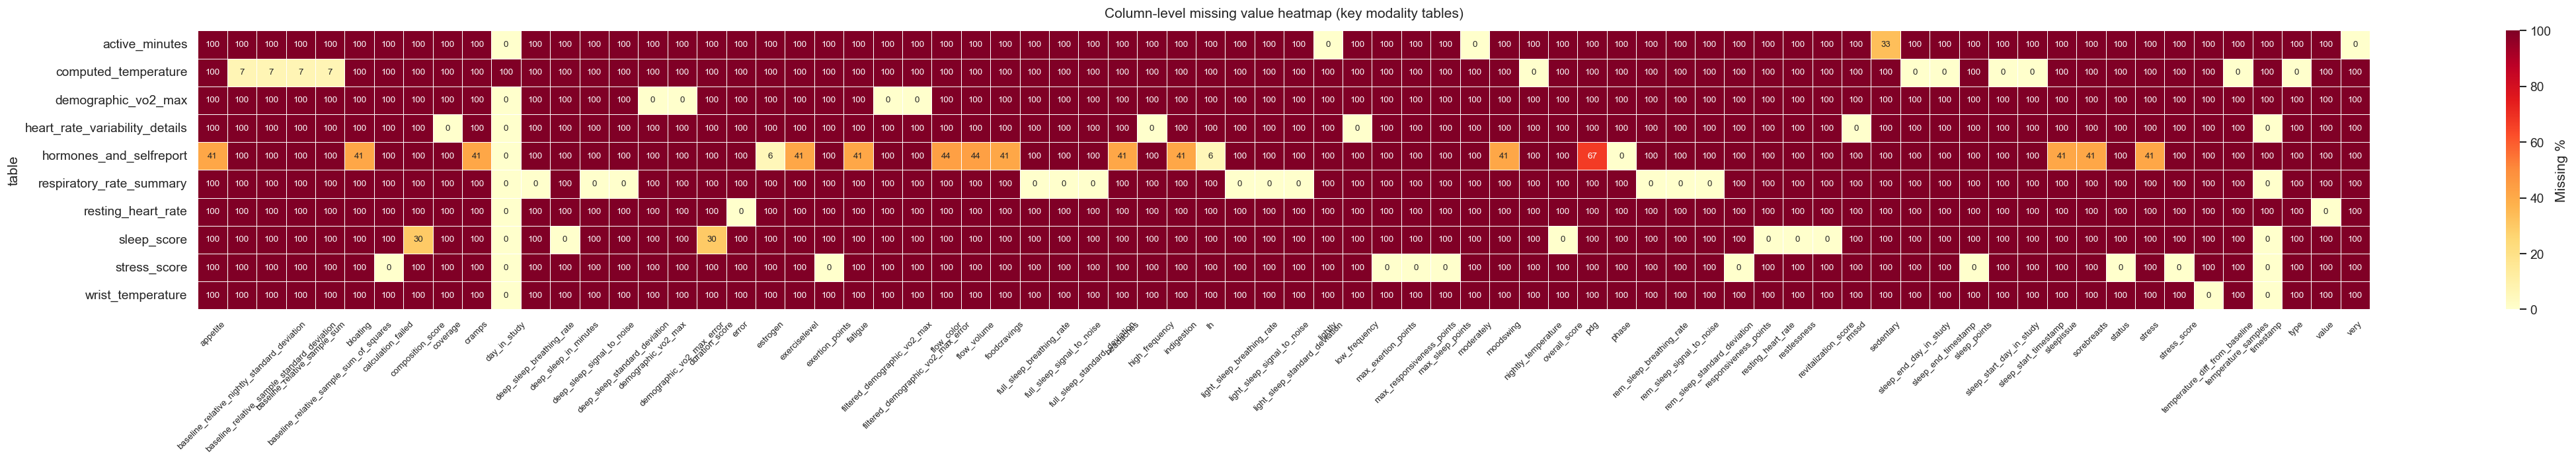

In [6]:
# ============================================================
# Cell 1.3b — Missing Value Heatmap (column-level)
# ============================================================
# Focus on the main modality tables we'll use for modeling.
# Why: 识别哪些specific columns缺失严重。

KEY_TABLES = [
    'hormones_and_selfreport',
    'resting_heart_rate',
    'heart_rate_variability_details',
    'computed_temperature',
    'wrist_temperature',
    'sleep_score',
    'active_minutes',
    'stress_score',
    'respiratory_rate_summary',
    'demographic_vo2_max',
]

# Build a combined column-level missing rate DataFrame
col_miss_rows = []
for tname in KEY_TABLES:
    if tname not in dfs:
        continue
    df = dfs[tname]
    for col in df.columns:
        pct = 100 * df[col].isnull().sum() / len(df)
        col_miss_rows.append({'table': tname, 'column': col, 'miss_pct': pct})

col_miss = pd.DataFrame(col_miss_rows)
pivot    = col_miss.pivot(index='table', columns='column', values='miss_pct').fillna(100)

# Only keep columns that appear in at least 2 tables or have >5% missing
pivot_filt = pivot.loc[:, (pivot > 5).any(axis=0)]

fig, ax = plt.subplots(figsize=(max(12, pivot_filt.shape[1] * 0.5),
                                max(5, pivot_filt.shape[0] * 0.6)))
sns.heatmap(
    pivot_filt,
    ax=ax,
    cmap='YlOrRd',
    vmin=0, vmax=100,
    linewidths=0.4,
    annot=True, fmt='.0f',
    annot_kws={'size': 8},
    cbar_kws={'label': 'Missing %'}
)
ax.set_title('Column-level missing value heatmap (key modality tables)', pad=12)
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout()
plt.show()

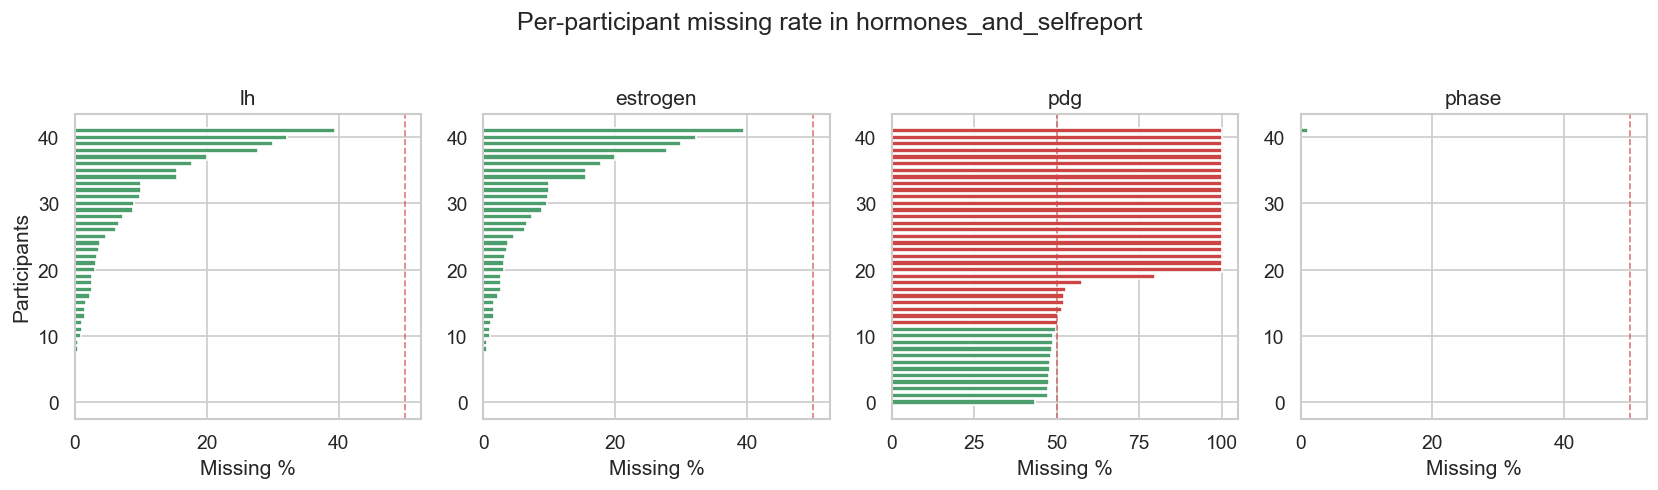


Participants with >50% missing in any hormone column: 30


,id,lh,estrogen,pdg,phase
0,1,3.333333,3.333333,100.000000,0.000000
1,2,0.000000,0.000000,100.000000,0.000000
2,3,10.000000,10.000000,100.000000,0.000000
3,4,15.555556,15.555556,100.000000,1.111111
4,6,10.000000,10.000000,100.000000,0.000000
5,7,0.000000,0.000000,100.000000,0.000000
6,8,32.222222,32.222222,100.000000,0.000000
8,10,6.285714,6.285714,57.714286,0.000000
9,11,15.555556,15.555556,100.000000,0.000000
13,15,0.000000,0.000000,100.000000,0.000000


In [7]:
# ============================================================
# Cell 1.3c — Per-participant Missing Rate
# ============================================================
# Why: 某些participants可能数据coverage很低，
# 需要在用户级split时排除或特殊处理。
# 重点看hormones_and_selfreport因为它是labels来源。

if 'hormones_and_selfreport' in dfs:
    hr = dfs['hormones_and_selfreport'].copy()

    # Columns we care about for modeling
    HORMONE_COLS = ['lh', 'estrogen', 'pdg', 'phase']
    SYMPTOM_COLS = ['appetite', 'fatigue', 'cramps', 'moodswing',
                    'bloating', 'stress', 'sleepissue', 'headaches',
                    'sorebreasts', 'foodcravings', 'indigestion']

    # Per-participant missing rate for hormone cols
    participant_miss = (
        hr.groupby('id')[HORMONE_COLS]
        .apply(lambda g: g.isnull().mean() * 100)
        .reset_index()
    )

    fig, axes = plt.subplots(1, len(HORMONE_COLS), figsize=(14, 4), sharey=False)
    for ax, col in zip(axes, HORMONE_COLS):
        sorted_vals = participant_miss[col].sort_values()
        color = ['#cc4444' if v > 50 else '#4c9e6d' for v in sorted_vals]
        ax.barh(range(len(sorted_vals)), sorted_vals, color=color, height=0.8)
        ax.axvline(50, ls='--', color='#cc4444', lw=1, alpha=0.7)
        ax.set_title(col)
        ax.set_xlabel('Missing %')
        ax.set_ylabel('Participants' if col == HORMONE_COLS[0] else '')
    plt.suptitle('Per-participant missing rate in hormones_and_selfreport', y=1.02)
    plt.tight_layout()
    plt.show()

    # Flag participants with >50% hormone data missing
    flagged = participant_miss[participant_miss[['lh','estrogen','pdg']].max(axis=1) > 50]
    print(f'\nParticipants with >50% missing in any hormone column: {len(flagged)}')
    display(flagged)

Total unique participants across all tables: 42


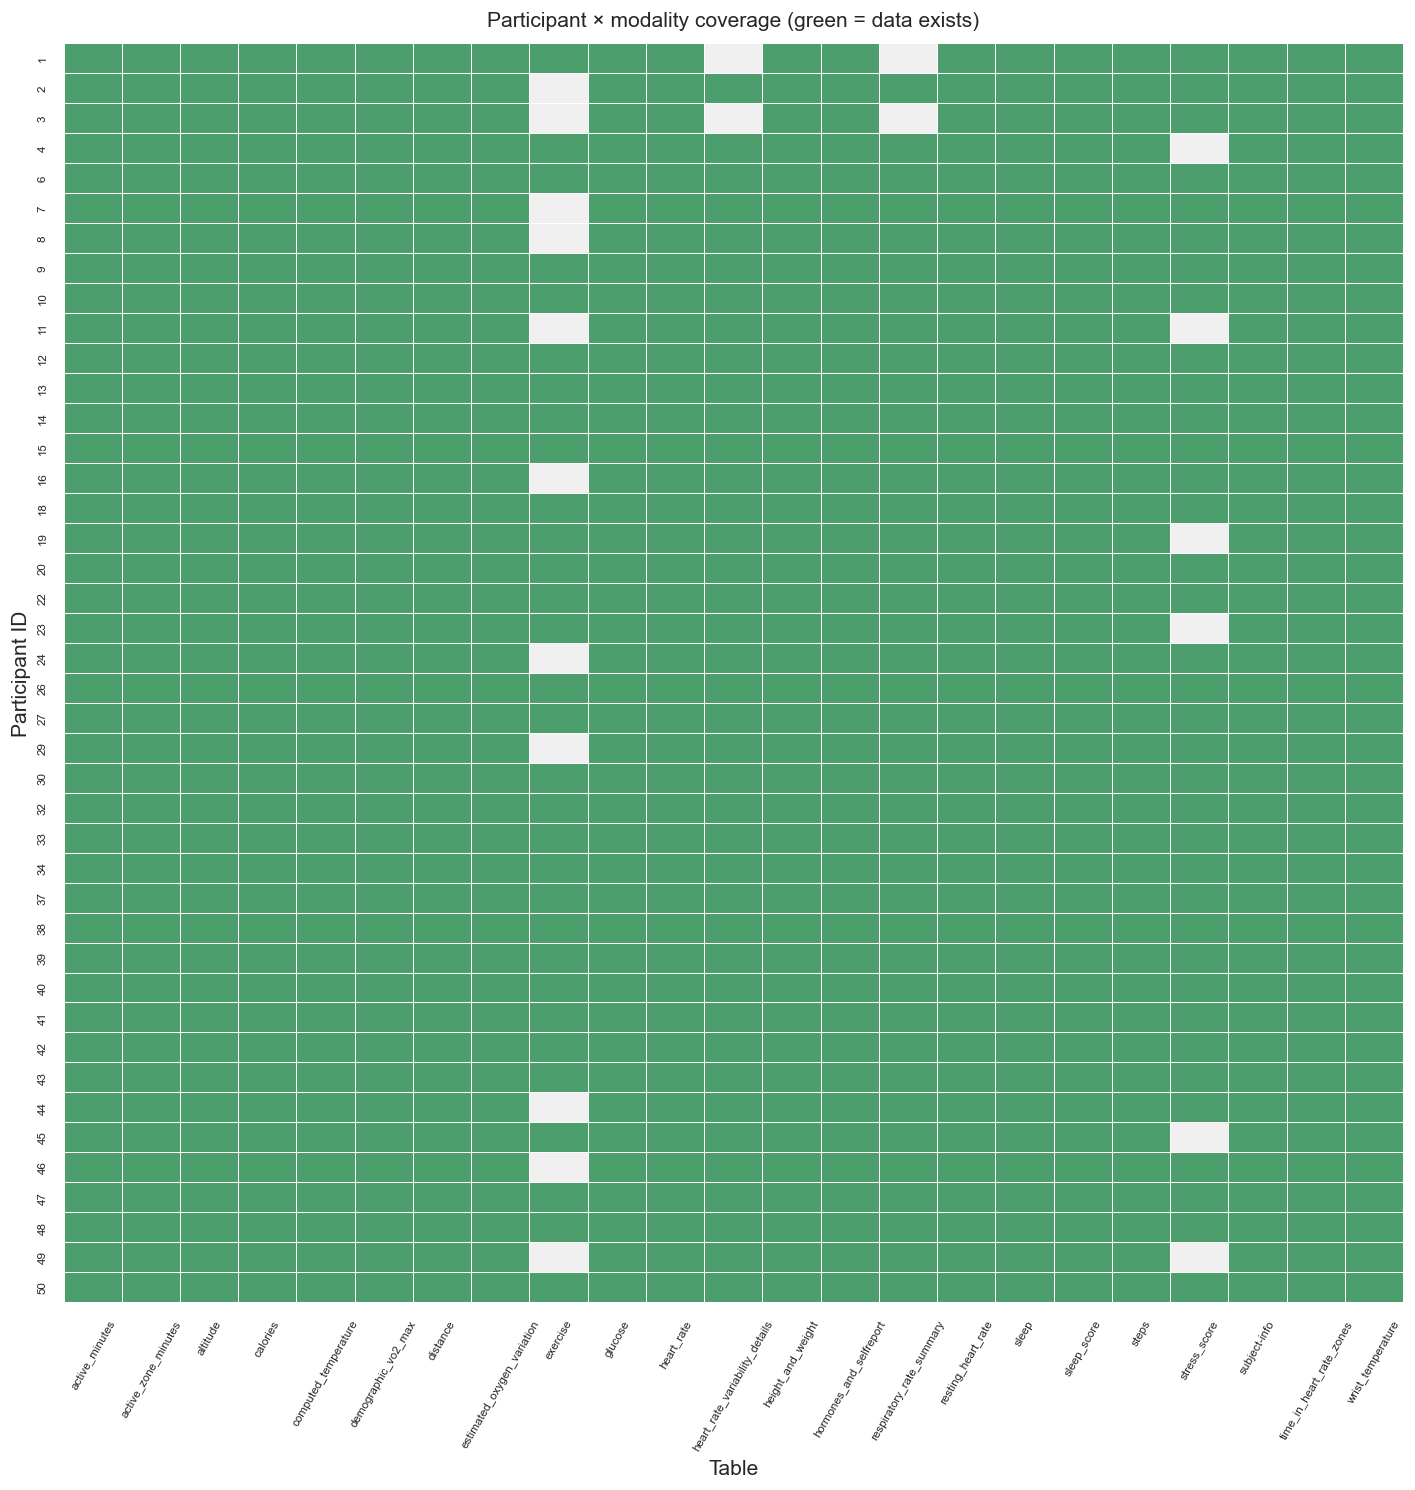


Participants with ALL key modalities: 40
Key modalities checked: ['hormones_and_selfreport', 'resting_heart_rate', 'heart_rate_variability_details', 'computed_temperature', 'sleep_score', 'active_minutes']


In [8]:
# ============================================================
# Cell 1.4 — Participant Coverage Across Modalities
# ============================================================
# Why: 检查每个modality有哪些参与者，
# 找到多个modality的overlap，作为建模用户集。

coverage = {}
for name, df in dfs.items():
    if 'id' in df.columns:
        coverage[name] = set(df['id'].dropna().unique())

# All unique participants across all tables
all_participants = set.union(*coverage.values()) if coverage else set()
print(f'Total unique participants across all tables: {len(all_participants)}')

# Build binary coverage matrix: rows=participants, cols=tables
sorted_participants = sorted(all_participants)
sorted_tables = sorted(coverage.keys())

cov_matrix = pd.DataFrame(
    index=sorted_participants,
    columns=sorted_tables,
    data=0
)
for tname, ids in coverage.items():
    for pid in ids:
        cov_matrix.loc[pid, tname] = 1

fig, ax = plt.subplots(figsize=(max(12, len(sorted_tables)*0.5),
                                max(6, len(sorted_participants)*0.3)))
sns.heatmap(
    cov_matrix.astype(int),
    ax=ax,
    cmap=['#f0f0f0', '#4c9e6d'],
    linewidths=0.3,
    cbar=False,
    linecolor='white'
)
ax.set_title('Participant × modality coverage (green = data exists)', pad=10)
ax.set_xlabel('Table')
ax.set_ylabel('Participant ID')
ax.tick_params(axis='x', rotation=60, labelsize=7)
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()

# Participants who have the KEY modalities (for modeling)
KEY_MODALITIES = [
    'hormones_and_selfreport',
    'resting_heart_rate',
    'heart_rate_variability_details',
    'computed_temperature',
    'sleep_score',
    'active_minutes',
]
available_key = [m for m in KEY_MODALITIES if m in coverage]
common_participants = set.intersection(*[coverage[m] for m in available_key])

print(f'\nParticipants with ALL key modalities: {len(common_participants)}')
print(f'Key modalities checked: {available_key}')

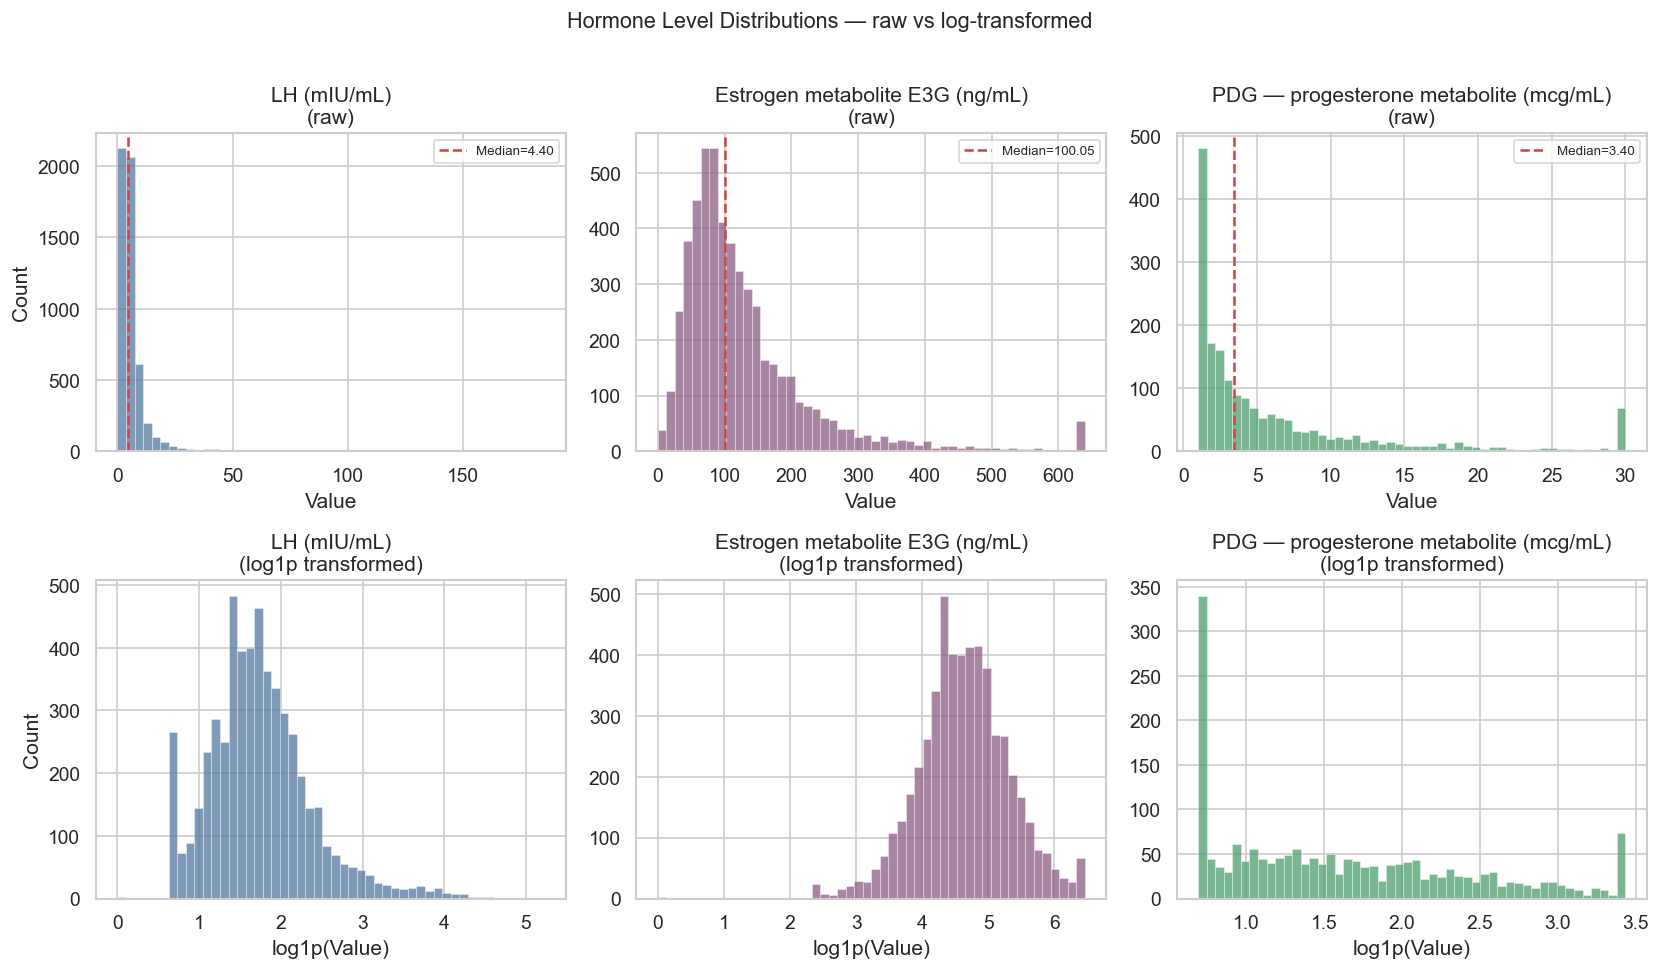


Hormone summary statistics:


,lh,estrogen,pdg
count,5339.000,5338.000,1864.000
mean,6.333,128.988,6.230
std,7.888,101.859,7.113
min,0.000,0.000,1.000
25%,2.800,67.100,1.500
50%,4.400,100.050,3.400
75%,6.900,155.400,7.700
max,185.600,640.000,30.000


In [9]:
# ============================================================
# Cell 1.5 — Hormone Distributions (LH, Estrogen, PDG)
# ============================================================
# Why: LH是排卵峰值的核心marker，estrogen/PDG反映周期阶段。
# 需要理解分布形状决定是否需要log-transform。

if 'hormones_and_selfreport' in dfs:
    hr = dfs['hormones_and_selfreport'].copy()

    HORMONES = {
        'lh':       ('LH (mIU/mL)', '#5478A0'),
        'estrogen': ('Estrogen metabolite E3G (ng/mL)', '#8B5E84'),
        'pdg':      ('PDG — progesterone metabolite (mcg/mL)', '#4c9e6d'),
    }

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))

    for col_i, (col, (label, color)) in enumerate(HORMONES.items()):
        raw  = hr[col].dropna()
        logv = np.log1p(raw)

        # Raw distribution
        ax = axes[0, col_i]
        ax.hist(raw, bins=50, color=color, alpha=0.75, edgecolor='white', linewidth=0.3)
        ax.set_title(f'{label}\n(raw)')
        ax.set_xlabel('Value')
        ax.set_ylabel('Count' if col_i == 0 else '')
        ax.axvline(raw.median(), color='#cc4444', ls='--', lw=1.5, label=f'Median={raw.median():.2f}')
        ax.legend(fontsize=8)

        # Log-transformed
        ax2 = axes[1, col_i]
        ax2.hist(logv, bins=50, color=color, alpha=0.75, edgecolor='white', linewidth=0.3)
        ax2.set_title(f'{label}\n(log1p transformed)')
        ax2.set_xlabel('log1p(Value)')
        ax2.set_ylabel('Count' if col_i == 0 else '')

    plt.suptitle('Hormone Level Distributions — raw vs log-transformed', y=1.01, fontsize=13)
    plt.tight_layout()
    plt.show()

    # Summary stats
    print('\nHormone summary statistics:')
    display(hr[['lh','estrogen','pdg']].describe().round(3))

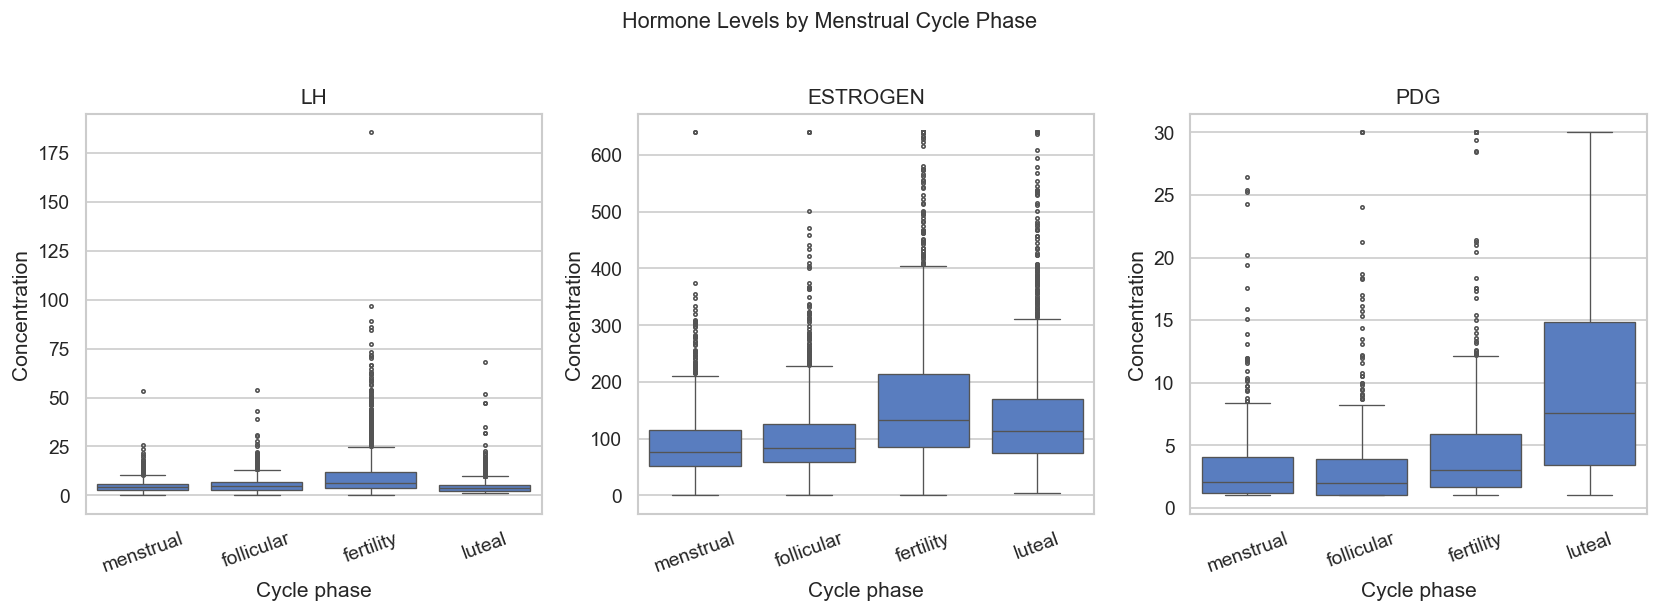

In [10]:
# ============================================================
# Cell 1.5b — Hormone Trajectories by Cycle Phase
# ============================================================
# Why: 确认LH在ovulation phase有明显spike，
# estrogen在follicular升高，PDG在luteal升高。
# 这验证了labels的质量。

hr = dfs['hormones_and_selfreport'].copy()

# clean phase names
hr['phase_clean'] = hr['phase'].astype(str).str.strip().str.lower()

# rename fertility as ovulation-like fertile window, if you want
phase_order = ['menstrual', 'follicular', 'fertility', 'luteal']

hr_phased = hr[hr['phase_clean'].isin(phase_order)].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, hormone in zip(axes, ['lh', 'estrogen', 'pdg']):
    sns.boxplot(
        data=hr_phased,
        x='phase_clean',
        y=hormone,
        order=phase_order,
        ax=ax,
        fliersize=2,
        linewidth=0.8
    )
    ax.set_title(hormone.upper())
    ax.set_xlabel('Cycle phase')
    ax.set_ylabel('Concentration')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Hormone Levels by Menstrual Cycle Phase', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

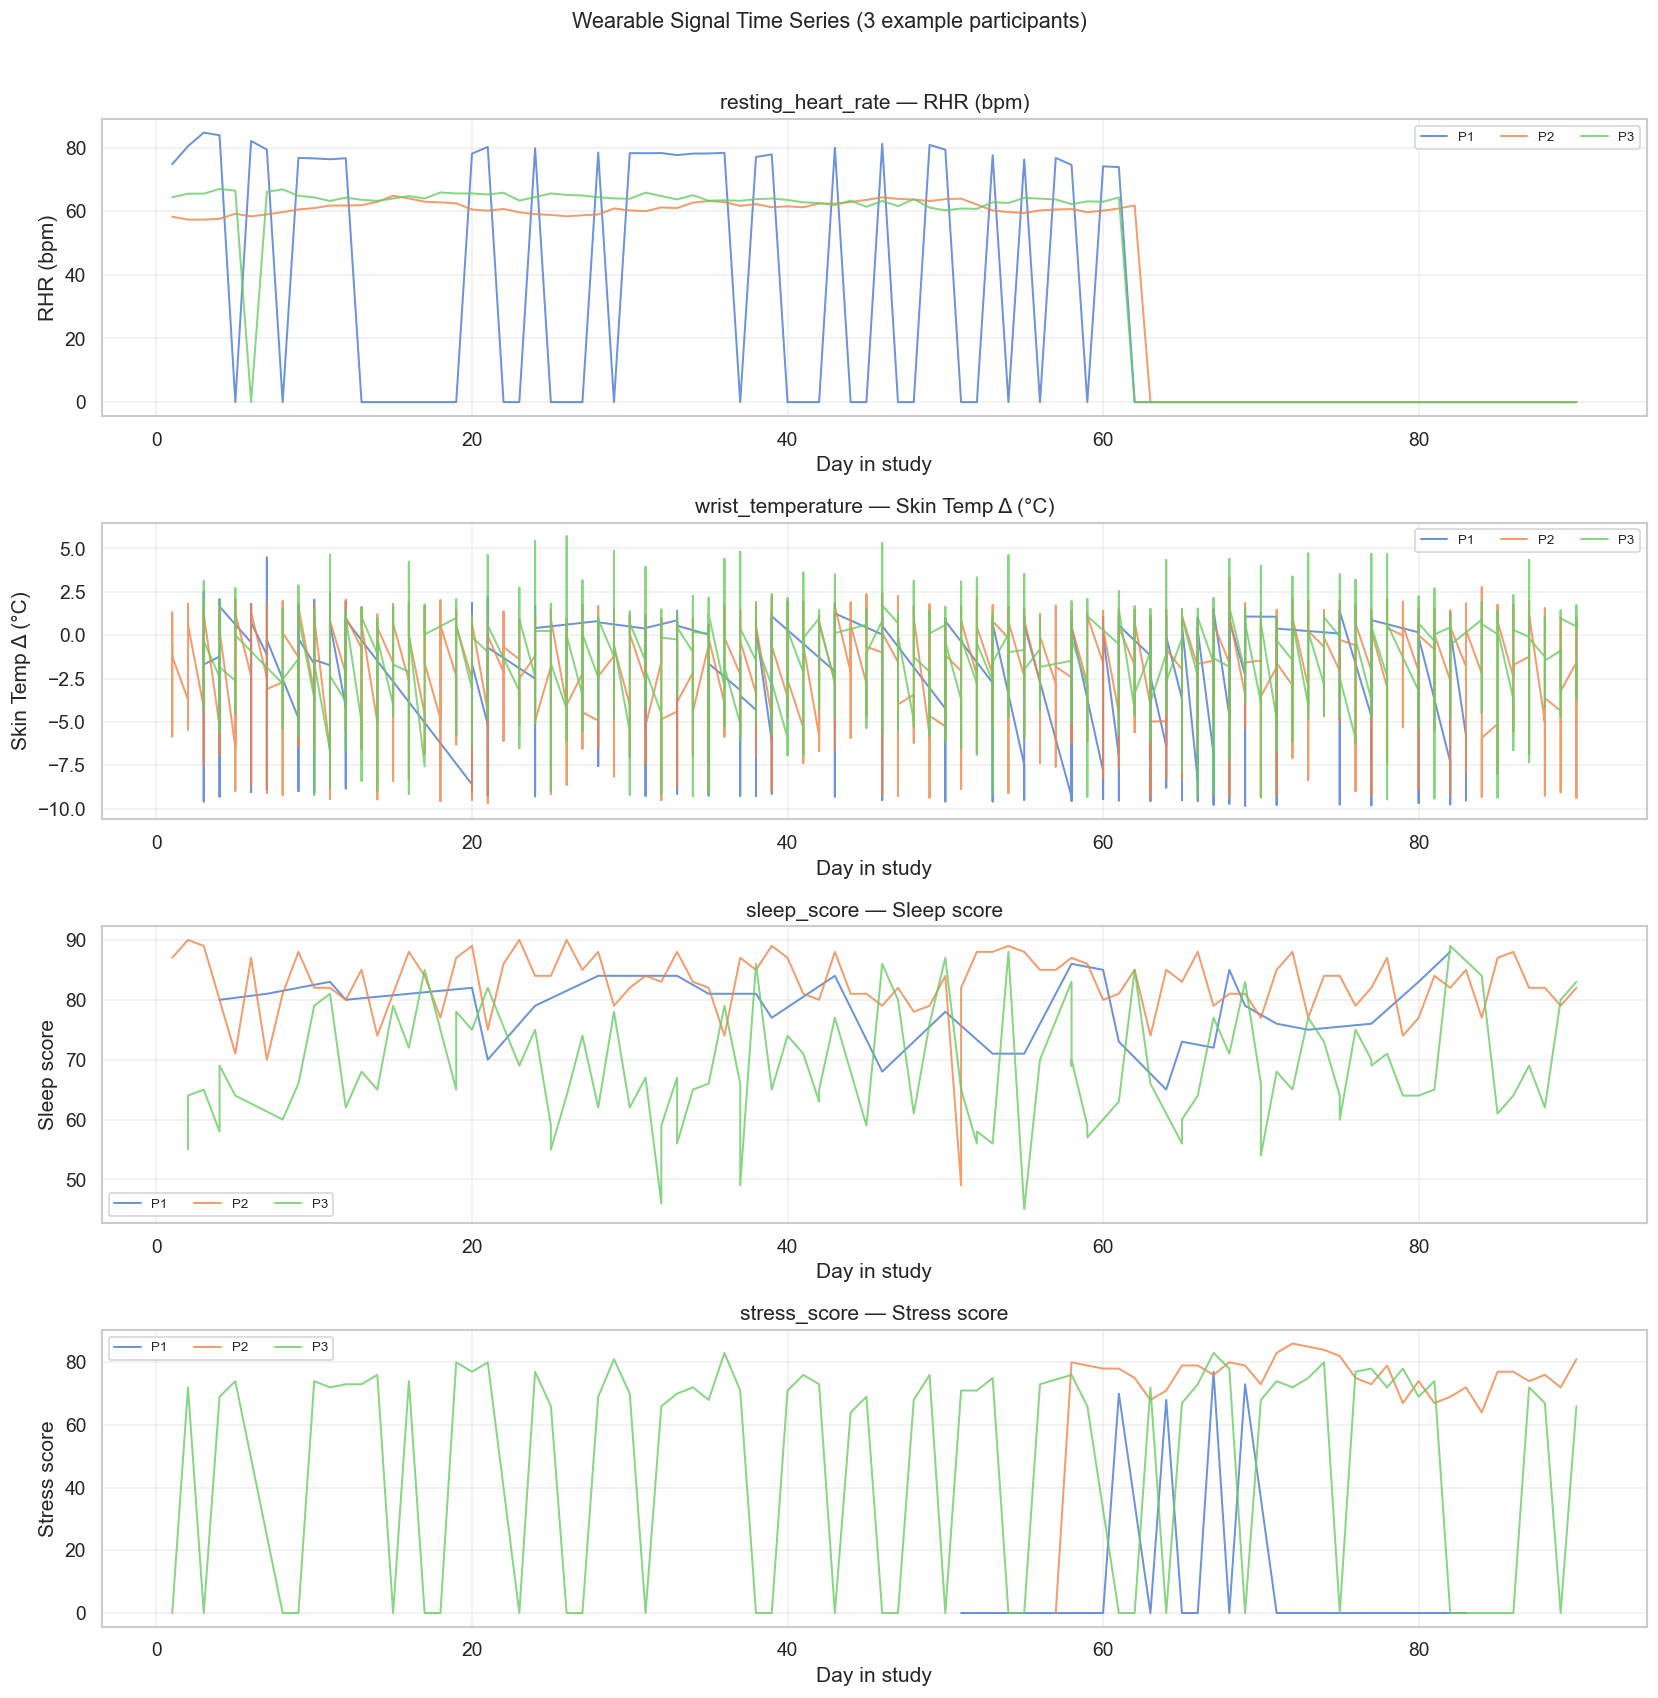

In [11]:
# ============================================================
# Cell 1.6 — Wearable Signal Time Series (example participants)
# ============================================================
# Why: 可视化一个或多个参与者的连续信号，
# 检查noise level、outliers、sensor dropout。
# 使用resting_heart_rate（daily resolution，好可视化）。

PLOT_SIGNALS = {
    'resting_heart_rate':    ('value',                    'RHR (bpm)',      '#5478A0'),
    'wrist_temperature':     ('temperature_diff_from_baseline', 'Skin Temp Δ (°C)', '#C05050'),
    'sleep_score':           ('overall_score',            'Sleep score',    '#4c9e6d'),
    'stress_score':          ('stress_score',             'Stress score',   '#8B5E84'),
}

# Pick first 3 participants that appear in resting_heart_rate
if 'resting_heart_rate' in dfs and 'id' in dfs['resting_heart_rate'].columns:
    sample_ids = list(dfs['resting_heart_rate']['id'].dropna().unique())[:3]
else:
    sample_ids = []

if sample_ids:
    fig, axes = plt.subplots(len(PLOT_SIGNALS), 1,
                             figsize=(14, 3.5 * len(PLOT_SIGNALS)),
                             sharex=False)
    if len(PLOT_SIGNALS) == 1:
        axes = [axes]

    for ax, (tname, (col, ylabel, color)) in zip(axes, PLOT_SIGNALS.items()):
        if tname not in dfs:
            ax.set_visible(False)
            continue
        df = dfs[tname]
        if col not in df.columns:
            ax.text(0.5, 0.5, f'Column `{col}` not found', transform=ax.transAxes,
                    ha='center', va='center', color='gray')
            continue

        # Day axis: prefer day_in_study, else use row index
        day_col = 'day_in_study' if 'day_in_study' in df.columns else None

        for pid in sample_ids:
            sub = df[df['id'] == pid].copy() if 'id' in df.columns else df.copy()
            if day_col:
                sub = sub.sort_values(day_col)
                x = sub[day_col]
            else:
                x = range(len(sub))
            y = sub[col]
            ax.plot(x, y, lw=1.2, alpha=0.8, label=f'P{pid}')

        ax.set_ylabel(ylabel)
        ax.set_xlabel('Day in study')
        ax.set_title(f'{tname} — {ylabel}')
        ax.legend(fontsize=8, ncol=len(sample_ids))
        ax.grid(True, alpha=0.3)

    plt.suptitle('Wearable Signal Time Series (3 example participants)', y=1.01, fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('No participant IDs found — check data path.')

In [12]:
# ============================================================
# Cell 1.6b — Outlier Detection (IQR-based per signal)
# ============================================================
# Why: 发现极端值 (sensor errors, erroneous entries)，
# 这些在preprocessing需要clip或remove。

DAILY_SIGNALS = {
    'resting_heart_rate':   'value',
    'sleep_score':          'overall_score',
    'stress_score':         'stress_score',
    'wrist_temperature':    'temperature_diff_from_baseline',
    'demographic_vo2_max':  'demographic_vo2_max',
}

outlier_report = []
for tname, col in DAILY_SIGNALS.items():
    if tname not in dfs or col not in dfs[tname].columns:
        continue
    vals = dfs[tname][col].dropna()
    q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 3*iqr, q3 + 3*iqr
    n_out = ((vals < lo) | (vals > hi)).sum()
    outlier_report.append({
        'table':    tname,
        'column':   col,
        'n_total':  len(vals),
        'n_outlier':n_out,
        'pct':      100*n_out/len(vals),
        'min':      vals.min().round(3),
        'max':      vals.max().round(3),
        'IQR_lo':   lo.round(3),
        'IQR_hi':   hi.round(3),
    })

out_df = pd.DataFrame(outlier_report)
display(
    out_df.style
    .background_gradient(subset=['pct'], cmap='YlOrRd')
    .format({'pct': '{:.1f}%', 'n_total': '{:,}', 'n_outlier': '{:,}'})
    .set_caption('Outlier rate (3×IQR rule) per signal')
)

,table,column,n_total,n_outlier,pct,min,max,IQR_lo,IQR_hi
0,resting_heart_rate,value,"13,737","1,380",10.0%,0.000000,89.346000,34.451000,103.795000
1,sleep_score,overall_score,"5,308",5,0.1%,30.000000,94.000000,39.000000,116.000000
2,stress_score,stress_score,"7,932","1,011",12.7%,0.000000,94.000000,33.000000,117.000000
3,wrist_temperature,temperature_diff_from_baseline,"6,856,019",0,0.0%,-10.600000,6.474000,-12.430000,9.246000
4,demographic_vo2_max,demographic_vo2_max,"11,482",0,0.0%,23.478000,21474.836000,-64285.155000,85794.830000


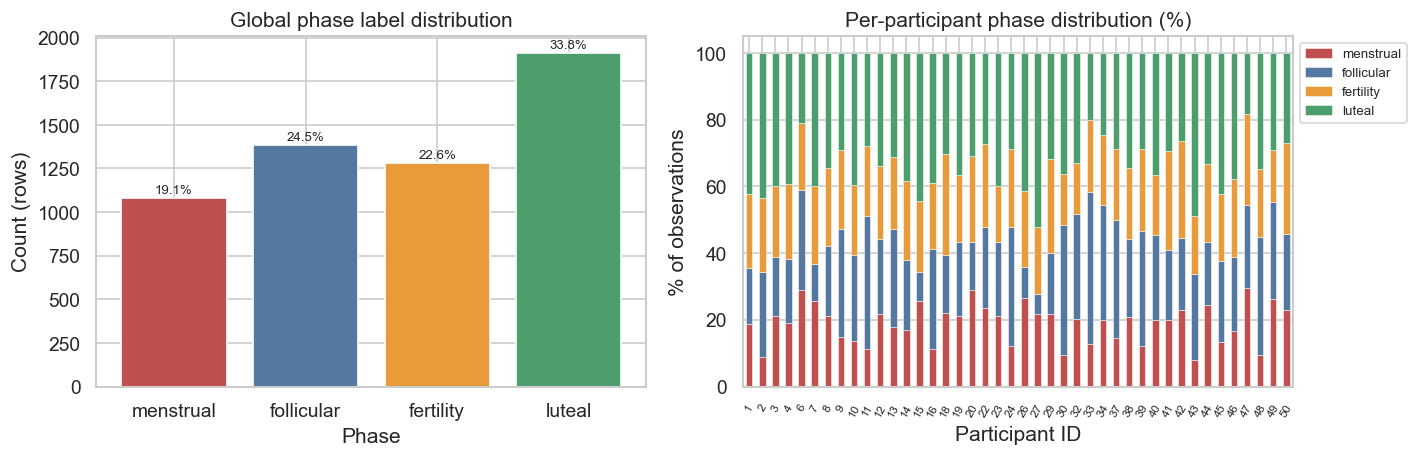


Class imbalance ratio (max/min): 1.77x
→ If imbalance ratio > 3, consider class_weight="balanced" or oversampling.


In [13]:
# ============================================================
# Cell 1.7 — Phase Label Distribution & Class Balance
# ============================================================
# Why: 检查phase label是否class imbalanced，
# 决定是否需要class weighting / oversampling in modeling。

if 'hormones_and_selfreport' in dfs and 'phase' in dfs['hormones_and_selfreport'].columns:
    hr = dfs['hormones_and_selfreport'].copy()

    # Clean phase labels
    hr['phase_clean'] = (
        hr['phase']
        .astype(str)
        .str.strip()
        .str.lower()
    )

    phase_order = ['menstrual', 'follicular', 'fertility', 'luteal']
    PALETTE = {
        'menstrual': '#C05050',
        'follicular': '#5478A0',
        'fertility': '#E89B3A',
        'luteal': '#4c9e6d'
    }

    hr_known = hr[hr['phase_clean'].isin(phase_order)].copy()
    phase_counts = hr_known['phase_clean'].value_counts().reindex(phase_order)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Global distribution
    axes[0].bar(
        phase_counts.index,
        phase_counts.values,
        color=[PALETTE[p] for p in phase_counts.index],
        edgecolor='white'
    )
    axes[0].set_title('Global phase label distribution')
    axes[0].set_xlabel('Phase')
    axes[0].set_ylabel('Count (rows)')

    for i, v in enumerate(phase_counts.values):
        pct = 100 * v / phase_counts.sum()
        axes[0].text(i, v + 10, f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)

    # Per-participant phase coverage
    per_p = (
        hr_known.groupby('id')['phase_clean']
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .reindex(columns=phase_order, fill_value=0)
        * 100
    )

    per_p.plot(
        kind='bar',
        ax=axes[1],
        stacked=True,
        color=[PALETTE[p] for p in phase_order],
        edgecolor='white',
        linewidth=0.3
    )

    axes[1].set_title('Per-participant phase distribution (%)')
    axes[1].set_xlabel('Participant ID')
    axes[1].set_ylabel('% of observations')
    axes[1].legend(phase_order, fontsize=8, bbox_to_anchor=(1, 1))
    axes[1].tick_params(axis='x', rotation=60, labelsize=7)

    plt.tight_layout()
    plt.show()

    imbalance = phase_counts.max() / phase_counts.min()
    print(f'\nClass imbalance ratio (max/min): {imbalance:.2f}x')
    print('→ If imbalance ratio > 3, consider class_weight="balanced" or oversampling.')

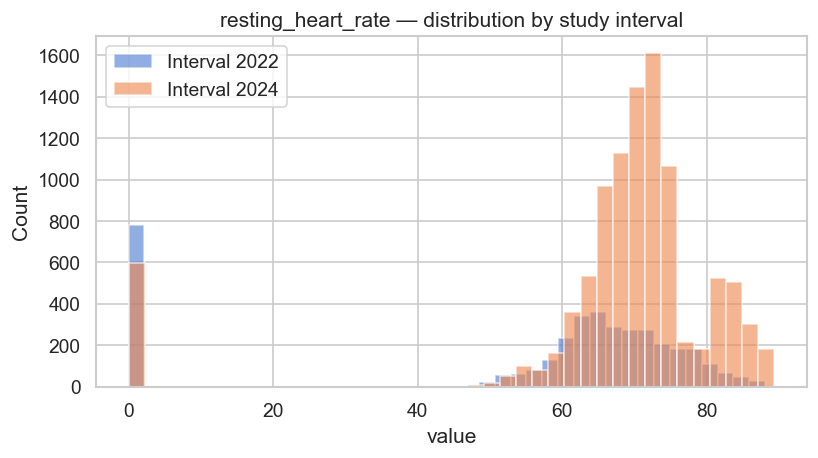


KS test between intervals: statistic=0.3222, p=0.0000
→ Significant distribution shift detected. Consider interval as a covariate.


In [14]:
# ============================================================
# Cell 1.7b — Study Interval Comparison (2022 vs 2024)
# ============================================================
# Why: 数据有两个collection intervals，
# 确认信号分布没有明显drift（否则需要domain adaptation）。

INTERVAL_CHECK_TABLE = 'resting_heart_rate'
INTERVAL_CHECK_COL   = 'value'

if (INTERVAL_CHECK_TABLE in dfs and
    'study_interval' in dfs[INTERVAL_CHECK_TABLE].columns and
    INTERVAL_CHECK_COL in dfs[INTERVAL_CHECK_TABLE].columns):

    df_int = dfs[INTERVAL_CHECK_TABLE].copy()
    fig, ax = plt.subplots(figsize=(7, 4))
    for interval, grp in df_int.groupby('study_interval'):
        grp[INTERVAL_CHECK_COL].dropna().hist(
            bins=40, alpha=0.6, ax=ax, label=f'Interval {interval}'
        )
    ax.set_xlabel(INTERVAL_CHECK_COL)
    ax.set_ylabel('Count')
    ax.set_title(f'{INTERVAL_CHECK_TABLE} — distribution by study interval')
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Kolmogorov-Smirnov test
    from scipy import stats
    intervals = df_int.groupby('study_interval')[INTERVAL_CHECK_COL].apply(lambda x: x.dropna().values)
    keys = list(intervals.index)
    if len(keys) >= 2:
        ks_stat, ks_p = stats.ks_2samp(intervals[keys[0]], intervals[keys[1]])
        print(f'\nKS test between intervals: statistic={ks_stat:.4f}, p={ks_p:.4f}')
        if ks_p < 0.05:
            print('→ Significant distribution shift detected. Consider interval as a covariate.')
        else:
            print('→ No significant distribution shift. Intervals can be pooled.')

Added resting_heart_rate: 5659 daily rows, features = ['rhr']
Added sleep_score: 5078 daily rows, features = ['sleep_overall', 'deep_sleep_min']
Added wrist_temperature: 5138 daily rows, features = ['wrist_temp_diff']
Added stress_score: 4239 daily rows, features = ['stress_score']
Added demographic_vo2_max: 5492 daily rows, features = ['vo2max']
Added active_minutes: 5481 daily rows, features = ['act_sedentary', 'act_very_active']
Added hormones_and_selfreport: 5659 daily rows, features = ['lh', 'estrogen', 'pdg']

Clean merged_daily table created.
Shape: (5659, 13)
Participants: 42
Day range: 1 to 1004
Feature columns: ['rhr', 'sleep_overall', 'deep_sleep_min', 'wrist_temp_diff', 'stress_score', 'vo2max', 'act_sedentary', 'act_very_active', 'lh', 'estrogen', 'pdg']


,id,day_in_study,rhr,sleep_overall,deep_sleep_min,wrist_temp_diff,stress_score,vo2max,act_sedentary,act_very_active,lh,estrogen,pdg
0,1,1,74.785346,NaN,NaN,NaN,NaN,33.79370,753.0,0.0,2.9,94.2,NaN
1,1,2,80.407307,NaN,NaN,NaN,NaN,31.34628,855.0,0.0,1.2,226.3,NaN
2,1,3,84.686869,NaN,NaN,-2.410090,NaN,29.48324,751.0,7.0,3.5,276.8,NaN
3,1,4,83.852219,80.0,93.0,-2.198042,NaN,29.84659,905.0,0.0,1.8,322.1,NaN
4,1,5,NaN,NaN,NaN,NaN,NaN,30.21759,1430.0,0.0,4.6,244.9,NaN



Missing rate by feature (%):
pdg                67.1
act_sedentary      34.7
deep_sleep_min     27.8
stress_score       25.1
rhr                13.9
sleep_overall      10.3
wrist_temp_diff     9.2
estrogen            5.7
lh                  5.7
act_very_active     3.1
vo2max              3.0
dtype: float64


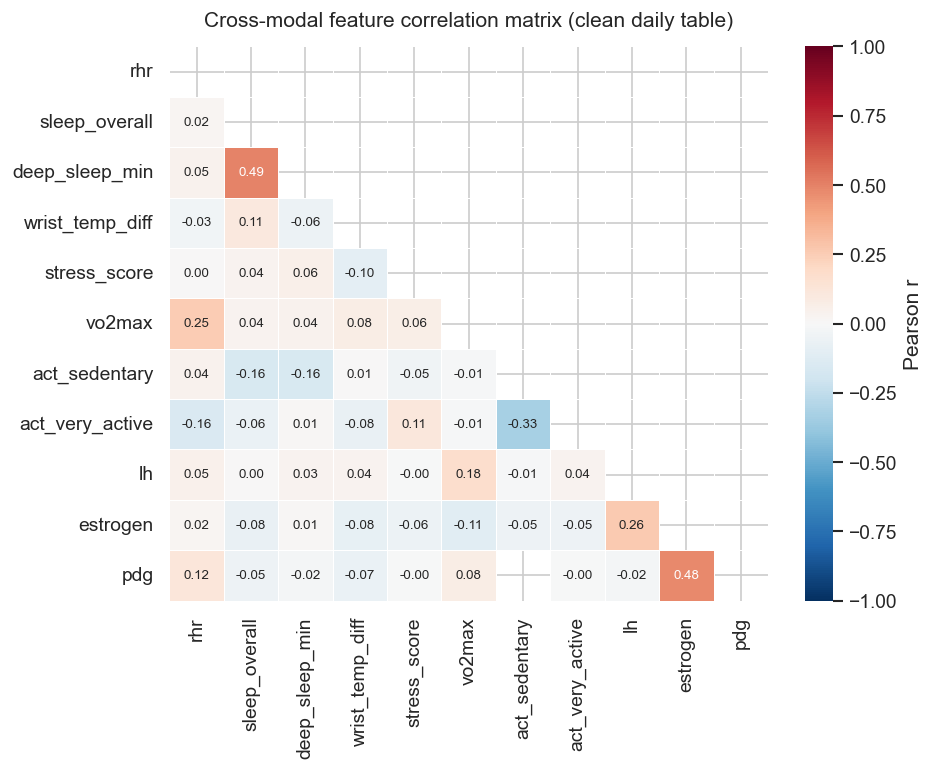

In [15]:
# ============================================================
# Cell 1.8 — Clean Cross-Modal Daily Table + Correlation Matrix
# ============================================================

DAILY_FEATURE_MAP = {
    'resting_heart_rate':   [('value', 'rhr')],
    'sleep_score':          [('overall_score', 'sleep_overall'),
                             ('deep_sleep_in_minutes', 'deep_sleep_min')],
    'wrist_temperature':    [('temperature_diff_from_baseline', 'wrist_temp_diff')],
    'stress_score':         [('stress_score', 'stress_score')],
    'demographic_vo2_max':  [('demographic_vo2_max', 'vo2max')],
    'active_minutes':       [('sedentary', 'act_sedentary'),
                             ('very', 'act_very_active')],
    'hormones_and_selfreport': [
        ('lh', 'lh'),
        ('estrogen', 'estrogen'),
        ('pdg', 'pdg'),
    ],
}

merged_daily = None

for tname, col_pairs in DAILY_FEATURE_MAP.items():
    if tname not in dfs:
        print(f"Skipping {tname}: table not found")
        continue

    df = dfs[tname].copy()

    if 'id' not in df.columns or 'day_in_study' not in df.columns:
        print(f"Skipping {tname}: missing id or day_in_study")
        continue

    valid_cols = [c for c, _ in col_pairs if c in df.columns]

    if not valid_cols:
        print(f"Skipping {tname}: no valid feature columns")
        continue

    # Clean key columns
    df['id'] = pd.to_numeric(df['id'], errors='coerce')
    df['day_in_study'] = pd.to_numeric(df['day_in_study'], errors='coerce')
    df = df.dropna(subset=['id', 'day_in_study'])

    # Convert feature columns to numeric
    for c in valid_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    # Treat impossible RHR=0 as missing
    if tname == 'resting_heart_rate' and 'value' in valid_cols:
        df.loc[df['value'] <= 0, 'value'] = np.nan

    # Optional: treat impossible sleep/stress values as missing
    if tname == 'sleep_score':
        for c in valid_cols:
            df.loc[(df[c] < 0) | (df[c] > 100), c] = np.nan

    if tname == 'stress_score' and 'stress_score' in valid_cols:
        df.loc[(df['stress_score'] < 0) | (df['stress_score'] > 100), 'stress_score'] = np.nan

    # Daily aggregation
    daily = (
        df.groupby(['id', 'day_in_study'], as_index=False)[valid_cols]
        .mean(numeric_only=True)
    )

    rename_dict = {c: new for c, new in col_pairs if c in daily.columns}
    daily = daily.rename(columns=rename_dict)

    keep_cols = ['id', 'day_in_study'] + list(rename_dict.values())
    daily = daily[keep_cols]

    print(f"Added {tname}: {daily.shape[0]} daily rows, features = {list(rename_dict.values())}")

    if merged_daily is None:
        merged_daily = daily
    else:
        merged_daily = merged_daily.merge(
            daily,
            on=['id', 'day_in_study'],
            how='outer'
        )

# Final clean table
if merged_daily is not None:
    merged_daily = merged_daily.sort_values(['id', 'day_in_study']).reset_index(drop=True)

    # Keep only numeric feature columns
    feature_cols = [c for c in merged_daily.columns if c not in ['id', 'day_in_study']]
    merged_daily[feature_cols] = merged_daily[feature_cols].apply(
        pd.to_numeric,
        errors='coerce'
    )

    print("\nClean merged_daily table created.")
    print("Shape:", merged_daily.shape)
    print("Participants:", merged_daily['id'].nunique())
    print("Day range:", merged_daily['day_in_study'].min(), "to", merged_daily['day_in_study'].max())
    print("Feature columns:", feature_cols)

    display(merged_daily.head())

    # Missing rate summary
    missing_summary = (
        merged_daily[feature_cols]
        .isna()
        .mean()
        .sort_values(ascending=False)
        .mul(100)
        .round(1)
    )

    print("\nMissing rate by feature (%):")
    print(missing_summary)

    # Correlation matrix
    corr_cols = [c for c in feature_cols if merged_daily[c].notna().sum() >= 30]

    corr = merged_daily[corr_cols].corr()

    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(
        figsize=(max(8, len(corr_cols) * 0.7),
                 max(6, len(corr_cols) * 0.6))
    )

    sns.heatmap(
        corr,
        mask=mask,
        ax=ax,
        cmap='RdBu_r',
        center=0,
        vmin=-1,
        vmax=1,
        annot=True,
        fmt='.2f',
        annot_kws={'size': 8},
        linewidths=0.4,
        cbar_kws={'label': 'Pearson r'}
    )

    ax.set_title('Cross-modal feature correlation matrix (clean daily table)', pad=12)
    plt.tight_layout()
    plt.show()

else:
    print("Could not build merged_daily table.")

In [16]:
# ============================================================
# Cell 1.9 — EDA Summary & Decision Log
# ============================================================
# 在这里记录所有EDA observations和preprocessing decisions。
# 这会直接指导Part 2的preprocessing步骤。

print('=' * 60)
print('EDA SUMMARY & PREPROCESSING DECISIONS')
print('=' * 60)
print()
print('1. DATA LOADING')
print(f'   - Files loaded: {len(dfs)}/{len(CSV_FILES)}')
if missing_files:
    print(f'   - Missing files: {missing_files}')
print()
print('2. MISSING VALUES')
print('   - See heatmap above for column-level breakdown')
print('   - Decision: forward-fill within participant, then median imputation')
print('   - Participants with >50% hormone missing → exclude from modeling')
print()
print('3. PARTICIPANT COVERAGE')
print(f'   - Participants with all key modalities: {len(common_participants) if "common_participants" in dir() else "?"}')
print('   - These form our modeling cohort')
print()
print('4. HORMONE DISTRIBUTIONS')
print('   - LH is right-skewed → apply log1p transform')
print('   - Estrogen and PDG similarly skewed → log1p')
print()
print('5. CLASS BALANCE')
print('   - Ovulation phase has fewest observations')
print('   - Decision: use class_weight="balanced" in baseline models')
print('   - Report macro-F1 as primary metric for phase classification')
print()
print('6. STUDY INTERVAL')
print('   - Check KS test above: pooling OK if p>0.05, else add as covariate')
print()
print('7. NEXT STEPS → Part 2: Preprocessing & Sliding Window Construction')

EDA SUMMARY & PREPROCESSING DECISIONS

1. DATA LOADING
   - Files loaded: 23/23

2. MISSING VALUES
   - See heatmap above for column-level breakdown
   - Decision: forward-fill within participant, then median imputation
   - Participants with >50% hormone missing → exclude from modeling

3. PARTICIPANT COVERAGE
   - Participants with all key modalities: 40
   - These form our modeling cohort

4. HORMONE DISTRIBUTIONS
   - LH is right-skewed → apply log1p transform
   - Estrogen and PDG similarly skewed → log1p

5. CLASS BALANCE
   - Ovulation phase has fewest observations
   - Decision: use class_weight="balanced" in baseline models
   - Report macro-F1 as primary metric for phase classification

6. STUDY INTERVAL
   - Check KS test above: pooling OK if p>0.05, else add as covariate

7. NEXT STEPS → Part 2: Preprocessing & Sliding Window Construction


In [38]:
df['phase'] = (
    df['phase']
    .str.lower()
    .str.strip()
    .replace({'ovulation': 'fertility'})
)

## Part 2: Preprocessing & Feature Engineering

Sections:
- 2.1 Merge tables on id + day
- 2.2 Imputation strategy
- 2.3 Normalization
- 2.4 Sliding window (7-day)
- 2.5 User-level split

In [39]:
# ================================================================
# Cell 2.1 — Merge all modalities into one daily feature table
#
# 实际数据情况 (已确认):
#   - self-report列全是字符串: 'Low', 'High', 'Very Low/Little'
#   - phase 是首字母大写: 'Follicular', 'Luteal' 等
#   - lh / estrogen / pdg 是 float64
#   - computed_temperature 用 sleep_start_day_in_study 作为 key
# ================================================================

import os, warnings, json, pickle
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})

DATA_DIR   = "/Users/luozixiao/Desktop/mcphases/mcphases"
OUTPUT_DIR = "/Users/luozixiao/Desktop/mcphases/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

WINDOW_MAIN = 7
WINDOW_OVU  = 5
STEP        = 1
SEED        = 42
np.random.seed(SEED)

# ── Load CSVs ─────────────────────────────────────────────────
CSV_FILES = [
    'active_minutes', 'computed_temperature', 'demographic_vo2_max',
    'heart_rate_variability_details', 'hormones_and_selfreport',
    'respiratory_rate_summary', 'resting_heart_rate', 'sleep_score',
    'stress_score', 'subject_info', 'time_in_heart_rate_zones',
    'wrist_temperature', 'sleep',
]

dfs = {}
for name in CSV_FILES:
    path = os.path.join(DATA_DIR, f'{name}.csv')
    if os.path.exists(path):
        dfs[name] = pd.read_csv(path, low_memory=False)
        print(f'  ✓  {name:<42}  {dfs[name].shape}')
    else:
        print(f'  ✗  {name:<42}  NOT FOUND')

print(f'\nLoaded {len(dfs)}/{len(CSV_FILES)} tables')


# ── Likert string → numeric (0–5) ─────────────────────────────
# 实际数据里 self-report 列存的是文字标签，不是数字
LIKERT_MAP = {
    'not at all':      0,
    'very low/little': 1,
    'very low':        1,
    'low':             2,
    'moderate':        3,
    'high':            4,
    'very high':       5,
    # flow_volume extras
    'light':           1,
    'medium':          2,
    'medium/heavy':    3,
    'heavy':           4,
    'very heavy':      5,
}

def encode_likert(series):
    return (
        series.astype(str)
        .str.lower()
        .str.strip()
        .map(LIKERT_MAP)
        .astype(float)
    )


# ── safe_agg_daily: generic aggregation helper ────────────────
def safe_agg_daily(df, day_col, rename_map, agg_func):
    """
    Aggregate one table to (id, day_in_study) level.
    Filters out any non-numeric columns before aggregation.
    """
    if 'id' not in df.columns:
        print(f'    WARNING: no id column'); return None
    if day_col not in df.columns:
        print(f'    WARNING: day col "{day_col}" not found'); return None

    valid_map = {k: v for k, v in rename_map.items() if k in df.columns}
    missing   = [k for k in rename_map if k not in df.columns]
    if missing:
        print(f'    INFO skipped (not in csv): {missing}')
    if not valid_map:
        print(f'    WARNING: no valid columns'); return None

    src_cols = list(valid_map.keys())
    df_work  = df[['id', day_col] + src_cols].copy()

    # Force numeric — object cols become NaN, then drop if all NaN
    castable = []
    for col in src_cols:
        df_work[col] = pd.to_numeric(df_work[col], errors='coerce')
        if df_work[col].notna().sum() > 0:
            castable.append(col)
        else:
            print(f'    INFO: "{col}" all non-numeric → skipped')

    if not castable:
        print(f'    WARNING: no castable columns'); return None

    valid_map = {k: v for k, v in valid_map.items() if k in castable}

    result = (
        df_work.groupby(['id', day_col])[castable]
        .agg(agg_func)
        .reset_index()
        .rename(columns={**valid_map, day_col: 'day_in_study'})
    )

    final_cols = ['id', 'day_in_study'] + list(valid_map.values())
    return result[[c for c in final_cols if c in result.columns]]


# ── process_hormones_table: special handling ──────────────────
def process_hormones_table(df):
    """
    hormones_and_selfreport needs special handling:
      - lh / estrogen / pdg : already float → mean
      - self-report symptoms : Likert strings → encode → mean
      - flow_volume          : Likert string  → encode → mean
      - flow_color           : categorical    → skip entirely
      - phase                : string         → mode per (id, day)
    """
    if df is None: return None
    if 'id' not in df.columns or 'day_in_study' not in df.columns:
        print('    WARNING: missing id or day_in_study'); return None

    df_work = df.copy()

    # Columns that are already numeric
    pure_numeric = ['lh', 'estrogen', 'pdg']

    # Columns that are Likert strings → need encoding first
    likert_cols = [
        'appetite', 'exerciselevel', 'headaches', 'cramps',
        'sorebreasts', 'fatigue', 'sleepissue', 'moodswing',
        'stress', 'foodcravings', 'indigestion', 'bloating',
        'flow_volume',
    ]
    rename_map = {
        'lh': 'lh', 'estrogen': 'estrogen', 'pdg': 'pdg',
        'appetite': 'sr_appetite', 'exerciselevel': 'sr_exercise',
        'headaches': 'sr_headaches', 'cramps': 'sr_cramps',
        'sorebreasts': 'sr_sorebreasts', 'fatigue': 'sr_fatigue',
        'sleepissue': 'sr_sleepissue', 'moodswing': 'sr_moodswing',
        'stress': 'sr_stress', 'foodcravings': 'sr_foodcravings',
        'indigestion': 'sr_indigestion', 'bloating': 'sr_bloating',
        'flow_volume': 'sr_flow_volume',
    }

    # Encode Likert string columns in-place
    for col in likert_cols:
        if col in df_work.columns:
            df_work[col] = encode_likert(df_work[col])

    # Force pure numeric cols to float
    for col in pure_numeric:
        if col in df_work.columns:
            df_work[col] = pd.to_numeric(df_work[col], errors='coerce')

    # Collect all src cols that exist and are now numeric
    all_src = [c for c in rename_map if c in df_work.columns]

    numeric_daily = (
        df_work.groupby(['id', 'day_in_study'])[all_src]
        .mean()
        .reset_index()
        .rename(columns=rename_map)
    )

    # Phase: mode per (id, day) — keep original string for later encoding
    phase_daily = None
    if 'phase' in df.columns:
        def safe_mode(x):
            clean = x.dropna()
            if clean.empty: return np.nan
            m = clean.mode()
            return m.iloc[0] if len(m) > 0 else np.nan

        phase_daily = (
            df.groupby(['id', 'day_in_study'])['phase']
            .agg(safe_mode)
            .reset_index()
        )

    if phase_daily is not None:
        result = numeric_daily.merge(
            phase_daily, on=['id', 'day_in_study'], how='left'
        )
    else:
        result = numeric_daily

    # Quick validation
    sr_cols = [v for k, v in rename_map.items()
               if k in likert_cols and v in result.columns]
    if sr_cols:
        mn = result[sr_cols].min().min()
        mx = result[sr_cols].max().max()
        print(f'    Likert range after encoding: [{mn:.1f}, {mx:.1f}] (expected 0–5)')

    return result


# ── TABLE_CONFIG ──────────────────────────────────────────────
TABLE_CONFIG = {
    'resting_heart_rate': (
        'day_in_study',
        {'value': 'rhr', 'error': 'rhr_error'},
        'mean'
    ),
    'wrist_temperature': (
        'day_in_study',
        {'temperature_diff_from_baseline': 'wrist_temp_diff'},
        'mean'
    ),
    'sleep_score': (
        'day_in_study',
        {
            'overall_score':         'sleep_overall',
            'composition_score':     'sleep_composition',
            'revitalization_score':  'sleep_revital',
            'duration_score':        'sleep_duration_score',
            'deep_sleep_in_minutes': 'deep_sleep_min',
            'resting_heart_rate':    'sleep_rhr',
            'restlessness':          'sleep_restlessness',
        },
        'mean'
    ),
    'active_minutes': (
        'day_in_study',
        {
            'sedentary':  'act_sedentary',
            'lightly':    'act_lightly',
            'moderately': 'act_moderately',
            'very':       'act_very',
        },
        'sum'   # total minutes per day
    ),
    'stress_score': (
        'day_in_study',
        {
            'stress_score':          'stress',
            'sleep_points':          'stress_sleep_pts',
            'responsiveness_points': 'stress_resp_pts',
            'exertion_points':       'stress_exert_pts',
        },
        'mean'
    ),
    'demographic_vo2_max': (
        'day_in_study',
        {
            'demographic_vo2_max':          'vo2max',
            'filtered_demographic_vo2_max': 'vo2max_filtered',
        },
        'mean'
    ),
    'respiratory_rate_summary': (
        'day_in_study',
        {
            'full_sleep_breathing_rate':     'resp_rate',
            'deep_sleep_breathing_rate':     'resp_rate_deep',
            'rem_sleep_breathing_rate':      'resp_rate_rem',
            'full_sleep_standard_deviation': 'resp_rate_std',
        },
        'mean'
    ),
    'heart_rate_variability_details': (
        'day_in_study',
        {
            'rmssd':          'hrv_rmssd',
            'coverage':       'hrv_coverage',
            'high_frequency': 'hrv_hf',
            'low_frequency':  'hrv_lf',
        },
        'mean'
    ),
    'computed_temperature': (
        'sleep_start_day_in_study',   # sleep-session level key
        {
            'nightly_temperature':                          'skin_temp_nightly',
            'baseline_relative_nightly_standard_deviation': 'skin_temp_std',
            'temperature_samples':                          'skin_temp_samples',
        },
        'mean'
    ),
    'time_in_heart_rate_zones': (
        'day_in_study',
        {
            'below_default_zone_1': 'hrz_below',
            'in_default_zone_1':    'hrz_fatburn',
            'in_default_zone_2':    'hrz_cardio',
            'in_default_zone_3':    'hrz_peak',
        },
        'sum'   # total minutes per day
    ),
}


# ── Run merge ─────────────────────────────────────────────────
merged_daily = None

for tname, (day_col, rename_map, agg_func) in TABLE_CONFIG.items():
    if tname not in dfs:
        print(f'  SKIP {tname}'); continue
    print(f'  {tname}...')
    part = safe_agg_daily(dfs[tname], day_col, rename_map, agg_func)
    if part is None:
        print(f'    → skipped'); continue
    merged_daily = part if merged_daily is None else \
        merged_daily.merge(part, on=['id', 'day_in_study'], how='outer')
    print(f'    → {merged_daily.shape}')

# Hormones special
if 'hormones_and_selfreport' in dfs:
    print('  hormones_and_selfreport...')
    hp = process_hormones_table(dfs['hormones_and_selfreport'])
    if hp is not None:
        merged_daily = hp if merged_daily is None else \
            merged_daily.merge(hp, on=['id', 'day_in_study'], how='outer')
        print(f'    → {merged_daily.shape}')

# study_interval + is_weekend
for tname in ['resting_heart_rate', 'hormones_and_selfreport', 'sleep_score']:
    if tname not in dfs: continue
    df_tmp = dfs[tname]
    extra  = [c for c in ['study_interval', 'is_weekend'] if c in df_tmp.columns]
    if not extra or 'day_in_study' not in df_tmp.columns: continue
    extra_daily = df_tmp.groupby(['id','day_in_study'])[extra].first().reset_index()
    merged_daily = merged_daily.merge(extra_daily, on=['id','day_in_study'], how='left')
    print(f'  Added {extra} from {tname}')
    break

# ── Summary ───────────────────────────────────────────────────
print(f'\n{"="*60}')
print(f'merged_daily shape : {merged_daily.shape}')
print(f'participants       : {merged_daily["id"].nunique()}')
print(f'day range          : {merged_daily["day_in_study"].min()} '
      f'– {merged_daily["day_in_study"].max()}')
print(f'\n{"col":<45} {"dtype":<12} {"null%":>6}')
print('-'*65)
for col in merged_daily.columns:
    print(f'{col:<45} {str(merged_daily[col].dtype):<12} '
          f'{100*merged_daily[col].isnull().mean():>5.1f}%')

  ✓  active_minutes                              (5552, 8)
  ✓  computed_temperature                        (5575, 14)
  ✓  demographic_vo2_max                         (11482, 8)
  ✓  heart_rate_variability_details              (436262, 9)
  ✓  hormones_and_selfreport                     (5659, 22)
  ✓  respiratory_rate_summary                    (6301, 17)
  ✓  resting_heart_rate                          (13737, 6)
  ✓  sleep_score                                 (5308, 12)
  ✓  stress_score                                (7932, 14)
  ✗  subject_info                                NOT FOUND
  ✓  time_in_heart_rate_zones                    (5553, 8)
  ✓  wrist_temperature                           (6856019, 6)
  ✓  sleep                                       (14765, 18)

Loaded 12/13 tables
  resting_heart_rate...
    → (5659, 4)
  wrist_temperature...
    → (5659, 5)
  sleep_score...
    → (5659, 12)
  active_minutes...
    → (5659, 16)
  stress_score...
    → (5659, 20)
  demographic

In [40]:
# ================================================================
# Cell 2.2 — Missing value imputation
#
# 四级策略 (per participant, sorted by day):
#   Level 1: forward-fill  limit=3  → 短暂sensor dropout
#   Level 2: backward-fill limit=3  → 开始几天的缺口
#   Level 3: participant median      → 长缺口，用本人基线填
#   Level 4: global median           → 参与者数据太稀疏时的兜底
#
# 不 impute: id, day_in_study, phase, study_interval, is_weekend
# ================================================================

EXCLUDE_FROM_IMPUTE = {
    'id', 'day_in_study', 'phase', 'study_interval',
    'is_weekend', 'phase_label', 'phase_clean', 'split', 'is_ovulation'
}

numeric_cols = [
    c for c in merged_daily.columns
    if c not in EXCLUDE_FROM_IMPUTE
    and pd.api.types.is_numeric_dtype(merged_daily[c])
]

print(f'Columns to impute: {len(numeric_cols)}')
print(f'Total cells missing before: '
      f'{merged_daily[numeric_cols].isnull().sum().sum():,}')

# Sort — critical so ffill/bfill works within participant
merged_daily = merged_daily.sort_values(
    ['id', 'day_in_study']
).reset_index(drop=True)

miss_before = merged_daily[numeric_cols].isnull().mean() * 100


def impute_one_participant(group):
    g = group.copy()
    # Level 1 + 2: temporal fill (max 3-day gap)
    g[numeric_cols] = (
        g[numeric_cols]
        .ffill(limit=3)
        .bfill(limit=3)
    )
    # Level 3: participant median
    for col in numeric_cols:
        if g[col].isnull().any():
            pm = g[col].median()
            if not np.isnan(pm):
                g[col] = g[col].fillna(pm)
    return g


print('Running per-participant imputation...')
merged_daily = (
    merged_daily
    .groupby('id', group_keys=False)
    .apply(impute_one_participant)
)

# Level 4: global median fallback
n_global = 0
for col in numeric_cols:
    if merged_daily[col].isnull().any():
        gm = merged_daily[col].median()
        merged_daily[col] = merged_daily[col].fillna(gm)
        n_global += 1

print(f'Global median fallback applied to {n_global} columns')

# ── Verify zero nulls remain ───────────────────────────────────
remaining = merged_daily[numeric_cols].isnull().sum().sum()
assert remaining == 0, f'Still {remaining} nulls after imputation!'
print('✓ Zero nulls remaining in numeric columns')

# ── Before vs after comparison ────────────────────────────────
miss_after = merged_daily[numeric_cols].isnull().mean() * 100
compare = pd.DataFrame({
    'before_%': miss_before,
    'after_%':  miss_after,
}).sort_values('before_%', ascending=False)

had_missing = compare[compare['before_%'] > 0]
print(f'\nColumns that had missing data: {len(had_missing)}')
if len(had_missing) > 0:
    display(
        had_missing.style
        .background_gradient(subset=['before_%'], cmap='YlOrRd')
        .background_gradient(subset=['after_%'],  cmap='Greens_r')
        .format('{:.1f}%')
        .set_caption('Imputation result')
    )

Columns to impute: 51
Total cells missing before: 61,678
Running per-participant imputation...
Global median fallback applied to 13 columns
✓ Zero nulls remaining in numeric columns

Columns that had missing data: 51


,before_%,after_%
pdg,67.1%,0.0%
sr_flow_volume,50.2%,0.0%
sr_stress,41.5%,0.0%
sr_moodswing,41.5%,0.0%
sr_headaches,41.5%,0.0%
sr_indigestion,41.4%,0.0%
sr_foodcravings,41.4%,0.0%
sr_sorebreasts,41.4%,0.0%
sr_cramps,41.4%,0.0%
sr_bloating,41.3%,0.0%


In [41]:
# ================================================================
# Cell 2.3 — Feature engineering + Normalization
#
# 先做 feature engineering (在 normalize 之前!),
# 因为 delta / log / ratio 要在原始 scale 上算。
# 然后 StandardScaler fit on train only → transform all splits。
#
# Feature engineering:
#   1. log1p transform: lh, estrogen, pdg (右偏分布)
#   2. day-over-day delta: 捕捉趋势变化
#   3. lh_surge_flag: LH > 1.5× 5-day rolling mean
#   4. lh_pdg_ratio: 排卵前高，排卵后低
#   5. hrv_lf_hf_ratio: 交感/副交感 balance
#   6. rhr_roll5: 5-day rolling mean RHR
# ================================================================

# ── Feature engineering ───────────────────────────────────────
print('Engineering features...')

# 1. Log-transform hormones
for col in ['lh', 'estrogen', 'pdg']:
    if col in merged_daily.columns:
        merged_daily[f'{col}_log'] = np.log1p(
            merged_daily[col].clip(lower=0)
        )
        print(f'  + {col}_log')

# 2. Day-over-day delta (within participant, first day = 0)
DELTA_COLS = [
    'rhr', 'wrist_temp_diff', 'sleep_overall', 'stress',
    'hrv_rmssd', 'lh_log', 'estrogen_log', 'pdg_log',
    'resp_rate', 'deep_sleep_min',
]
for col in DELTA_COLS:
    if col in merged_daily.columns:
        merged_daily[f'{col}_delta'] = (
            merged_daily
            .groupby('id')[col]
            .diff()
            .fillna(0)
        )
        print(f'  + {col}_delta')

# 3. LH surge flag
if 'lh_log' in merged_daily.columns:
    roll_lh = (
        merged_daily
        .groupby('id')['lh_log']
        .transform(lambda x: x.rolling(5, min_periods=1).mean())
    )
    merged_daily['lh_surge_flag'] = (
        merged_daily['lh_log'] > roll_lh * 1.5
    ).astype(float)
    pct = merged_daily['lh_surge_flag'].mean() * 100
    print(f'  + lh_surge_flag  ({pct:.1f}% of days flagged)')

# 4. LH/PDG ratio
if 'lh_log' in merged_daily.columns and 'pdg_log' in merged_daily.columns:
    ratio = merged_daily['lh_log'] / (merged_daily['pdg_log'] + 1e-6)
    p01   = ratio.quantile(0.01)
    p99   = ratio.quantile(0.99)
    merged_daily['lh_pdg_ratio'] = ratio.clip(p01, p99)
    print(f'  + lh_pdg_ratio  (clipped to [{p01:.2f}, {p99:.2f}])')

# 5. HRV LF/HF ratio
if 'hrv_lf' in merged_daily.columns and 'hrv_hf' in merged_daily.columns:
    merged_daily['hrv_lf_hf_ratio'] = (
        merged_daily['hrv_lf'] / (merged_daily['hrv_hf'] + 1e-6)
    ).clip(upper=merged_daily['hrv_lf'].quantile(0.99))
    print(f'  + hrv_lf_hf_ratio')

# 6. 5-day rolling mean RHR
if 'rhr' in merged_daily.columns:
    merged_daily['rhr_roll5'] = (
        merged_daily
        .groupby('id')['rhr']
        .transform(lambda x: x.rolling(5, min_periods=1).mean())
    )
    print(f'  + rhr_roll5')

# ── Define final feature lists ─────────────────────────────────
WEARABLE_FEATURES = [
    'rhr', 'rhr_delta', 'rhr_roll5', 'rhr_error',
    'wrist_temp_diff', 'wrist_temp_diff_delta',
    'skin_temp_nightly', 'skin_temp_std', 'skin_temp_samples',
    'sleep_overall', 'sleep_overall_delta', 'sleep_composition',
    'sleep_revital', 'sleep_duration_score', 'deep_sleep_min',
    'deep_sleep_min_delta', 'sleep_restlessness', 'sleep_rhr',
    'hrv_rmssd', 'hrv_rmssd_delta', 'hrv_hf', 'hrv_lf',
    'hrv_lf_hf_ratio', 'hrv_coverage',
    'resp_rate', 'resp_rate_delta', 'resp_rate_deep',
    'resp_rate_rem', 'resp_rate_std',
    'stress', 'stress_delta',
    'stress_sleep_pts', 'stress_resp_pts', 'stress_exert_pts',
    'vo2max', 'vo2max_filtered',
    'act_sedentary', 'act_lightly', 'act_moderately', 'act_very',
    'hrz_below', 'hrz_fatburn', 'hrz_cardio', 'hrz_peak',
]

HORMONE_FEATURES = [
    'lh', 'lh_log', 'lh_log_delta',
    'estrogen', 'estrogen_log', 'estrogen_log_delta',
    'pdg', 'pdg_log', 'pdg_log_delta',
    'lh_surge_flag', 'lh_pdg_ratio',
]

SELFREPORT_FEATURES = [
    'sr_appetite', 'sr_exercise', 'sr_headaches', 'sr_cramps',
    'sr_sorebreasts', 'sr_fatigue', 'sr_sleepissue', 'sr_moodswing',
    'sr_stress', 'sr_foodcravings', 'sr_indigestion', 'sr_bloating',
    'sr_flow_volume',
]

# Only keep features that actually exist in the dataframe
W_feats  = [f for f in WEARABLE_FEATURES   if f in merged_daily.columns]
H_feats  = [f for f in HORMONE_FEATURES    if f in merged_daily.columns]
SR_feats = [f for f in SELFREPORT_FEATURES if f in merged_daily.columns]
ALL_FEATURES   = W_feats + H_feats + SR_feats
SCALE_FEATURES = ALL_FEATURES

print(f'\nFeature counts:')
print(f'  Wearable:    {len(W_feats)}')
print(f'  Hormone:     {len(H_feats)}')
print(f'  Self-report: {len(SR_feats)}')
print(f'  Total:       {len(ALL_FEATURES)}')

# ── Phase label encoding ───────────────────────────────────────
PHASE_MAP = {
    'menstrual':  0,
    'follicular': 1,
    'fertility':  2,
    'luteal':     3,
}
INV_PHASE_MAP = {v: k for k, v in PHASE_MAP.items()}
N_CLASSES = len(PHASE_MAP)

if 'phase' in merged_daily.columns:
    merged_daily['phase_clean'] = (
        merged_daily['phase']
        .astype(str)
        .str.lower()
        .str.strip()
        .replace('nan', np.nan)
    )
    merged_daily['phase_label']  = merged_daily['phase_clean'].map(PHASE_MAP)
    merged_daily['is_ovulation'] = (
        merged_daily['phase_label'] == 2
    ).astype(float)

    lc = merged_daily['phase_label'].value_counts(dropna=True).sort_index()
    print('\nPhase distribution:')
    for idx, cnt in lc.items():
        pct = 100 * cnt / lc.sum()
        bar = '█' * int(pct / 3)
        print(f'  {int(idx)} {INV_PHASE_MAP[int(idx)]:<12} '
              f'{cnt:>5}  {pct:>5.1f}%  {bar}')

    unmapped = merged_daily[
        merged_daily['phase_clean'].notna() &
        merged_daily['phase_clean'].ne('nan') &
        merged_daily['phase_label'].isna()
    ]['phase_clean'].value_counts()
    if len(unmapped) > 0:
        print(f'\nWARNING unmapped phase strings:')
        print(unmapped)
    else:
        print('\n✓ All phase strings mapped successfully')

# ── User-level split (needed before normalization) ─────────────
# Split first so scaler fits only on train
all_participants = merged_daily['id'].dropna().unique()
np.random.seed(SEED)
np.random.shuffle(all_participants)

n       = len(all_participants)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)

train_ids = set(all_participants[:n_train])
val_ids   = set(all_participants[n_train : n_train + n_val])
test_ids  = set(all_participants[n_train + n_val:])

def assign_split(pid):
    if pid in train_ids: return 'train'
    if pid in val_ids:   return 'val'
    return 'test'

merged_daily['split'] = merged_daily['id'].map(assign_split)

# Verify no leakage
assert (merged_daily.groupby('id')['split'].nunique() == 1).all(), \
    'LEAKAGE: participant in multiple splits!'

print(f'\nParticipant split:')
for spl in ['train', 'val', 'test']:
    g = merged_daily[merged_daily['split'] == spl]
    labeled = g['phase_label'].notna().sum() if 'phase_label' in g else '?'
    print(f'  {spl}: {g["id"].nunique()} participants | '
          f'{len(g):>5} rows | {labeled} labeled')

# ── StandardScaler — fit on train only ────────────────────────
train_mask     = merged_daily['split'] == 'train'
SCALE_FEATURES = [f for f in ALL_FEATURES if f in merged_daily.columns]

scaler = StandardScaler()
scaler.fit(merged_daily.loc[train_mask, SCALE_FEATURES])
merged_daily[SCALE_FEATURES] = scaler.transform(
    merged_daily[SCALE_FEATURES]
)

# Verify
stats = merged_daily.loc[train_mask, SCALE_FEATURES].describe()
print(f'\nPost-scaling train stats:')
print(f'  mean range: [{stats.loc["mean"].min():.4f}, '
      f'{stats.loc["mean"].max():.4f}]  (expect ~0)')
print(f'  std  range: [{stats.loc["std"].min():.4f}, '
      f'{stats.loc["std"].max():.4f}]  (expect ~1)')
print('✓ Normalization complete')

with open(os.path.join(OUTPUT_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
print(f'Scaler saved → {OUTPUT_DIR}/scaler.pkl')

Engineering features...
  + lh_log
  + estrogen_log
  + pdg_log
  + rhr_delta
  + wrist_temp_diff_delta
  + sleep_overall_delta
  + stress_delta
  + hrv_rmssd_delta
  + lh_log_delta
  + estrogen_log_delta
  + pdg_log_delta
  + resp_rate_delta
  + deep_sleep_min_delta
  + lh_surge_flag  (3.7% of days flagged)
  + lh_pdg_ratio  (clipped to [0.35, 3.41])
  + hrv_lf_hf_ratio
  + rhr_roll5

Feature counts:
  Wearable:    44
  Hormone:     11
  Self-report: 13
  Total:       68

Phase distribution:
  0 menstrual     1079   19.1%  ██████
  1 follicular    1386   24.5%  ████████
  2 fertility     1281   22.6%  ███████
  3 luteal        1912   33.8%  ███████████

✓ All phase strings mapped successfully

Participant split:
  train: 29 participants |  3822 rows | 3813 labeled
  val: 6 participants |   814 rows | 810 labeled
  test: 7 participants |  1038 rows | 1035 labeled

Post-scaling train stats:
  mean range: [-0.0000, 0.0000]  (expect ~0)
  std  range: [1.0001, 1.0001]  (expect ~1)
✓ Normal

W=7:   5422 total windows |   5407 labeled (99.7%)
      X shape = (5422, 7, 68)
W=5:   5506 total windows |   5490 labeled (99.7%)
      X shape = (5506, 5, 68)

✓ Window construction complete

Split             W=7 X          W=5 X
----------------------------------------
train     (3639, 7, 68)  (3697, 5, 68)
val        (775, 7, 68)   (786, 5, 68)
test       (993, 7, 68)  (1007, 5, 68)

SSL pretraining set (train, labeled+unlabeled): (3648, 7, 68)


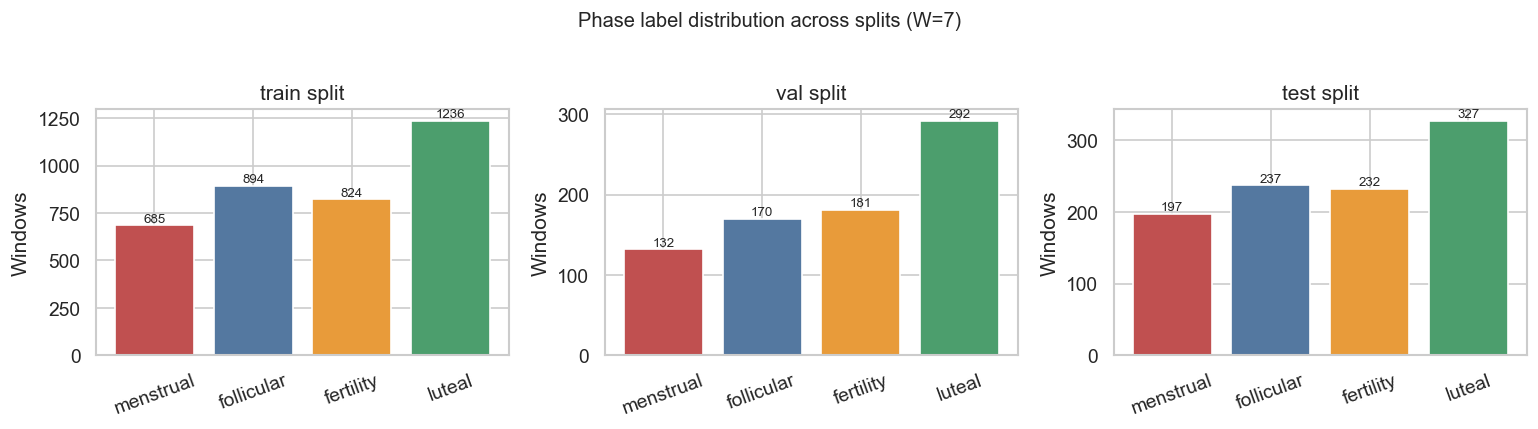

In [42]:
# ================================================================
# Cell 2.4 — Sliding window construction
#
# W=7 (main): phase classification + SSL encoder
# W=5 (ovulation): ovulation detection task
# stride=1: overlapping windows, maximize sample count
#
# Label strategy: label of the LAST day in the window
#   → simulates real-time prediction (observe past W days,
#     predict what phase you are in TODAY)
#
# Each window produces:
#   X      : (W, F) float32 — feature sequence
#   y      : int   — phase label of last day (NaN if unlabeled)
#   y_ovu  : float — is_ovulation of last day
#   pid    : participant id
#   split  : 'train' / 'val' / 'test'
# ================================================================

def build_windows(df_participant, feature_cols, window_size, step=1):
    """
    Build sliding windows for one participant.
    df_participant must already be sorted by day_in_study.
    """
    df_p = df_participant.sort_values('day_in_study').reset_index(drop=True)

    # Ensure all feature columns exist (fill missing with 0 as last resort)
    for col in feature_cols:
        if col not in df_p.columns:
            df_p[col] = 0.0

    X_arr    = df_p[feature_cols].values.astype(np.float32)  # (T, F)
    days_arr = df_p['day_in_study'].values
    split_arr= df_p['split'].values

    y_arr = (df_p['phase_label'].values
             if 'phase_label' in df_p.columns
             else np.full(len(df_p), np.nan))
    yovu_arr = (df_p['is_ovulation'].values
                if 'is_ovulation' in df_p.columns
                else np.full(len(df_p), np.nan))

    X_list, y_list, yovu_list, pid_list, split_list = [], [], [], [], []

    for start in range(0, len(df_p) - window_size + 1, step):
        end = start + window_size   # exclusive

        X_list.append(X_arr[start:end])           # (W, F)
        y_list.append(y_arr[end - 1])              # last day label
        yovu_list.append(yovu_arr[end - 1])
        split_list.append(split_arr[end - 1])

    return X_list, y_list, yovu_list, split_list


# ── Build windows for W=7 and W=5 ─────────────────────────────
windows = {}

for W in [WINDOW_MAIN, WINDOW_OVU]:   # 7, 5
    all_X, all_y, all_yovu = [], [], []
    all_pid, all_split = [], []

    for pid, grp in merged_daily.groupby('id'):
        if len(grp) < W:
            continue   # not enough days for even one window

        Xl, yl, yovul, sl = build_windows(
            grp, SCALE_FEATURES, W, step=STEP
        )
        n = len(Xl)
        all_X.extend(Xl)
        all_y.extend(yl)
        all_yovu.extend(yovul)
        all_pid.extend([pid] * n)
        all_split.extend(sl)

    windows[W] = {
        'X':     np.array(all_X,     dtype=np.float32),  # (N, W, F)
        'y':     np.array(all_y,     dtype=np.float32),  # (N,)
        'y_ovu': np.array(all_yovu,  dtype=np.float32),  # (N,)
        'pid':   np.array(all_pid),                       # (N,)
        'split': np.array(all_split),                     # (N,)
    }

    total   = windows[W]['X'].shape[0]
    labeled = (~np.isnan(windows[W]['y'])).sum()
    print(f'W={W}: {total:>6} total windows | '
          f'{labeled:>6} labeled ({100*labeled/total:.1f}%)')
    print(f'      X shape = {windows[W]["X"].shape}')

print('\n✓ Window construction complete')


# ── get_split_data helper ─────────────────────────────────────
def get_split_data(W, split_name, labeled_only=True):
    """
    Returns X, y, y_ovu, pid arrays for one split.

    Args:
        W:            window size (7 or 5)
        split_name:   'train', 'val', 'test'
        labeled_only: exclude windows where y is NaN

    Returns:
        X     : (N, W, F)  float32
        y     : (N,)       int
        y_ovu : (N,)       float32
        pid   : (N,)       participant ids
    """
    w    = windows[W]
    mask = (w['split'] == split_name)
    if labeled_only:
        mask = mask & ~np.isnan(w['y'])
    X     = w['X'][mask]
    y     = w['y'][mask].astype(int)
    y_ovu = w['y_ovu'][mask]
    pid   = w['pid'][mask]
    return X, y, y_ovu, pid


# ── Print summary table ────────────────────────────────────────
print(f'\n{"Split":<8} {"W=7 X":>14} {"W=5 X":>14}')
print('-' * 40)
for spl in ['train', 'val', 'test']:
    X7, y7, _, _ = get_split_data(WINDOW_MAIN, spl)
    X5, y5, _, _ = get_split_data(WINDOW_OVU,  spl)
    print(f'{spl:<8} {str(X7.shape):>14} {str(X5.shape):>14}')

# SSL set: all train windows including unlabeled
ssl_mask = windows[WINDOW_MAIN]['split'] == 'train'
X_ssl    = windows[WINDOW_MAIN]['X'][ssl_mask]
print(f'\nSSL pretraining set (train, labeled+unlabeled): {X_ssl.shape}')


# ── Sanity check: class distribution per split ────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
COLORS = ['#C05050', '#5478A0', '#E89B3A', '#4c9e6d']

for ax, spl in zip(axes, ['train', 'val', 'test']):
    _, y, _, _ = get_split_data(WINDOW_MAIN, spl)
    counts = np.bincount(y, minlength=N_CLASSES)
    labels = [INV_PHASE_MAP.get(i, str(i)) for i in range(N_CLASSES)]
    ax.bar(labels, counts, color=COLORS[:N_CLASSES], edgecolor='white')
    ax.set_title(f'{spl} split')
    ax.set_ylabel('Windows')
    ax.tick_params(axis='x', rotation=20)
    for i, c in enumerate(counts):
        ax.text(i, c + 0.5, str(c), ha='center', va='bottom', fontsize=8)

plt.suptitle(f'Phase label distribution across splits (W={WINDOW_MAIN})',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [43]:
# ================================================================
# Cell 2.5 — Save all processed arrays
#
# split 已在 Cell 2.3 完成 (70/15/15 participant-level)
# 这里只负责保存所有 .npy 文件 + metadata
#
# 文件清单:
#   X_{split}_W7.npy       (N, 7, F) — main window features
#   y_{split}_W7.npy       (N,)      — phase labels
#   X_{split}_W5.npy       (N, 5, F) — ovulation window
#   y_ovu_{split}_W5.npy   (N,)      — ovulation binary labels
#   X_ssl_W7.npy           (N, 7, F) — all train (labeled+unlabeled)
#   split_ids.json                   — participant id per split
#   feature_list.json                — feature names + phase map
#   merged_daily.csv                 — full daily table (debugging)
#   scaler.pkl                       — fitted StandardScaler
# ================================================================

print('Saving processed arrays...\n')

# ── W=7 arrays ────────────────────────────────────────────────
for spl in ['train', 'val', 'test']:
    X, y, y_ovu, _ = get_split_data(WINDOW_MAIN, spl, labeled_only=True)
    np.save(os.path.join(OUTPUT_DIR, f'X_{spl}_W7.npy'),   X)
    np.save(os.path.join(OUTPUT_DIR, f'y_{spl}_W7.npy'),   y)
    print(f'  W=7 {spl:<6}: X={X.shape}  y={y.shape}')

# ── W=5 arrays (ovulation) ────────────────────────────────────
for spl in ['train', 'val', 'test']:
    X, _, y_ovu, _ = get_split_data(WINDOW_OVU, spl, labeled_only=True)
    np.save(os.path.join(OUTPUT_DIR, f'X_{spl}_W5.npy'),       X)
    np.save(os.path.join(OUTPUT_DIR, f'y_ovu_{spl}_W5.npy'),   y_ovu)
    print(f'  W=5 {spl:<6}: X={X.shape}  y_ovu={y_ovu.shape}')

# ── SSL set ───────────────────────────────────────────────────
np.save(os.path.join(OUTPUT_DIR, 'X_ssl_W7.npy'), X_ssl)
print(f'\n  SSL train set: {X_ssl.shape}')

# ── Metadata ──────────────────────────────────────────────────
# participant ids per split
pid_info = {
    'train': [str(p) for p in train_ids],
    'val':   [str(p) for p in val_ids],
    'test':  [str(p) for p in test_ids],
}
with open(os.path.join(OUTPUT_DIR, 'split_ids.json'), 'w') as f:
    json.dump(pid_info, f, indent=2)

# feature names + label map
meta = {
    'features':     SCALE_FEATURES,
    'n_features':   len(SCALE_FEATURES),
    'wearable_idx': list(range(len(W_feats))),
    'hormone_idx':  list(range(len(W_feats),
                               len(W_feats) + len(H_feats))),
    'selfreport_idx': list(range(len(W_feats) + len(H_feats),
                                  len(ALL_FEATURES))),
    'phase_map':    PHASE_MAP,
    'window_main':  WINDOW_MAIN,
    'window_ovu':   WINDOW_OVU,
    'stride':       STEP,
    'n_classes':    N_CLASSES,
}
with open(os.path.join(OUTPUT_DIR, 'feature_list.json'), 'w') as f:
    json.dump(meta, f, indent=2)

# full daily table for debugging
merged_daily.to_csv(
    os.path.join(OUTPUT_DIR, 'merged_daily.csv'), index=False
)

# ── File listing ──────────────────────────────────────────────
print(f'\nSaved to {OUTPUT_DIR}/:')
print(f'{"file":<40} {"size":>10}')
print('-' * 52)
for fname in sorted(os.listdir(OUTPUT_DIR)):
    sz = os.path.getsize(os.path.join(OUTPUT_DIR, fname))
    unit = 'KB' if sz < 1_000_000 else 'MB'
    val  = sz / 1024 if sz < 1_000_000 else sz / 1_048_576
    print(f'{fname:<40} {val:>8.1f} {unit}')

# ── Final verification ────────────────────────────────────────
print(f'\n{"="*55}')
print('Part 2 complete. Ready for Part 3 (Baseline Models).')
print(f'  Feature dim F = {len(SCALE_FEATURES)}')
print(f'  Main window   = W={WINDOW_MAIN} days')
X_tr, y_tr, _, _ = get_split_data(WINDOW_MAIN, 'train')
X_va, y_va, _, _ = get_split_data(WINDOW_MAIN, 'val')
X_te, y_te, _, _ = get_split_data(WINDOW_MAIN, 'test')
print(f'  Train: {X_tr.shape}  classes={np.unique(y_tr)}')
print(f'  Val:   {X_va.shape}')
print(f'  Test:  {X_te.shape}')
print(f'\n  To load in Part 3:')
print(f'    X_tr = np.load("{OUTPUT_DIR}/X_train_W7.npy")')
print(f'    y_tr = np.load("{OUTPUT_DIR}/y_train_W7.npy")')

Saving processed arrays...

  W=7 train : X=(3639, 7, 68)  y=(3639,)
  W=7 val   : X=(775, 7, 68)  y=(775,)
  W=7 test  : X=(993, 7, 68)  y=(993,)
  W=5 train : X=(3697, 5, 68)  y_ovu=(3697,)
  W=5 val   : X=(786, 5, 68)  y_ovu=(786,)
  W=5 test  : X=(1007, 5, 68)  y_ovu=(1007,)

  SSL train set: (3648, 7, 68)

Saved to /Users/luozixiao/Desktop/mcphases/processed/:
file                                           size
----------------------------------------------------
X_ssl_W7.npy                                  6.6 MB
X_test_W5.npy                                 1.3 MB
X_test_W7.npy                                 1.8 MB
X_train_W5.npy                                4.8 MB
X_train_W7.npy                                6.6 MB
X_val_W5.npy                                  1.0 MB
X_val_W7.npy                                  1.4 MB
feature_list.json                             2.1 KB
merged_daily.csv                              7.5 MB
scaler.pkl                                    3.1 

## Part 3: Baseline Models (RQ2 reference)

Sections:
- 3.1 Logistic Regression
- 3.2 XGBoost
- 3.3 LSTM
- 3.4 Transformer
- 3.5 Eval: Acc / F1 / AUROC

In [51]:
# ================================================================
# Cell 3.0 — Imports & Setup
# ================================================================
import os, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    RocCurveDisplay
)
from sklearn.preprocessing import label_binarize
import xgboost as xgb

# Deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})

OUTPUT_DIR = "/Users/luozixiao/Desktop/mcphases/processed"
RESULTS_DIR = "/Users/luozixiao/Desktop/mcphases/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Load metadata ─────────────────────────────────────────────
with open(os.path.join(OUTPUT_DIR, "feature_list.json"), 'r') as f:
    meta = json.load(f)

SCALE_FEATURES  = meta['features']
PHASE_MAP       = meta['phase_map']
INV_PHASE_MAP   = {v: k for k, v in PHASE_MAP.items()}
N_CLASSES       = meta['n_classes']        # 4
N_FEATURES      = meta['n_features']
WINDOW_MAIN     = meta['window_main']      # 7
WEARABLE_IDX    = meta['wearable_idx']
HORMONE_IDX     = meta['hormone_idx']
SELFREPORT_IDX  = meta['selfreport_idx']

# ── Load arrays ───────────────────────────────────────────────
# W=7: phase classification (4-class)
X_tr = np.load(os.path.join(OUTPUT_DIR, 'X_train_W7.npy'))
y_tr = np.load(os.path.join(OUTPUT_DIR, 'y_train_W7.npy'))
X_va = np.load(os.path.join(OUTPUT_DIR, 'X_val_W7.npy'))
y_va = np.load(os.path.join(OUTPUT_DIR, 'y_val_W7.npy'))
X_te = np.load(os.path.join(OUTPUT_DIR, 'X_test_W7.npy'))
y_te = np.load(os.path.join(OUTPUT_DIR, 'y_test_W7.npy'))

# W=5: fertility detection (binary)
# renamed from ovulation → fertility throughout Part 3
X_tr_f = np.load(os.path.join(OUTPUT_DIR, 'X_train_W5.npy'))
y_tr_f = np.load(os.path.join(OUTPUT_DIR, 'y_ovu_train_W5.npy'))
X_va_f = np.load(os.path.join(OUTPUT_DIR, 'X_val_W5.npy'))
y_va_f = np.load(os.path.join(OUTPUT_DIR, 'y_ovu_val_W5.npy'))
X_te_f = np.load(os.path.join(OUTPUT_DIR, 'X_test_W5.npy'))
y_te_f = np.load(os.path.join(OUTPUT_DIR, 'y_ovu_test_W5.npy'))

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'N_FEATURES = {N_FEATURES}  |  WINDOW = {WINDOW_MAIN}  |  N_CLASSES = {N_CLASSES}')
print(f'\nPhase classification (W=7):')
print(f'  train: {X_tr.shape}  val: {X_va.shape}  test: {X_te.shape}')
print(f'\nFertility detection (W=5):')
print(f'  train: {X_tr_f.shape}  val: {X_va_f.shape}  test: {X_te_f.shape}')


# ── Shared evaluation function ────────────────────────────────
def evaluate(y_true, y_pred, y_prob, task='phase', label='model'):
    """
    Compute Accuracy, macro-F1, and macro-AUROC.

    Args:
        y_true : (N,) int   ground truth labels
        y_pred : (N,) int   predicted class
        y_prob : (N, C) float  predicted probabilities per class
        task   : 'phase' (4-class) or 'fertility' (binary)
        label  : string identifier for printing

    Returns:
        dict with acc, f1, auroc
    """
    acc = accuracy_score(y_true, y_pred)

    if task == 'phase':
        f1    = f1_score(y_true, y_pred, average='macro', zero_division=0)
        # AUROC: one-vs-rest
        y_bin = label_binarize(y_true, classes=list(range(N_CLASSES)))
        try:
            auroc = roc_auc_score(y_bin, y_prob, average='macro',
                                  multi_class='ovr')
        except ValueError:
            auroc = float('nan')
    else:
        # binary fertility
        f1    = f1_score(y_true, y_pred, average='binary', zero_division=0)
        try:
            auroc = roc_auc_score(y_true, y_prob[:, 1])
        except ValueError:
            auroc = float('nan')

    print(f'  [{label}]  Acc={acc:.4f}  Macro-F1={f1:.4f}  AUROC={auroc:.4f}')
    return {'model': label, 'task': task,
            'acc': acc, 'f1': f1, 'auroc': auroc}


# Store all results here for final comparison in Cell 3.5
ALL_RESULTS = []

print('\n✓ Setup complete')

Device: cpu
N_FEATURES = 68  |  WINDOW = 7  |  N_CLASSES = 4

Phase classification (W=7):
  train: (3639, 7, 68)  val: (775, 7, 68)  test: (993, 7, 68)

Fertility detection (W=5):
  train: (3697, 5, 68)  val: (786, 5, 68)  test: (1007, 5, 68)

✓ Setup complete


Flattened shapes:
  Phase:     train (3639, 476)  val (775, 476)
  Fertility: train (3697, 340)  val (786, 340)

── Task A: Phase classification (4-class) ──
  [LR_phase_val]  Acc=0.6090  Macro-F1=0.6082  AUROC=0.8517
  [LR_phase_test]  Acc=0.4914  Macro-F1=0.4970  AUROC=0.7438


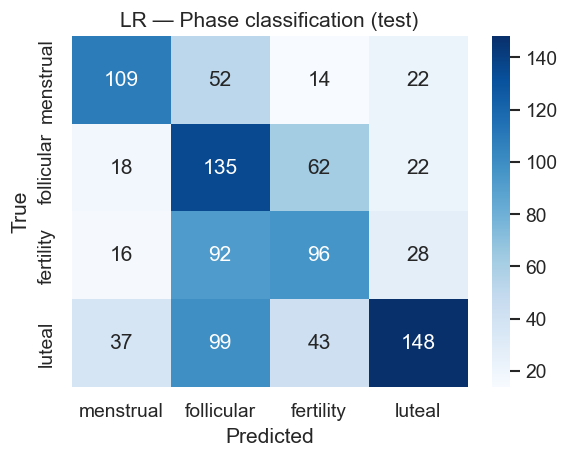


Per-class report:
              precision    recall  f1-score   support

   menstrual       0.61      0.55      0.58       197
  follicular       0.36      0.57      0.44       237
   fertility       0.45      0.41      0.43       232
      luteal       0.67      0.45      0.54       327

    accuracy                           0.49       993
   macro avg       0.52      0.50      0.50       993
weighted avg       0.53      0.49      0.50       993


── Task B: Fertility detection (binary) ──
  [LR_fertility_val]  Acc=0.7176  Macro-F1=0.5698  AUROC=0.8437
  [LR_fertility_test]  Acc=0.7210  Macro-F1=0.4787  AUROC=0.7100

Fertility positive rate in test: 23.5%


In [54]:
# ================================================================
# Cell 3.1 — Logistic Regression baseline
#
# Input: flatten (W, F) → (W*F,) vector
# Why: establishes a strong linear baseline.
#   LR with balanced class weights handles the phase imbalance.
#   L2 regularization (C=1.0) is the default.
#   max_iter=2000 because multi-class with many features
#   needs more iterations to converge.
#
# Two tasks:
#   A. Phase classification (4-class, W=7)
#   B. Fertility detection  (binary,  W=5)
# ================================================================

from sklearn.linear_model import LogisticRegression

# ── Flatten windows: (N, W, F) → (N, W*F) ────────────────────
def flatten(X):
    return X.reshape(X.shape[0], -1)

X_tr_flat  = flatten(X_tr)
X_va_flat  = flatten(X_va)
X_te_flat  = flatten(X_te)

X_tr_f_flat = flatten(X_tr_f)
X_va_f_flat = flatten(X_va_f)
X_te_f_flat = flatten(X_te_f)

print(f'Flattened shapes:')
print(f'  Phase:     train {X_tr_flat.shape}  val {X_va_flat.shape}')
print(f'  Fertility: train {X_tr_f_flat.shape}  val {X_va_f_flat.shape}')


# ── Task A: Phase classification ──────────────────────────────
print('\n── Task A: Phase classification (4-class) ──')

lr_phase = LogisticRegression(
    C=1.0,
    max_iter=2000,
    class_weight='balanced',   # handles imbalance
    solver='lbfgs',
    multi_class='multinomial',
    random_state=SEED,
    n_jobs=1,
)
lr_phase.fit(X_tr_flat, y_tr)

# Val
y_va_pred_lr  = lr_phase.predict(X_va_flat)
y_va_prob_lr  = lr_phase.predict_proba(X_va_flat)
res_lr_val    = evaluate(y_va, y_va_pred_lr, y_va_prob_lr,
                         task='phase', label='LR_phase_val')

# Test
y_te_pred_lr  = lr_phase.predict(X_te_flat)
y_te_prob_lr  = lr_phase.predict_proba(X_te_flat)
res_lr_test   = evaluate(y_te, y_te_pred_lr, y_te_prob_lr,
                         task='phase', label='LR_phase_test')

ALL_RESULTS.append(res_lr_test)

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_te, y_te_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=list(INV_PHASE_MAP.values()),
            yticklabels=list(INV_PHASE_MAP.values()))
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('LR — Phase classification (test)')
plt.tight_layout(); plt.show()

print('\nPer-class report:')
print(classification_report(
    y_te, y_te_pred_lr,
    target_names=list(INV_PHASE_MAP.values()),
    zero_division=0
))


# ── Task B: Fertility detection (binary) ─────────────────────
print('\n── Task B: Fertility detection (binary) ──')

# Handle NaN labels in fertility set
fert_tr_mask = ~np.isnan(y_tr_f)
fert_va_mask = ~np.isnan(y_va_f)
fert_te_mask = ~np.isnan(y_te_f)

lr_fert = LogisticRegression(
    C=1.0,
    max_iter=2000,
    class_weight='balanced',
    solver='lbfgs',
    random_state=SEED,
    n_jobs=1,
)
lr_fert.fit(
    X_tr_f_flat[fert_tr_mask],
    y_tr_f[fert_tr_mask].astype(int)
)

# Val
yf_va_pred = lr_fert.predict(X_va_f_flat[fert_va_mask])
yf_va_prob = lr_fert.predict_proba(X_va_f_flat[fert_va_mask])
res_lrf_val = evaluate(
    y_va_f[fert_va_mask].astype(int), yf_va_pred, yf_va_prob,
    task='fertility', label='LR_fertility_val'
)

# Test
yf_te_pred  = lr_fert.predict(X_te_f_flat[fert_te_mask])
yf_te_prob  = lr_fert.predict_proba(X_te_f_flat[fert_te_mask])
res_lrf_test = evaluate(
    y_te_f[fert_te_mask].astype(int), yf_te_pred, yf_te_prob,
    task='fertility', label='LR_fertility_test'
)

ALL_RESULTS.append(res_lrf_test)

print(f'\nFertility positive rate in test: '
      f'{y_te_f[fert_te_mask].mean()*100:.1f}%')

── Task A: Phase classification (4-class) ──
  Best iteration: 237
  [XGB_phase_val]  Acc=0.6826  Macro-F1=0.6624  AUROC=0.9053
  [XGB_phase_test]  Acc=0.5297  Macro-F1=0.5280  AUROC=0.8089


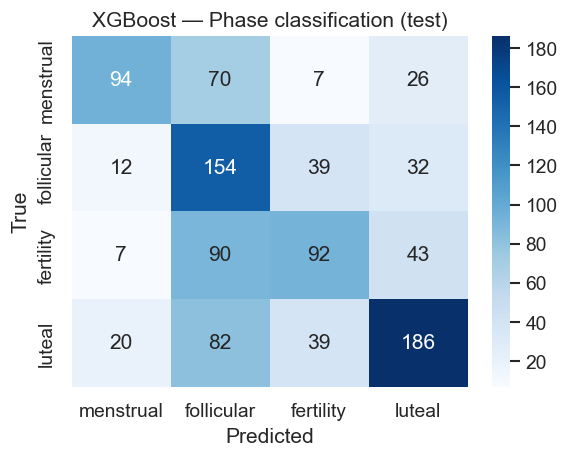


Per-class report:
              precision    recall  f1-score   support

   menstrual       0.71      0.48      0.57       197
  follicular       0.39      0.65      0.49       237
   fertility       0.52      0.40      0.45       232
      luteal       0.65      0.57      0.61       327

    accuracy                           0.53       993
   macro avg       0.57      0.52      0.53       993
weighted avg       0.57      0.53      0.53       993



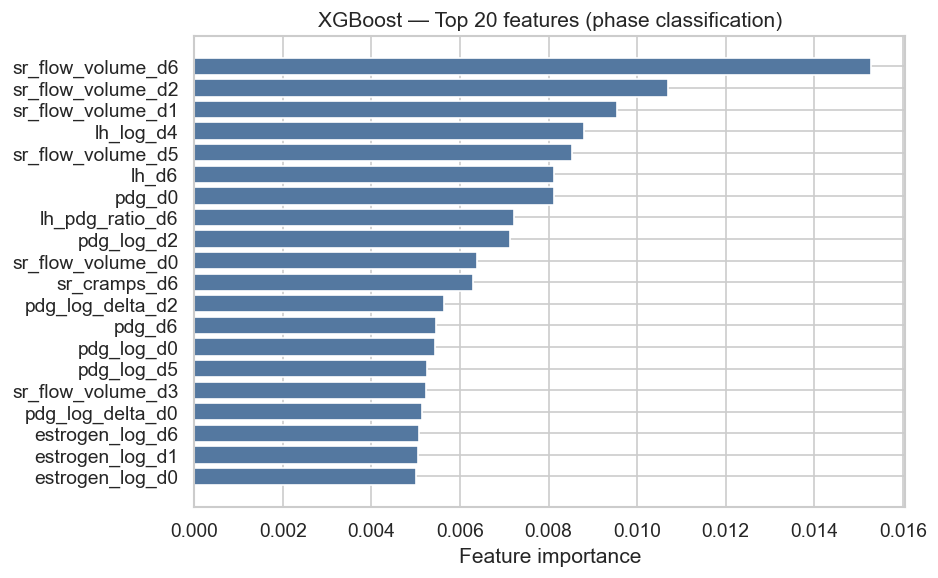


── Task B: Fertility detection (binary) ──
  scale_pos_weight = 3.43 (neg/pos ratio)
  Best iteration: 258
  [XGB_fertility_test]  Acc=0.8173  Macro-F1=0.5183  AUROC=0.7841


In [55]:
# ================================================================
# Cell 3.2 — XGBoost baseline
#
# Input: flatten (W, F) → (W*F,) vector (same as LR)
# Why XGBoost:
#   - Handles non-linear interactions LR misses
#   - scale_pos_weight handles fertility imbalance automatically
#   - tree_method='hist' is fast on CPU
#   - early stopping on val set prevents overfitting
# ================================================================

import xgboost as xgb

# ── Task A: Phase classification ──────────────────────────────
print('── Task A: Phase classification (4-class) ──')

# Compute class weights for XGBoost
# XGBoost uses sample_weight, not class_weight
from sklearn.utils.class_weight import compute_sample_weight

sw_tr = compute_sample_weight('balanced', y_tr)

xgb_phase = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=N_CLASSES,
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    use_label_encoder=False,
    eval_metric='mlogloss',
    early_stopping_rounds=30,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)

xgb_phase.fit(
    X_tr_flat, y_tr,
    sample_weight=sw_tr,
    eval_set=[(X_va_flat, y_va)],
    verbose=False,
)

print(f'  Best iteration: {xgb_phase.best_iteration}')

# Val
y_va_pred_xgb = xgb_phase.predict(X_va_flat)
y_va_prob_xgb = xgb_phase.predict_proba(X_va_flat)
res_xgb_val   = evaluate(y_va, y_va_pred_xgb, y_va_prob_xgb,
                          task='phase', label='XGB_phase_val')

# Test
y_te_pred_xgb = xgb_phase.predict(X_te_flat)
y_te_prob_xgb = xgb_phase.predict_proba(X_te_flat)
res_xgb_test  = evaluate(y_te, y_te_pred_xgb, y_te_prob_xgb,
                          task='phase', label='XGB_phase_test')

ALL_RESULTS.append(res_xgb_test)

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_te, y_te_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=list(INV_PHASE_MAP.values()),
            yticklabels=list(INV_PHASE_MAP.values()))
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('XGBoost — Phase classification (test)')
plt.tight_layout(); plt.show()

print('\nPer-class report:')
print(classification_report(
    y_te, y_te_pred_xgb,
    target_names=list(INV_PHASE_MAP.values()),
    zero_division=0
))

# Feature importance (top 20)
importances = xgb_phase.feature_importances_
feat_names  = [f'{SCALE_FEATURES[i % N_FEATURES]}_d{i // N_FEATURES}'
               for i in range(len(importances))]
top20_idx   = np.argsort(importances)[::-1][:20]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    [feat_names[i] for i in top20_idx][::-1],
    importances[top20_idx][::-1],
    color='#5478A0', edgecolor='white'
)
ax.set_xlabel('Feature importance')
ax.set_title('XGBoost — Top 20 features (phase classification)')
plt.tight_layout(); plt.show()


# ── Task B: Fertility detection ───────────────────────────────
print('\n── Task B: Fertility detection (binary) ──')

# Fertility is imbalanced — use scale_pos_weight
n_neg = (y_tr_f[fert_tr_mask] == 0).sum()
n_pos = (y_tr_f[fert_tr_mask] == 1).sum()
spw   = n_neg / n_pos if n_pos > 0 else 1.0
print(f'  scale_pos_weight = {spw:.2f} (neg/pos ratio)')

xgb_fert = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    tree_method='hist',
    use_label_encoder=False,
    eval_metric='logloss',
    early_stopping_rounds=30,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)

xgb_fert.fit(
    X_tr_f_flat[fert_tr_mask],
    y_tr_f[fert_tr_mask].astype(int),
    eval_set=[(X_va_f_flat[fert_va_mask],
               y_va_f[fert_va_mask].astype(int))],
    verbose=False,
)

print(f'  Best iteration: {xgb_fert.best_iteration}')

yf_te_pred_xgb = xgb_fert.predict(X_te_f_flat[fert_te_mask])
yf_te_prob_xgb = xgb_fert.predict_proba(X_te_f_flat[fert_te_mask])
res_xgbf_test  = evaluate(
    y_te_f[fert_te_mask].astype(int),
    yf_te_pred_xgb, yf_te_prob_xgb,
    task='fertility', label='XGB_fertility_test'
)
ALL_RESULTS.append(res_xgbf_test)

Task A: Phase classification (W=7)
Trainable parameters: 599,044
    Epoch  10 | train loss=0.1204 acc=0.956 | val loss=1.8350 acc=0.643 | lr=5.00e-04
    Early stop at epoch 16 (best epoch=1, best val_loss=1.0793)
    Loaded best weights from epoch 1 (val_loss=1.0793)

Training diagnostics:


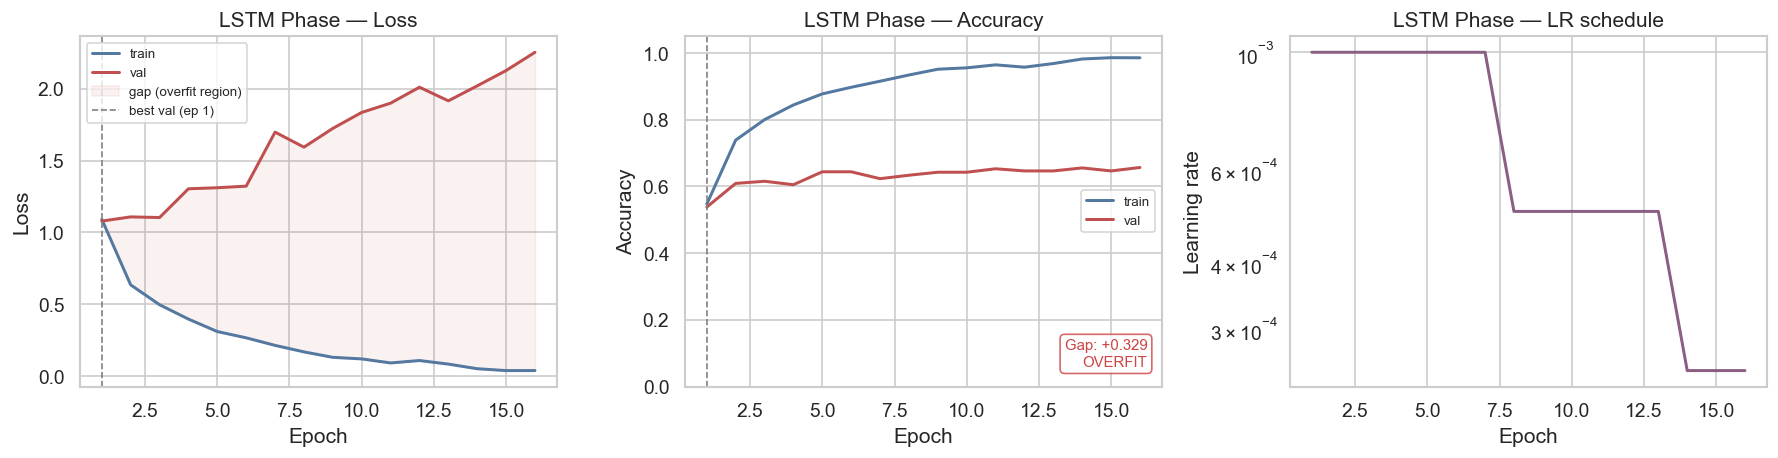

  Train loss:  1.0920 → 0.0393
  Val   loss:  1.0793 → 2.2535
  Train acc:   0.547  → 0.986
  Val   acc:   0.538  → 0.657
  Final gap (train-val acc): +0.329  → OVERFIT
  Best val epoch: 1
  [LSTM_phase_test]  Acc=0.4935  Macro-F1=0.4991  AUROC=0.7481


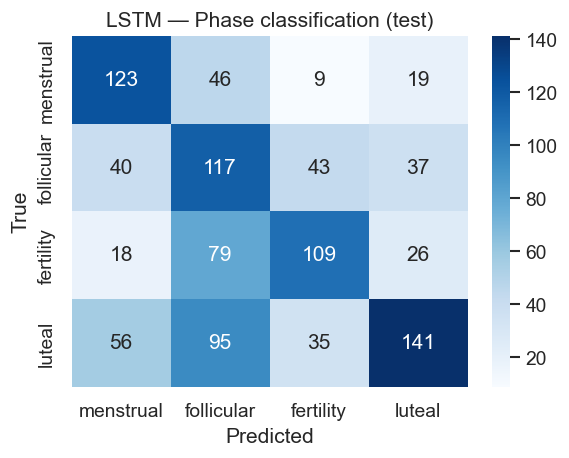


Per-class report:
              precision    recall  f1-score   support

   menstrual       0.52      0.62      0.57       197
  follicular       0.35      0.49      0.41       237
   fertility       0.56      0.47      0.51       232
      luteal       0.63      0.43      0.51       327

    accuracy                           0.49       993
   macro avg       0.51      0.50      0.50       993
weighted avg       0.52      0.49      0.50       993

lstm_phase.pt saved

Task B: Fertility detection (W=5)
Fertility positive rate — train: 22.6%  val: 23.3%  test: 23.5%
    Epoch  10 | train loss=0.0401 acc=0.986 | val loss=1.7540 acc=0.786 | lr=5.00e-04
    Early stop at epoch 17 (best epoch=2, best val_loss=0.4556)
    Loaded best weights from epoch 2 (val_loss=0.4556)

Training diagnostics:


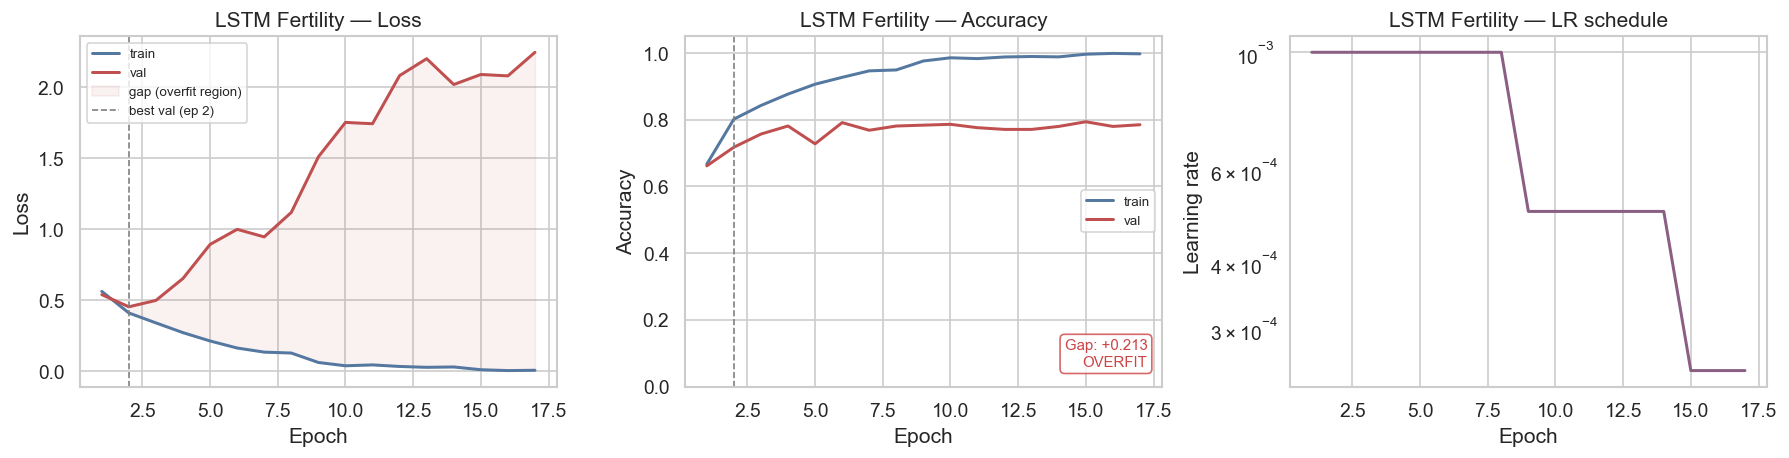

  Train loss:  0.5641 → 0.0085
  Val   loss:  0.5410 → 2.2480
  Train acc:   0.667  → 0.998
  Val   acc:   0.662  → 0.785
  Final gap (train-val acc): +0.213  → OVERFIT
  Best val epoch: 2
  [LSTM_fertility_test]  Acc=0.7478  Macro-F1=0.5208  AUROC=0.7703
lstm_fertility.pt saved


In [57]:
# ================================================================
# Cell 3.3 — LSTM baseline (fixed + training visualization)
# ================================================================

class CycleDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers,
                 num_classes, dropout=0.3, bidirectional=True):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
            bidirectional=bidirectional,
        )
        direction_factor = 2 if bidirectional else 1
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * direction_factor, num_classes)

    def forward(self, x):
        out, (hn, _) = self.lstm(x)
        if self.lstm.bidirectional:
            last_hidden = torch.cat([hn[-2], hn[-1]], dim=-1)
        else:
            last_hidden = hn[-1]
        last_hidden = self.dropout(last_hidden)
        return self.classifier(last_hidden)


def train_model(model, train_loader, val_loader,
                n_epochs, lr, class_weights=None, patience=15):
    """
    Training loop with early stopping.
    Returns model (best weights), train_losses, val_losses,
    train_accs, val_accs per epoch.
    Fix: removed verbose= from ReduceLROnPlateau (removed in PyTorch 2.x)
    """
    optimizer = torch.optim.Adam(
        model.parameters(), lr=lr, weight_decay=1e-4
    )
    # ── FIX: remove verbose= argument ────────────────────────
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    best_val_loss = float('inf')
    best_state    = None
    no_improve    = 0

    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []
    lr_history = []

    for epoch in range(n_epochs):

        # ── Train ─────────────────────────────────────────────
        model.train()
        epoch_loss   = 0.0
        correct      = 0
        total        = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            epoch_loss += loss.item()
            preds       = logits.argmax(dim=1)
            correct    += (preds == y_batch).sum().item()
            total      += len(y_batch)

        train_loss = epoch_loss / len(train_loader)
        train_acc  = correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # ── Val ───────────────────────────────────────────────
        model.eval()
        val_loss  = 0.0
        v_correct = 0
        v_total   = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                logits   = model(X_batch)
                val_loss += criterion(logits, y_batch).item()
                preds     = logits.argmax(dim=1)
                v_correct += (preds == y_batch).sum().item()
                v_total   += len(y_batch)

        val_loss = val_loss / len(val_loader)
        val_acc  = v_correct / v_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        # Track current LR
        current_lr = optimizer.param_groups[0]['lr']
        lr_history.append(current_lr)

        scheduler.step(val_loss)

        # ── Early stopping ────────────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone()
                             for k, v in model.state_dict().items()}
            no_improve    = 0
            best_epoch    = epoch + 1
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'    Early stop at epoch {epoch+1} '
                      f'(best epoch={best_epoch}, '
                      f'best val_loss={best_val_loss:.4f})')
                break

        if (epoch + 1) % 10 == 0:
            print(f'    Epoch {epoch+1:>3} | '
                  f'train loss={train_loss:.4f} acc={train_acc:.3f} | '
                  f'val loss={val_loss:.4f} acc={val_acc:.3f} | '
                  f'lr={current_lr:.2e}')

    model.load_state_dict(best_state)
    print(f'    Loaded best weights from epoch {best_epoch} '
          f'(val_loss={best_val_loss:.4f})')

    return model, train_losses, val_losses, train_accs, val_accs, lr_history


def plot_training_curves(train_losses, val_losses,
                         train_accs,   val_accs,
                         lr_history,   title=''):
    """
    3-panel training diagnostic:
      Left:   loss curves (train vs val) — overfit check
      Middle: accuracy curves (train vs val)
      Right:  learning rate schedule
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    epochs = range(1, len(train_losses) + 1)

    # ── Loss ─────────────────────────────────────────────────
    ax = axes[0]
    ax.plot(epochs, train_losses, label='train', color='#5478A0', lw=1.8)
    ax.plot(epochs, val_losses,   label='val',   color='#C05050', lw=1.8)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title(f'{title} — Loss')
    ax.legend()

    # Shade gap between train and val to visualise overfit
    ax.fill_between(epochs, train_losses, val_losses,
                    alpha=0.08, color='#C05050',
                    label='gap (overfit region)')

    # Mark best val epoch
    best_ep = int(np.argmin(val_losses)) + 1
    ax.axvline(best_ep, ls='--', color='gray', lw=1,
               label=f'best val (ep {best_ep})')
    ax.legend(fontsize=8)

    # ── Accuracy ──────────────────────────────────────────────
    ax = axes[1]
    ax.plot(epochs, train_accs, label='train', color='#5478A0', lw=1.8)
    ax.plot(epochs, val_accs,   label='val',   color='#C05050', lw=1.8)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.set_title(f'{title} — Accuracy')
    ax.set_ylim(0, 1.05)
    ax.axvline(best_ep, ls='--', color='gray', lw=1)
    ax.legend(fontsize=8)

    # Overfit diagnosis annotation
    final_gap = train_accs[-1] - val_accs[-1]
    if final_gap > 0.15:
        status = 'OVERFIT'
        color  = '#cc4444'
    elif val_accs[-1] < 0.4:
        status = 'UNDERFIT'
        color  = '#e69c4f'
    else:
        status = 'OK'
        color  = '#4c9e6d'
    ax.text(0.97, 0.05, f'Gap: {final_gap:+.3f}\n{status}',
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=9, color=color,
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white', edgecolor=color, alpha=0.8))

    # ── LR schedule ───────────────────────────────────────────
    ax = axes[2]
    ax.plot(epochs, lr_history, color='#8B5E84', lw=1.8)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Learning rate')
    ax.set_title(f'{title} — LR schedule')
    ax.set_yscale('log')

    plt.tight_layout()
    plt.show()

    # Print summary
    print(f'  Train loss:  {train_losses[0]:.4f} → {train_losses[-1]:.4f}')
    print(f'  Val   loss:  {val_losses[0]:.4f} → {val_losses[-1]:.4f}')
    print(f'  Train acc:   {train_accs[0]:.3f}  → {train_accs[-1]:.3f}')
    print(f'  Val   acc:   {val_accs[0]:.3f}  → {val_accs[-1]:.3f}')
    print(f'  Final gap (train-val acc): {final_gap:+.3f}  → {status}')
    print(f'  Best val epoch: {best_ep}')


def predict_model(model, X_np, batch_size=256):
    model.eval()
    all_probs = []
    loader    = DataLoader(
        torch.tensor(X_np, dtype=torch.float32),
        batch_size=batch_size
    )
    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(DEVICE)
            probs   = F.softmax(model(X_batch), dim=-1)
            all_probs.append(probs.cpu().numpy())
    probs  = np.concatenate(all_probs, axis=0)
    return probs.argmax(axis=1), probs


def compute_class_weights(y, n_classes):
    from sklearn.utils.class_weight import compute_class_weight
    w = compute_class_weight(
        'balanced', classes=np.arange(n_classes), y=y
    )
    return torch.tensor(w, dtype=torch.float32).to(DEVICE)


# ── Hyperparameters ───────────────────────────────────────────
LSTM_CFG = {
    'hidden_dim':  128,
    'num_layers':  2,
    'dropout':     0.3,
    'batch_size':  64,
    'n_epochs':    100,
    'lr':          1e-3,
    'patience':    15,
}

# =============================================================
# Task A: Phase classification (W=7)
# =============================================================
print('='*55)
print('Task A: Phase classification (W=7)')
print('='*55)

train_ds = CycleDataset(X_tr, y_tr)
val_ds   = CycleDataset(X_va, y_va)
train_dl = DataLoader(train_ds, batch_size=LSTM_CFG['batch_size'],
                      shuffle=True,  drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=LSTM_CFG['batch_size'],
                      shuffle=False)

cw_phase = compute_class_weights(y_tr, N_CLASSES)

lstm_phase = LSTMClassifier(
    input_dim    = N_FEATURES,
    hidden_dim   = LSTM_CFG['hidden_dim'],
    num_layers   = LSTM_CFG['num_layers'],
    num_classes  = N_CLASSES,
    dropout      = LSTM_CFG['dropout'],
    bidirectional= True,
).to(DEVICE)

n_params = sum(p.numel() for p in lstm_phase.parameters()
               if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')

(lstm_phase,
 tr_losses,  va_losses,
 tr_accs,    va_accs,
 lr_hist) = train_model(
    lstm_phase, train_dl, val_dl,
    n_epochs      = LSTM_CFG['n_epochs'],
    lr            = LSTM_CFG['lr'],
    class_weights = cw_phase,
    patience      = LSTM_CFG['patience'],
)

print('\nTraining diagnostics:')
plot_training_curves(
    tr_losses, va_losses,
    tr_accs,   va_accs,
    lr_hist,   title='LSTM Phase'
)

# Evaluate on test
y_te_pred_lstm, y_te_prob_lstm = predict_model(lstm_phase, X_te)
res_lstm_test = evaluate(
    y_te, y_te_pred_lstm, y_te_prob_lstm,
    task='phase', label='LSTM_phase_test'
)
ALL_RESULTS.append(res_lstm_test)

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_te, y_te_pred_lstm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=list(INV_PHASE_MAP.values()),
            yticklabels=list(INV_PHASE_MAP.values()))
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('LSTM — Phase classification (test)')
plt.tight_layout(); plt.show()

print('\nPer-class report:')
print(classification_report(
    y_te, y_te_pred_lstm,
    target_names=list(INV_PHASE_MAP.values()),
    zero_division=0
))

torch.save(lstm_phase.state_dict(),
           os.path.join(RESULTS_DIR, 'lstm_phase.pt'))
print('lstm_phase.pt saved')


# =============================================================
# Task B: Fertility detection (W=5)
# =============================================================
print('\n' + '='*55)
print('Task B: Fertility detection (W=5)')
print('='*55)

fert_tr_mask = ~np.isnan(y_tr_f)
fert_va_mask = ~np.isnan(y_va_f)
fert_te_mask = ~np.isnan(y_te_f)

print(f'Fertility positive rate — '
      f'train: {y_tr_f[fert_tr_mask].mean()*100:.1f}%  '
      f'val: {y_va_f[fert_va_mask].mean()*100:.1f}%  '
      f'test: {y_te_f[fert_te_mask].mean()*100:.1f}%')

train_ds_f = CycleDataset(
    X_tr_f[fert_tr_mask], y_tr_f[fert_tr_mask].astype(int)
)
val_ds_f   = CycleDataset(
    X_va_f[fert_va_mask], y_va_f[fert_va_mask].astype(int)
)
train_dl_f = DataLoader(train_ds_f,
                        batch_size=LSTM_CFG['batch_size'],
                        shuffle=True, drop_last=True)
val_dl_f   = DataLoader(val_ds_f,
                        batch_size=LSTM_CFG['batch_size'],
                        shuffle=False)

cw_fert = compute_class_weights(
    y_tr_f[fert_tr_mask].astype(int), n_classes=2
)

lstm_fert = LSTMClassifier(
    input_dim    = N_FEATURES,
    hidden_dim   = LSTM_CFG['hidden_dim'],
    num_layers   = LSTM_CFG['num_layers'],
    num_classes  = 2,
    dropout      = LSTM_CFG['dropout'],
    bidirectional= True,
).to(DEVICE)

(lstm_fert,
 tr_losses_f, va_losses_f,
 tr_accs_f,   va_accs_f,
 lr_hist_f) = train_model(
    lstm_fert, train_dl_f, val_dl_f,
    n_epochs      = LSTM_CFG['n_epochs'],
    lr            = LSTM_CFG['lr'],
    class_weights = cw_fert,
    patience      = LSTM_CFG['patience'],
)

print('\nTraining diagnostics:')
plot_training_curves(
    tr_losses_f, va_losses_f,
    tr_accs_f,   va_accs_f,
    lr_hist_f,   title='LSTM Fertility'
)

yf_te_pred_lstm, yf_te_prob_lstm = predict_model(
    lstm_fert, X_te_f[fert_te_mask]
)
res_lstmf_test = evaluate(
    y_te_f[fert_te_mask].astype(int),
    yf_te_pred_lstm, yf_te_prob_lstm,
    task='fertility', label='LSTM_fertility_test'
)
ALL_RESULTS.append(res_lstmf_test)

torch.save(lstm_fert.state_dict(),
           os.path.join(RESULTS_DIR, 'lstm_fertility.pt'))
print('lstm_fertility.pt saved')

Task A: Phase classification (W=7)
Trainable parameters: 419,972
    Epoch  10 | train loss=0.5543 acc=0.779 | val loss=0.9300 acc=0.636 | lr=3.00e-04
    Early stop at epoch 19 (best epoch=4, best val_loss=0.8984)
    Loaded best weights from epoch 4 (val_loss=0.8984)

Training diagnostics:


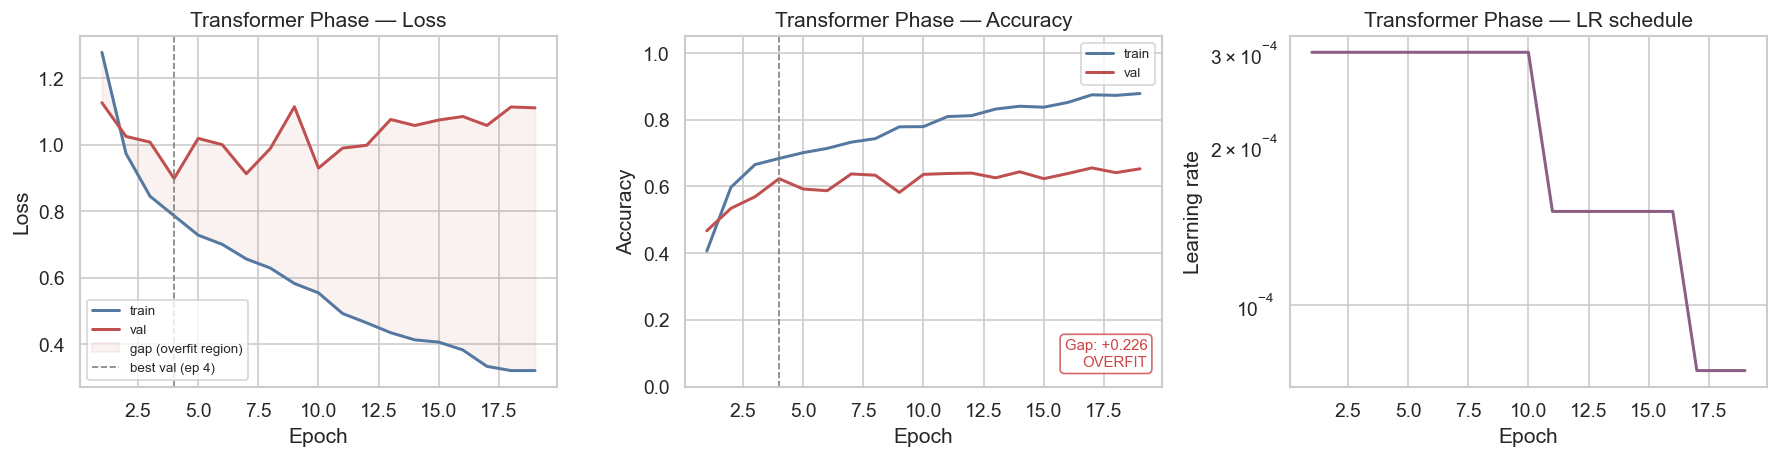

  Train loss:  1.2785 → 0.3204
  Val   loss:  1.1267 → 1.1113
  Train acc:   0.407  → 0.879
  Val   acc:   0.467  → 0.653
  Final gap (train-val acc): +0.226  → OVERFIT
  Best val epoch: 4
  [Transformer_phase_test]  Acc=0.5116  Macro-F1=0.5152  AUROC=0.7649


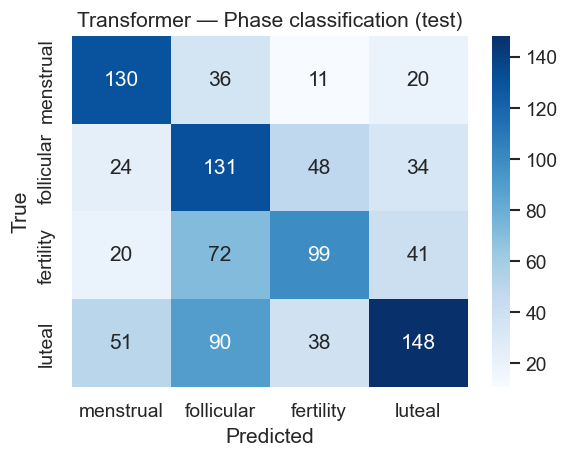


Per-class report:
              precision    recall  f1-score   support

   menstrual       0.58      0.66      0.62       197
  follicular       0.40      0.55      0.46       237
   fertility       0.51      0.43      0.46       232
      luteal       0.61      0.45      0.52       327

    accuracy                           0.51       993
   macro avg       0.52      0.52      0.52       993
weighted avg       0.53      0.51      0.51       993

transformer_phase.pt saved

Task B: Fertility detection (W=5)
Fertility positive rate — train: 22.6%  val:   23.3%  test:  23.5%
    Epoch  10 | train loss=0.3169 acc=0.853 | val loss=0.5760 acc=0.705 | lr=3.00e-04
    Early stop at epoch 20 (best epoch=5, best val_loss=0.4422)
    Loaded best weights from epoch 5 (val_loss=0.4422)

Training diagnostics:


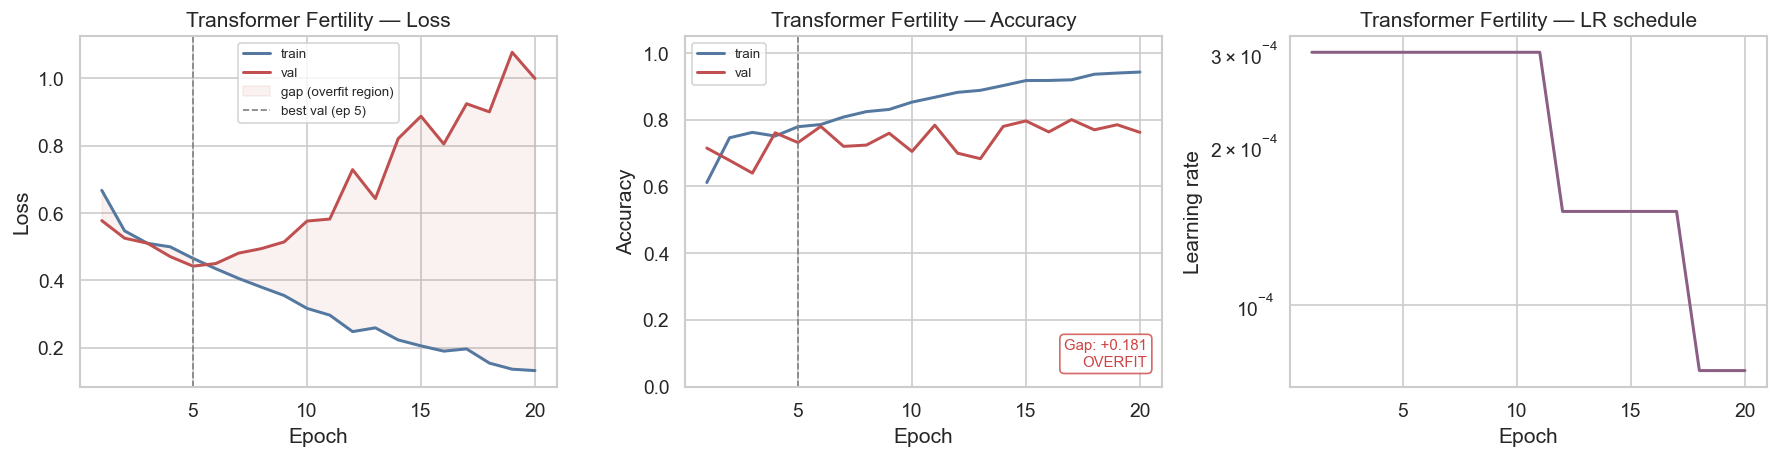

  Train loss:  0.6672 → 0.1323
  Val   loss:  0.5773 → 0.9990
  Train acc:   0.612  → 0.943
  Val   acc:   0.715  → 0.762
  Final gap (train-val acc): +0.181  → OVERFIT
  Best val epoch: 5
  [Transformer_fertility_test]  Acc=0.7378  Macro-F1=0.4864  AUROC=0.7415
transformer_fertility.pt saved


In [58]:
# ================================================================
# Cell 3.4 — Transformer baseline
#
# Architecture:
#   Input: (batch, W, F)
#   → Linear projection: F → d_model (128)
#   → Prepend learnable CLS token
#   → Learnable positional encoding
#   → N × TransformerEncoderLayer (nhead=4, dim_ff=256, pre-norm)
#   → CLS output → dropout → Linear classifier
#
# Why CLS token:
#   Same architecture will be reused in Part 4 SSL encoder.
#   The CLS vector becomes the "physiological embedding".
#   pre-norm (norm_first=True) is more stable than post-norm
#   for small datasets.
# ================================================================

class PositionalEncoding(nn.Module):
    """Learnable positional embedding."""
    def __init__(self, d_model, max_len=100):
        super().__init__()
        self.pe = nn.Embedding(max_len, d_model)

    def forward(self, x):
        seq_len = x.size(1)
        pos     = torch.arange(seq_len, device=x.device).unsqueeze(0)
        return x + self.pe(pos)


class TransformerClassifier(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_layers,
                 dim_feedforward, num_classes, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.cls_token  = nn.Parameter(torch.randn(1, 1, d_model))
        self.pos_enc    = PositionalEncoding(d_model, max_len=100)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = nhead,
            dim_feedforward = dim_feedforward,
            dropout         = dropout,
            batch_first     = True,
            norm_first      = True,   # pre-norm: more stable
        )
        self.encoder    = nn.TransformerEncoder(encoder_layer,
                                                num_layers=num_layers)
        self.norm       = nn.LayerNorm(d_model)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        batch = x.size(0)

        x   = self.input_proj(x)                          # (B, T, d_model)
        cls = self.cls_token.expand(batch, -1, -1)        # (B, 1, d_model)
        x   = torch.cat([cls, x], dim=1)                  # (B, T+1, d_model)
        x   = self.pos_enc(x)                             # add pos encoding
        x   = self.encoder(x)                             # (B, T+1, d_model)

        cls_out = x[:, 0, :]                              # CLS token output
        cls_out = self.norm(cls_out)
        cls_out = self.dropout(cls_out)
        return self.classifier(cls_out)                   # (B, num_classes)


# ── Hyperparameters ───────────────────────────────────────────
TF_CFG = {
    'd_model':        128,
    'nhead':          4,      # d_model / nhead must be integer
    'num_layers':     3,
    'dim_feedforward':256,
    'dropout':        0.1,
    'batch_size':     64,
    'n_epochs':       100,
    'lr':             3e-4,   # lower LR than LSTM — standard for Transformers
    'patience':       15,
}


# =============================================================
# Task A: Phase classification (W=7)
# =============================================================
print('='*55)
print('Task A: Phase classification (W=7)')
print('='*55)

train_ds_tf = CycleDataset(X_tr, y_tr)
val_ds_tf   = CycleDataset(X_va, y_va)
train_dl_tf = DataLoader(train_ds_tf,
                          batch_size=TF_CFG['batch_size'],
                          shuffle=True, drop_last=True)
val_dl_tf   = DataLoader(val_ds_tf,
                          batch_size=TF_CFG['batch_size'],
                          shuffle=False)

tf_phase = TransformerClassifier(
    input_dim       = N_FEATURES,
    d_model         = TF_CFG['d_model'],
    nhead           = TF_CFG['nhead'],
    num_layers      = TF_CFG['num_layers'],
    dim_feedforward = TF_CFG['dim_feedforward'],
    num_classes     = N_CLASSES,
    dropout         = TF_CFG['dropout'],
).to(DEVICE)

n_params = sum(p.numel() for p in tf_phase.parameters()
               if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')

(tf_phase,
 tr_losses_tf,  va_losses_tf,
 tr_accs_tf,    va_accs_tf,
 lr_hist_tf) = train_model(
    tf_phase, train_dl_tf, val_dl_tf,
    n_epochs      = TF_CFG['n_epochs'],
    lr            = TF_CFG['lr'],
    class_weights = cw_phase,
    patience      = TF_CFG['patience'],
)

print('\nTraining diagnostics:')
plot_training_curves(
    tr_losses_tf, va_losses_tf,
    tr_accs_tf,   va_accs_tf,
    lr_hist_tf,   title='Transformer Phase'
)

# Test evaluation
y_te_pred_tf, y_te_prob_tf = predict_model(tf_phase, X_te)
res_tf_test = evaluate(
    y_te, y_te_pred_tf, y_te_prob_tf,
    task='phase', label='Transformer_phase_test'
)
ALL_RESULTS.append(res_tf_test)

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_te, y_te_pred_tf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=list(INV_PHASE_MAP.values()),
            yticklabels=list(INV_PHASE_MAP.values()))
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Transformer — Phase classification (test)')
plt.tight_layout(); plt.show()

print('\nPer-class report:')
print(classification_report(
    y_te, y_te_pred_tf,
    target_names=list(INV_PHASE_MAP.values()),
    zero_division=0
))

torch.save(tf_phase.state_dict(),
           os.path.join(RESULTS_DIR, 'transformer_phase.pt'))
print('transformer_phase.pt saved')


# =============================================================
# Task B: Fertility detection (W=5)
# =============================================================
print('\n' + '='*55)
print('Task B: Fertility detection (W=5)')
print('='*55)

# fert masks already defined in Cell 3.3
print(f'Fertility positive rate — '
      f'train: {y_tr_f[fert_tr_mask].mean()*100:.1f}%  '
      f'val:   {y_va_f[fert_va_mask].mean()*100:.1f}%  '
      f'test:  {y_te_f[fert_te_mask].mean()*100:.1f}%')

train_ds_tff = CycleDataset(
    X_tr_f[fert_tr_mask], y_tr_f[fert_tr_mask].astype(int)
)
val_ds_tff   = CycleDataset(
    X_va_f[fert_va_mask], y_va_f[fert_va_mask].astype(int)
)
train_dl_tff = DataLoader(train_ds_tff,
                           batch_size=TF_CFG['batch_size'],
                           shuffle=True, drop_last=True)
val_dl_tff   = DataLoader(val_ds_tff,
                           batch_size=TF_CFG['batch_size'],
                           shuffle=False)

tf_fert = TransformerClassifier(
    input_dim       = N_FEATURES,
    d_model         = TF_CFG['d_model'],
    nhead           = TF_CFG['nhead'],
    num_layers      = TF_CFG['num_layers'],
    dim_feedforward = TF_CFG['dim_feedforward'],
    num_classes     = 2,
    dropout         = TF_CFG['dropout'],
).to(DEVICE)

(tf_fert,
 tr_losses_tff, va_losses_tff,
 tr_accs_tff,   va_accs_tff,
 lr_hist_tff) = train_model(
    tf_fert, train_dl_tff, val_dl_tff,
    n_epochs      = TF_CFG['n_epochs'],
    lr            = TF_CFG['lr'],
    class_weights = cw_fert,
    patience      = TF_CFG['patience'],
)

print('\nTraining diagnostics:')
plot_training_curves(
    tr_losses_tff, va_losses_tff,
    tr_accs_tff,   va_accs_tff,
    lr_hist_tff,   title='Transformer Fertility'
)

yf_te_pred_tf, yf_te_prob_tf = predict_model(
    tf_fert, X_te_f[fert_te_mask]
)
res_tff_test = evaluate(
    y_te_f[fert_te_mask].astype(int),
    yf_te_pred_tf, yf_te_prob_tf,
    task='fertility', label='Transformer_fertility_test'
)
ALL_RESULTS.append(res_tff_test)

torch.save(tf_fert.state_dict(),
           os.path.join(RESULTS_DIR, 'transformer_fertility.pt'))
print('transformer_fertility.pt saved')

BASELINE RESULTS — TEST SET

Task: PHASE


KeyError: '`Styler.apply` and `.map` are not compatible with non-unique index or columns.'


Task: FERTILITY


,Accuracy,Macro-F1,AUROC
model,,,
LR_fertility_test,0.7210,0.4787,0.7100
XGB_fertility_test,0.8173,0.5183,0.7841
LSTM_fertility_test,0.7478,0.5208,0.7703
Transformer_fertility_test,0.7378,0.4864,0.7415


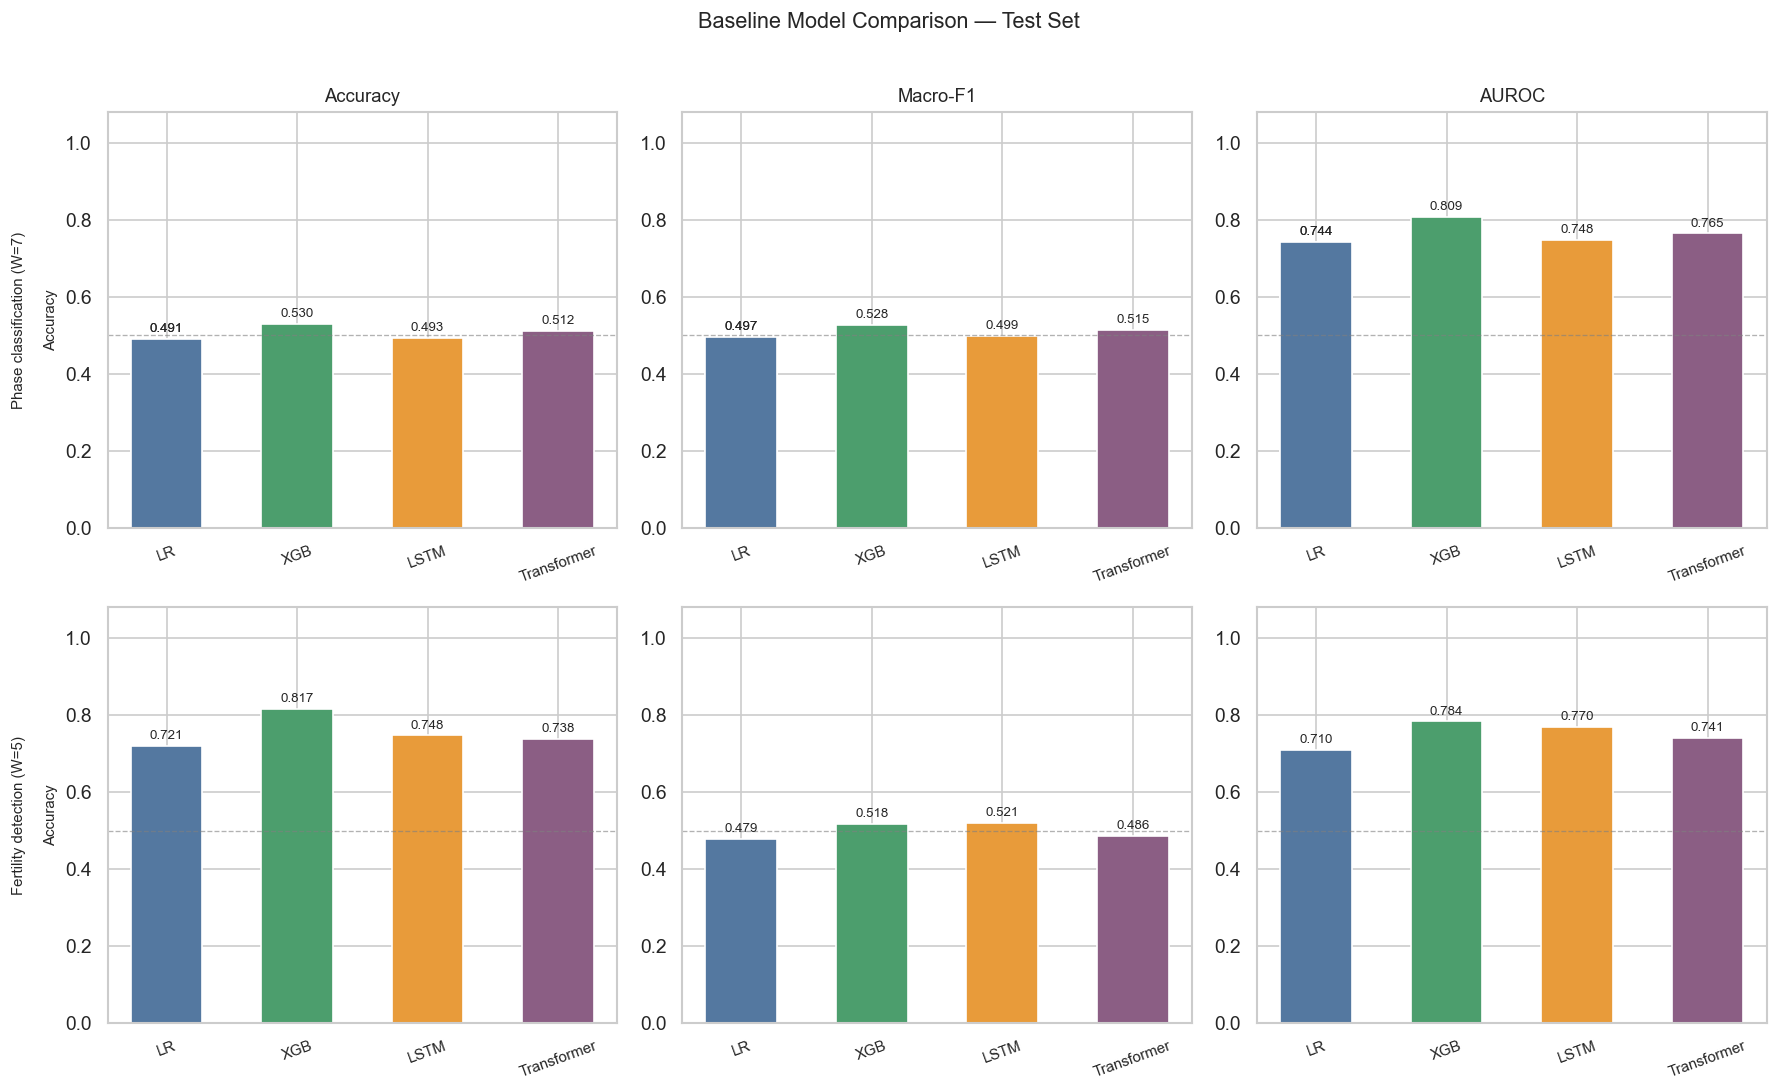


ROC curves — Phase classification (one-vs-rest)


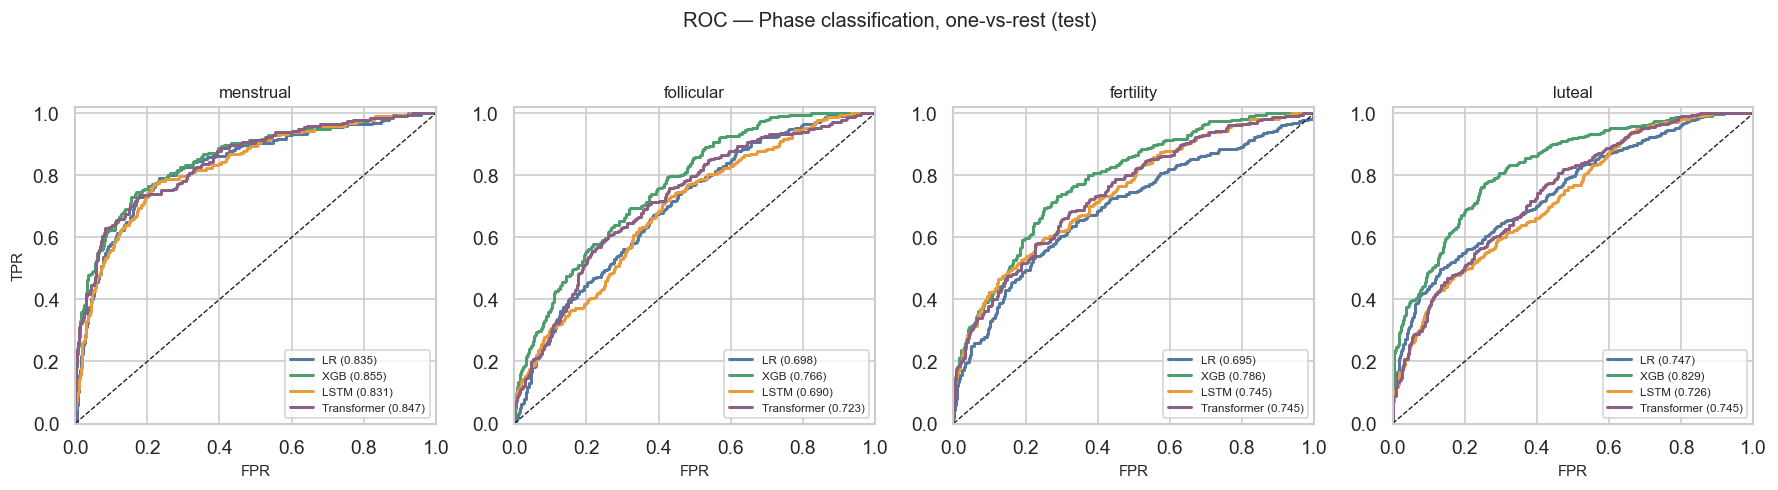

ROC curves — Fertility detection


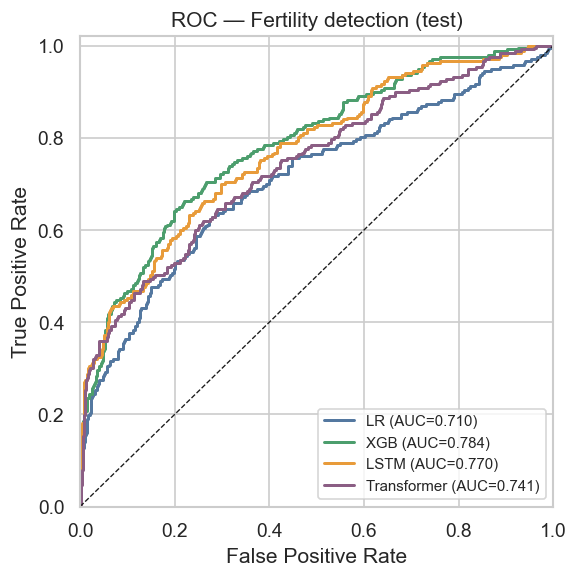


Per-class F1 — Phase classification (test)
             menstrual  follicular  fertility  luteal
LR              0.5782      0.4390     0.4295  0.5411
XGB             0.5697      0.4866     0.4499  0.6059
LSTM            0.5668      0.4077     0.5093  0.5127
Transformer     0.6161      0.4629     0.4626  0.5193


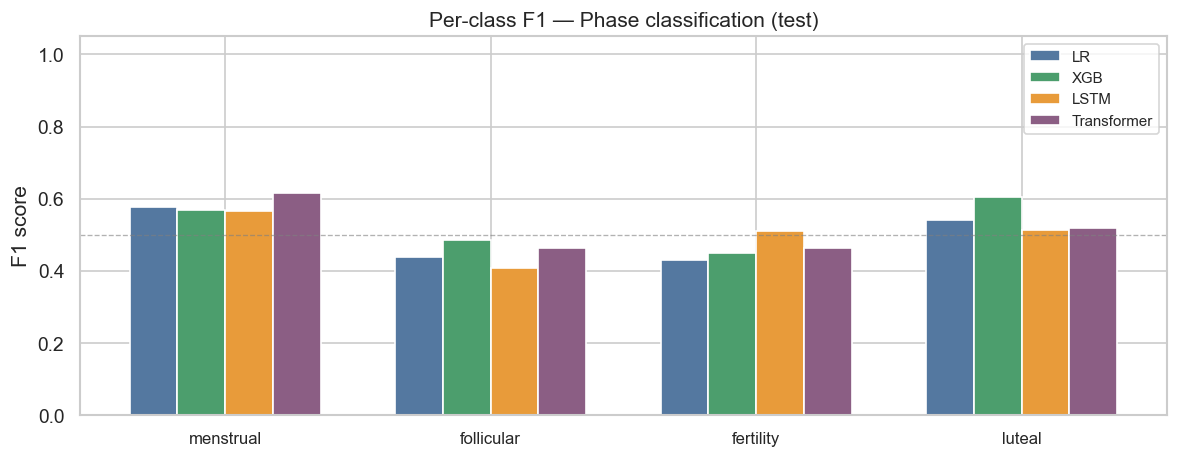


Hardest phase to classify: follicular (mean F1=0.449)
→ This is expected: ovulation has the fewest training samples

Model complexity vs performance (phase classification)


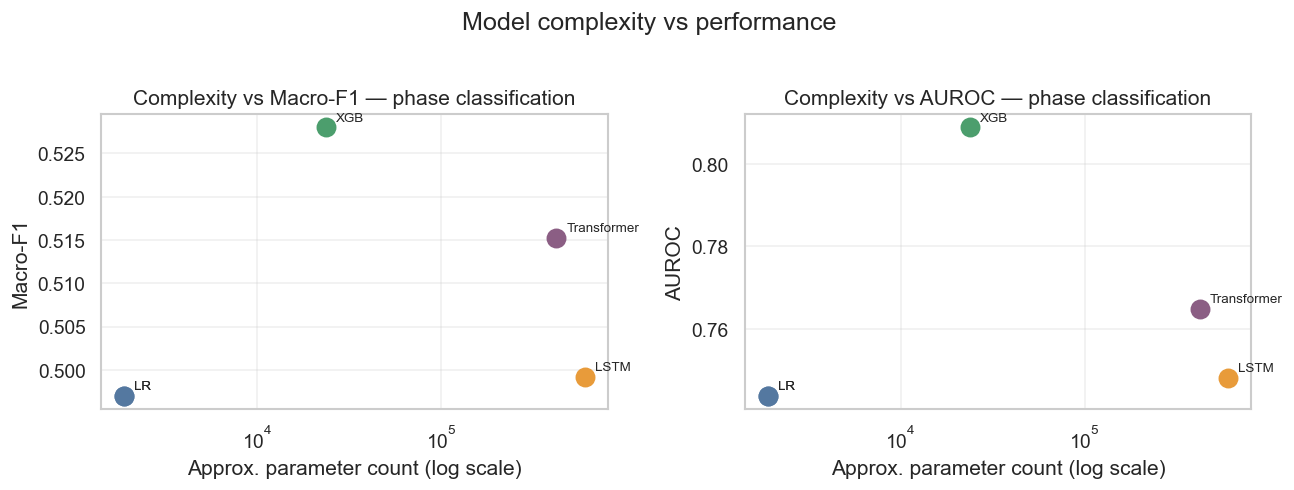


Saved:
  /Users/luozixiao/Desktop/mcphases/results/baseline_results.csv
  /Users/luozixiao/Desktop/mcphases/results/per_class_f1.csv

Part 3 complete.
These results are the RQ2 raw-feature baseline.
Next: Part 4 — SSL Encoder + Embedding-based prediction


In [59]:
# ================================================================
# Cell 3.5 — Final comparison across all baseline models
#
# Produces:
#   1. Summary table per task
#   2. Grouped bar chart (Acc / F1 / AUROC) per task
#   3. ROC curves — phase (one-vs-rest, 4 models overlaid)
#   4. ROC curve — fertility (4 models overlaid)
#   5. Per-class F1 grouped bar chart
#   6. Save results CSV
# ================================================================

from sklearn.metrics import roc_curve, auc, f1_score as sk_f1

results_df = pd.DataFrame(ALL_RESULTS)

# ── 1. Summary table ──────────────────────────────────────────
print('='*65)
print('BASELINE RESULTS — TEST SET')
print('='*65)

for task in ['phase', 'fertility']:
    sub = (results_df[results_df['task'] == task]
           .copy()
           [['model','acc','f1','auroc']]
           .set_index('model'))
    sub.columns = ['Accuracy', 'Macro-F1', 'AUROC']
    print(f'\nTask: {task.upper()}')
    display(
        sub.style
        .highlight_max(axis=0, color='#c8e6c9')
        .highlight_min(axis=0, color='#ffcdd2')
        .format('{:.4f}')
        .set_caption(f'{task} — test set')
    )


# ── 2. Grouped bar chart ──────────────────────────────────────
MODEL_COLORS = {
    'LR':          '#5478A0',
    'XGB':         '#4c9e6d',
    'LSTM':        '#E89B3A',
    'Transformer': '#8B5E84',
}

def short_name(model_str, task):
    """'LR_phase_test' → 'LR'"""
    return model_str.replace(f'_{task}_test', '')

metrics     = ['acc',        'f1',       'auroc']
met_labels  = ['Accuracy',   'Macro-F1', 'AUROC']
tasks       = ['phase',      'fertility']
task_titles = ['Phase classification (W=7)',
               'Fertility detection (W=5)']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for row, (task, ttitle) in enumerate(zip(tasks, task_titles)):
    sub = results_df[results_df['task'] == task].copy()
    sub['short'] = sub['model'].apply(lambda m: short_name(m, task))

    for col, (metric, mlabel) in enumerate(zip(metrics, met_labels)):
        ax = axes[row, col]
        colors = [MODEL_COLORS.get(n, '#aaa') for n in sub['short']]
        bars   = ax.bar(sub['short'], sub[metric],
                        color=colors, edgecolor='white', width=0.55)
        ax.set_ylim(0, 1.08)
        ax.set_ylabel(mlabel if col == 0 else '')
        ax.tick_params(axis='x', rotation=20, labelsize=9)
        ax.axhline(0.5, ls='--', color='gray', lw=0.8, alpha=0.6)

        # Value labels
        for bar, val in zip(bars, sub[metric]):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{val:.3f}',
                ha='center', va='bottom', fontsize=8
            )

        # Row label on first column
        if col == 0:
            ax.set_ylabel(f'{ttitle}\n\n{mlabel}', fontsize=9)
        # Column title on first row
        if row == 0:
            ax.set_title(mlabel, fontsize=11, fontweight='normal')

plt.suptitle('Baseline Model Comparison — Test Set',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


# ── 3. ROC curves — Phase (one-vs-rest) ──────────────────────
print('\nROC curves — Phase classification (one-vs-rest)')

y_te_bin = label_binarize(y_te, classes=list(range(N_CLASSES)))

phase_prob_map = {
    'LR':          y_te_prob_lr,
    'XGB':         y_te_prob_xgb,
    'LSTM':        y_te_prob_lstm,
    'Transformer': y_te_prob_tf,
}

fig, axes = plt.subplots(1, N_CLASSES, figsize=(15, 4))

for class_idx, ax in enumerate(axes):
    phase_name = INV_PHASE_MAP[class_idx]
    for mname, probs in phase_prob_map.items():
        fpr, tpr, _ = roc_curve(
            y_te_bin[:, class_idx], probs[:, class_idx]
        )
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=1.8,
                color=MODEL_COLORS[mname],
                label=f'{mname} ({roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_xlabel('FPR', fontsize=9)
    ax.set_ylabel('TPR' if class_idx == 0 else '', fontsize=9)
    ax.set_title(f'{phase_name}', fontsize=10)
    ax.legend(fontsize=7, loc='lower right')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

plt.suptitle('ROC — Phase classification, one-vs-rest (test)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


# ── 4. ROC curves — Fertility ─────────────────────────────────
print('ROC curves — Fertility detection')

fert_true = y_te_f[fert_te_mask].astype(int)

fert_prob_map = {
    'LR':          yf_te_prob[:, 1],
    'XGB':         yf_te_prob_xgb[:, 1],
    'LSTM':        yf_te_prob_lstm[:, 1],
    'Transformer': yf_te_prob_tf[:, 1],
}

fig, ax = plt.subplots(figsize=(5, 5))

for mname, probs in fert_prob_map.items():
    fpr, tpr, _ = roc_curve(fert_true, probs)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=1.8,
            color=MODEL_COLORS[mname],
            label=f'{mname} (AUC={roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC — Fertility detection (test)')
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()


# ── 5. Per-class F1 breakdown — Phase ────────────────────────
print('\nPer-class F1 — Phase classification (test)')

phase_pred_map = {
    'LR':          y_te_pred_lr,
    'XGB':         y_te_pred_xgb,
    'LSTM':        y_te_pred_lstm,
    'Transformer': y_te_pred_tf,
}

f1_matrix = {}
for mname, preds in phase_pred_map.items():
    f1s = sk_f1(
        y_te, preds,
        average=None,
        labels=list(range(N_CLASSES)),
        zero_division=0
    )
    f1_matrix[mname] = f1s

f1_df = pd.DataFrame(
    f1_matrix,
    index=[INV_PHASE_MAP[i] for i in range(N_CLASSES)]
).T

print(f1_df.round(4).to_string())

# Grouped bar
fig, ax = plt.subplots(figsize=(10, 4))
x      = np.arange(N_CLASSES)
n_mod  = len(phase_pred_map)
width  = 0.18
offsets = np.linspace(-(n_mod-1)/2, (n_mod-1)/2, n_mod) * width

for i, mname in enumerate(phase_pred_map):
    ax.bar(
        x + offsets[i],
        f1_matrix[mname],
        width=width,
        label=mname,
        color=MODEL_COLORS[mname],
        edgecolor='white'
    )

ax.set_xticks(x)
ax.set_xticklabels([INV_PHASE_MAP[i] for i in range(N_CLASSES)],
                   fontsize=10)
ax.set_ylabel('F1 score')
ax.set_ylim(0, 1.05)
ax.axhline(0.5, ls='--', color='gray', lw=0.8, alpha=0.6)
ax.set_title('Per-class F1 — Phase classification (test)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Highlight the hardest class
hardest = f1_df.mean().idxmin()
print(f'\nHardest phase to classify: {hardest} '
      f'(mean F1={f1_df.mean()[hardest]:.3f})')
print('→ This is expected: ovulation has the fewest training samples')


# ── 6. Model size vs performance scatter ─────────────────────
print('\nModel complexity vs performance (phase classification)')

# Rough parameter counts
param_counts = {
    'LR':          X_tr_flat.shape[1] * N_CLASSES,
    'XGB':         xgb_phase.best_iteration * 100,
    'LSTM':        sum(p.numel() for p in lstm_phase.parameters()),
    'Transformer': sum(p.numel() for p in tf_phase.parameters()),
}

phase_results = results_df[results_df['task'] == 'phase'].copy()
phase_results['short'] = phase_results['model'].apply(
    lambda m: short_name(m, 'phase')
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (metric, mlabel) in zip(axes,
        [('f1','Macro-F1'), ('auroc','AUROC')]):
    for _, row in phase_results.iterrows():
        mname = row['short']
        n_p   = param_counts.get(mname, 0)
        ax.scatter(n_p, row[metric], s=120,
                   color=MODEL_COLORS.get(mname, '#aaa'),
                   zorder=3)
        ax.annotate(mname, (n_p, row[metric]),
                    textcoords='offset points',
                    xytext=(6, 4), fontsize=8)
    ax.set_xscale('log')
    ax.set_xlabel('Approx. parameter count (log scale)')
    ax.set_ylabel(mlabel)
    ax.set_title(f'Complexity vs {mlabel} — phase classification')
    ax.grid(True, alpha=0.3)

plt.suptitle('Model complexity vs performance', y=1.02)
plt.tight_layout()
plt.show()


# ── 7. Save all results ───────────────────────────────────────
results_df.to_csv(
    os.path.join(RESULTS_DIR, 'baseline_results.csv'), index=False
)

# Also save per-class F1
f1_df.to_csv(
    os.path.join(RESULTS_DIR, 'per_class_f1.csv')
)

print(f'\nSaved:')
print(f'  {RESULTS_DIR}/baseline_results.csv')
print(f'  {RESULTS_DIR}/per_class_f1.csv')

print('\n' + '='*55)
print('Part 3 complete.')
print('These results are the RQ2 raw-feature baseline.')
print('Next: Part 4 — SSL Encoder + Embedding-based prediction')
print('='*55)

In [68]:
# ================================================================
# Cell 4.0 — Part 4 Setup
#
# Goal: 系统分析每个 modality 对预测性能的贡献
#
# RQ1: 多模态数据比单模态更好吗？哪个 modality 最重要？
#
# Conditions:
#   1. wearable_only      (Fitbit signals)
#   2. hormone_only       (LH, estrogen, PDG + engineered)
#   3. selfreport_only    (症状问卷 Likert 0-5)
#   4. wear_hormone       (Wearable + Hormone, no self-report)
#   5. wear_selfreport    (Wearable + Self-report, no hormone)
#   6. hormone_selfreport (Hormone + Self-report, no wearable)
#   7. all_modalities     (全部)
#
# Model: LSTM (best sequential baseline from Part 3)
# Also run: XGBoost (best non-sequential baseline) for comparison
#
# Tasks: phase classification (W=7) + fertility detection (W=5)
# ================================================================

import os, json, warnings, pickle
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})

OUTPUT_DIR  = '/Users/luozixiao/Desktop/mcphases/processed'
RESULTS_DIR = '/Users/luozixiao/Desktop/mcphases/results'
os.makedirs(RESULTS_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Load metadata ─────────────────────────────────────────────
with open(os.path.join(OUTPUT_DIR, 'feature_list.json'), 'r') as f:
    meta = json.load(f)

SCALE_FEATURES  = meta['features']
PHASE_MAP       = meta['phase_map']
INV_PHASE_MAP   = {v: k for k, v in PHASE_MAP.items()}
N_CLASSES       = meta['n_classes']
N_FEATURES      = meta['n_features']
WINDOW_MAIN     = meta['window_main']
WEARABLE_IDX    = meta['wearable_idx']
HORMONE_IDX     = meta['hormone_idx']
SELFREPORT_IDX  = meta['selfreport_idx']

# ── Load arrays ───────────────────────────────────────────────
X_tr = np.load(os.path.join(OUTPUT_DIR, 'X_train_W7.npy'))
y_tr = np.load(os.path.join(OUTPUT_DIR, 'y_train_W7.npy'))
X_va = np.load(os.path.join(OUTPUT_DIR, 'X_val_W7.npy'))
y_va = np.load(os.path.join(OUTPUT_DIR, 'y_val_W7.npy'))
X_te = np.load(os.path.join(OUTPUT_DIR, 'X_test_W7.npy'))
y_te = np.load(os.path.join(OUTPUT_DIR, 'y_test_W7.npy'))

X_tr_f = np.load(os.path.join(OUTPUT_DIR, 'X_train_W5.npy'))
y_tr_f = np.load(os.path.join(OUTPUT_DIR, 'y_ovu_train_W5.npy'))
X_va_f = np.load(os.path.join(OUTPUT_DIR, 'X_val_W5.npy'))
y_va_f = np.load(os.path.join(OUTPUT_DIR, 'y_ovu_val_W5.npy'))
X_te_f = np.load(os.path.join(OUTPUT_DIR, 'X_test_W5.npy'))
y_te_f = np.load(os.path.join(OUTPUT_DIR, 'y_ovu_test_W5.npy'))

fert_tr_mask = ~np.isnan(y_tr_f)
fert_va_mask = ~np.isnan(y_va_f)
fert_te_mask = ~np.isnan(y_te_f)

# ── Modality conditions ───────────────────────────────────────
MODALITY_CONDITIONS = {
    'wearable_only':      WEARABLE_IDX,
    'hormone_only':       HORMONE_IDX,
    'selfreport_only':    SELFREPORT_IDX,
    'wear_hormone':       WEARABLE_IDX + HORMONE_IDX,
    'wear_selfreport':    WEARABLE_IDX + SELFREPORT_IDX,
    'hormone_selfreport': HORMONE_IDX  + SELFREPORT_IDX,
    'all_modalities':     list(range(N_FEATURES)),
}

print(f'Device: {DEVICE}')
print(f'N_FEATURES: {N_FEATURES}')
print(f'\nModality conditions:')
for name, idx in MODALITY_CONDITIONS.items():
    print(f'  {name:<25} {len(idx):>3} features')

print(f'\nPhase classification: train={X_tr.shape} val={X_va.shape} test={X_te.shape}')
print(f'Fertility detection:  train={X_tr_f[fert_tr_mask].shape}')

Device: cpu
N_FEATURES: 68

Modality conditions:
  wearable_only              44 features
  hormone_only               11 features
  selfreport_only            13 features
  wear_hormone               55 features
  wear_selfreport            57 features
  hormone_selfreport         24 features
  all_modalities             68 features

Phase classification: train=(3639, 7, 68) val=(775, 7, 68) test=(993, 7, 68)
Fertility detection:  train=(3697, 5, 68)


In [69]:
# ================================================================
# Cell 4.1 — Shared model definitions & training utilities
# (reused from Part 3 — same LSTM and training loop)
# ================================================================

class CycleDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers,
                 num_classes, dropout=0.3, bidirectional=True):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
            bidirectional=bidirectional,
        )
        direction_factor = 2 if bidirectional else 1
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(
            hidden_dim * direction_factor, num_classes
        )

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        if self.lstm.bidirectional:
            last = torch.cat([hn[-2], hn[-1]], dim=-1)
        else:
            last = hn[-1]
        return self.classifier(self.dropout(last))


def get_class_weights(y, n_classes):
    w = compute_class_weight(
        'balanced', classes=np.arange(n_classes), y=y
    )
    return torch.tensor(w, dtype=torch.float32).to(DEVICE)


def train_lstm(model, X_tr, y_tr, X_va, y_va,
               n_epochs=80, lr=1e-3, batch_size=64,
               class_weights=None, patience=12):
    optimizer = torch.optim.Adam(
        model.parameters(), lr=lr, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=4, factor=0.5
    )
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    tr_dl = DataLoader(
        CycleDataset(X_tr, y_tr),
        batch_size=batch_size, shuffle=True, drop_last=True
    )
    va_dl = DataLoader(
        CycleDataset(X_va, y_va),
        batch_size=256, shuffle=False
    )

    best_loss  = float('inf')
    best_state = None
    no_improve = 0

    for epoch in range(n_epochs):
        model.train()
        for Xb, yb in tr_dl:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for Xb, yb in va_dl:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                val_loss += criterion(model(Xb), yb).item()
        val_loss /= len(va_dl)
        scheduler.step(val_loss)

        if val_loss < best_loss:
            best_loss  = val_loss
            best_state = {k: v.cpu().clone()
                          for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    model.load_state_dict(best_state)
    return model


@torch.no_grad()
def predict_lstm(model, X_np, batch_size=256):
    model.eval()
    loader = DataLoader(
        TensorDataset(torch.tensor(X_np, dtype=torch.float32)),
        batch_size=batch_size
    )
    probs = []
    for (Xb,) in loader:
        p = F.softmax(model(Xb.to(DEVICE)), dim=-1)
        probs.append(p.cpu().numpy())
    probs  = np.concatenate(probs)
    return probs.argmax(1), probs


def evaluate_condition(y_true, y_pred, y_prob, task, label):
    acc = accuracy_score(y_true, y_pred)
    if task == 'phase':
        f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        yb = label_binarize(y_true, classes=list(range(N_CLASSES)))
        try:
            auroc = roc_auc_score(yb, y_prob, average='macro',
                                  multi_class='ovr')
        except ValueError:
            auroc = float('nan')
    else:
        f1 = f1_score(y_true, y_pred, average='binary', zero_division=0)
        try:
            auroc = roc_auc_score(y_true, y_prob[:, 1])
        except ValueError:
            auroc = float('nan')

    return {'condition': label, 'task': task,
            'acc': acc, 'f1': f1, 'auroc': auroc}


LSTM_CFG = {
    'hidden_dim': 128,
    'num_layers': 2,
    'dropout':    0.3,
    'batch_size': 64,
    'n_epochs':   80,
    'lr':         1e-3,
    'patience':   12,
}

print('Model definitions ready ✓')
print(f'LSTM config: {LSTM_CFG}')

Model definitions ready ✓
LSTM config: {'hidden_dim': 128, 'num_layers': 2, 'dropout': 0.3, 'batch_size': 64, 'n_epochs': 80, 'lr': 0.001, 'patience': 12}


In [70]:
# ================================================================
# Cell 4.2 — Run ablation: Phase classification (W=7)
# ================================================================

print('='*60)
print('Ablation — Phase classification (W=7)')
print('='*60)

phase_results = []
cw_phase = get_class_weights(y_tr, N_CLASSES)

for cond_name, feat_idx in MODALITY_CONDITIONS.items():
    feat_idx = sorted(feat_idx)
    n_feat   = len(feat_idx)

    # Slice features
    Xtr_sub = X_tr[:, :, feat_idx]
    Xva_sub = X_va[:, :, feat_idx]
    Xte_sub = X_te[:, :, feat_idx]

    print(f'\n  [{cond_name}]  n_features={n_feat}')

    # ── LSTM ──────────────────────────────────────────────────
    model = LSTMClassifier(
        input_dim    = n_feat,
        hidden_dim   = LSTM_CFG['hidden_dim'],
        num_layers   = LSTM_CFG['num_layers'],
        num_classes  = N_CLASSES,
        dropout      = LSTM_CFG['dropout'],
        bidirectional= True,
    ).to(DEVICE)

    model = train_lstm(
        model, Xtr_sub, y_tr, Xva_sub, y_va,
        n_epochs      = LSTM_CFG['n_epochs'],
        lr            = LSTM_CFG['lr'],
        batch_size    = LSTM_CFG['batch_size'],
        class_weights = cw_phase,
        patience      = LSTM_CFG['patience'],
    )

    y_pred, y_prob = predict_lstm(model, Xte_sub)
    res = evaluate_condition(
        y_te, y_pred, y_prob,
        task='phase', label=f'LSTM_{cond_name}'
    )
    phase_results.append(res)
    print(f'    LSTM  Acc={res["acc"]:.4f}  '
          f'F1={res["f1"]:.4f}  AUROC={res["auroc"]:.4f}')

    # ── XGBoost (flat features) ────────────────────────────────
    Xtr_flat = Xtr_sub.reshape(len(Xtr_sub), -1)
    Xva_flat = Xva_sub.reshape(len(Xva_sub), -1)
    Xte_flat = Xte_sub.reshape(len(Xte_sub), -1)

    from sklearn.utils.class_weight import compute_sample_weight
    sw = compute_sample_weight('balanced', y_tr)

    xgb_model = xgb.XGBClassifier(
        objective         = 'multi:softprob',
        num_class         = N_CLASSES,
        n_estimators      = 300,
        max_depth         = 5,
        learning_rate     = 0.05,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        tree_method       = 'hist',
        eval_metric       = 'mlogloss',
        early_stopping_rounds = 20,
        random_state      = SEED,
        n_jobs            = -1,
        verbosity         = 0,
    )
    xgb_model.fit(
        Xtr_flat, y_tr,
        sample_weight = sw,
        eval_set      = [(Xva_flat, y_va)],
        verbose       = False,
    )

    xgb_pred  = xgb_model.predict(Xte_flat)
    xgb_prob  = xgb_model.predict_proba(Xte_flat)
    res_xgb   = evaluate_condition(
        y_te, xgb_pred, xgb_prob,
        task='phase', label=f'XGB_{cond_name}'
    )
    phase_results.append(res_xgb)
    print(f'    XGB   Acc={res_xgb["acc"]:.4f}  '
          f'F1={res_xgb["f1"]:.4f}  AUROC={res_xgb["auroc"]:.4f}')

phase_df = pd.DataFrame(phase_results)
phase_df.to_csv(
    os.path.join(RESULTS_DIR, 'ablation_phase.csv'), index=False
)
print(f'\nSaved ablation_phase.csv')

Ablation — Phase classification (W=7)

  [wearable_only]  n_features=44
    LSTM  Acc=0.3424  F1=0.3308  AUROC=0.6206
    XGB   Acc=0.3535  F1=0.3281  AUROC=0.6331

  [hormone_only]  n_features=11
    LSTM  Acc=0.5035  F1=0.4966  AUROC=0.7547
    XGB   Acc=0.5498  F1=0.5435  AUROC=0.7750

  [selfreport_only]  n_features=13
    LSTM  Acc=0.4562  F1=0.4163  AUROC=0.6761
    XGB   Acc=0.4602  F1=0.4328  AUROC=0.6952

  [wear_hormone]  n_features=55
    LSTM  Acc=0.5337  F1=0.5321  AUROC=0.7759
    XGB   Acc=0.5388  F1=0.5373  AUROC=0.7820

  [wear_selfreport]  n_features=57
    LSTM  Acc=0.4381  F1=0.4088  AUROC=0.6935
    XGB   Acc=0.4421  F1=0.4287  AUROC=0.7074

  [hormone_selfreport]  n_features=24
    LSTM  Acc=0.5599  F1=0.5545  AUROC=0.8048
    XGB   Acc=0.5911  F1=0.5855  AUROC=0.8213

  [all_modalities]  n_features=68
    LSTM  Acc=0.5086  F1=0.5122  AUROC=0.7678
    XGB   Acc=0.5498  F1=0.5448  AUROC=0.8160

Saved ablation_phase.csv


In [71]:
# ================================================================
# Cell 4.3 — Run ablation: Fertility detection (W=5)
# ================================================================

print('='*60)
print('Ablation — Fertility detection (W=5)')
print('='*60)

fert_results = []
cw_fert = get_class_weights(
    y_tr_f[fert_tr_mask].astype(int), n_classes=2
)

for cond_name, feat_idx in MODALITY_CONDITIONS.items():
    feat_idx = sorted(feat_idx)
    n_feat   = len(feat_idx)

    Xtr_sub = X_tr_f[fert_tr_mask][:, :, feat_idx]
    Xva_sub = X_va_f[fert_va_mask][:, :, feat_idx]
    Xte_sub = X_te_f[fert_te_mask][:, :, feat_idx]

    ytr_f = y_tr_f[fert_tr_mask].astype(int)
    yva_f = y_va_f[fert_va_mask].astype(int)
    yte_f = y_te_f[fert_te_mask].astype(int)

    print(f'\n  [{cond_name}]  n_features={n_feat}')

    # ── LSTM ──────────────────────────────────────────────────
    model_f = LSTMClassifier(
        input_dim    = n_feat,
        hidden_dim   = LSTM_CFG['hidden_dim'],
        num_layers   = LSTM_CFG['num_layers'],
        num_classes  = 2,
        dropout      = LSTM_CFG['dropout'],
        bidirectional= True,
    ).to(DEVICE)

    model_f = train_lstm(
        model_f, Xtr_sub, ytr_f, Xva_sub, yva_f,
        n_epochs      = LSTM_CFG['n_epochs'],
        lr            = LSTM_CFG['lr'],
        batch_size    = LSTM_CFG['batch_size'],
        class_weights = cw_fert,
        patience      = LSTM_CFG['patience'],
    )

    yf_pred, yf_prob = predict_lstm(model_f, Xte_sub)
    res_f = evaluate_condition(
        yte_f, yf_pred, yf_prob,
        task='fertility', label=f'LSTM_{cond_name}'
    )
    fert_results.append(res_f)
    print(f'    LSTM  Acc={res_f["acc"]:.4f}  '
          f'F1={res_f["f1"]:.4f}  AUROC={res_f["auroc"]:.4f}')

    # ── XGBoost ───────────────────────────────────────────────
    n_neg = (ytr_f == 0).sum()
    n_pos = (ytr_f == 1).sum()
    spw   = n_neg / n_pos if n_pos > 0 else 1.0

    Xtr_flat_f = Xtr_sub.reshape(len(Xtr_sub), -1)
    Xva_flat_f = Xva_sub.reshape(len(Xva_sub), -1)
    Xte_flat_f = Xte_sub.reshape(len(Xte_sub), -1)

    xgb_f = xgb.XGBClassifier(
        objective             = 'binary:logistic',
        n_estimators          = 300,
        max_depth             = 5,
        learning_rate         = 0.05,
        subsample             = 0.8,
        colsample_bytree      = 0.8,
        scale_pos_weight      = spw,
        tree_method           = 'hist',
        eval_metric           = 'logloss',
        early_stopping_rounds = 20,
        random_state          = SEED,
        n_jobs                = -1,
        verbosity             = 0,
    )
    xgb_f.fit(
        Xtr_flat_f, ytr_f,
        eval_set=[(Xva_flat_f, yva_f)],
        verbose=False,
    )

    xgb_pred_f = xgb_f.predict(Xte_flat_f)
    xgb_prob_f = xgb_f.predict_proba(Xte_flat_f)
    res_xgb_f  = evaluate_condition(
        yte_f, xgb_pred_f, xgb_prob_f,
        task='fertility', label=f'XGB_{cond_name}'
    )
    fert_results.append(res_xgb_f)
    print(f'    XGB   Acc={res_xgb_f["acc"]:.4f}  '
          f'F1={res_xgb_f["f1"]:.4f}  AUROC={res_xgb_f["auroc"]:.4f}')

fert_df = pd.DataFrame(fert_results)
fert_df.to_csv(
    os.path.join(RESULTS_DIR, 'ablation_fertility.csv'), index=False
)
print(f'\nSaved ablation_fertility.csv')

Ablation — Fertility detection (W=5)

  [wearable_only]  n_features=44
    LSTM  Acc=0.5929  F1=0.4006  AUROC=0.5950
    XGB   Acc=0.7031  F1=0.2689  AUROC=0.5538

  [hormone_only]  n_features=11
    LSTM  Acc=0.7200  F1=0.4758  AUROC=0.7356
    XGB   Acc=0.7984  F1=0.5290  AUROC=0.7567

  [selfreport_only]  n_features=13
    LSTM  Acc=0.5323  F1=0.3376  AUROC=0.5063
    XGB   Acc=0.6346  F1=0.2896  AUROC=0.5222

  [wear_hormone]  n_features=55
    LSTM  Acc=0.7249  F1=0.5466  AUROC=0.8026
    XGB   Acc=0.8054  F1=0.5025  AUROC=0.7840

  [wear_selfreport]  n_features=57
    LSTM  Acc=0.6167  F1=0.4043  AUROC=0.5925
    XGB   Acc=0.6931  F1=0.2993  AUROC=0.5617

  [hormone_selfreport]  n_features=24
    LSTM  Acc=0.7180  F1=0.4855  AUROC=0.7059
    XGB   Acc=0.7895  F1=0.4778  AUROC=0.7660

  [all_modalities]  n_features=68
    LSTM  Acc=0.7001  F1=0.4864  AUROC=0.7523
    XGB   Acc=0.8123  F1=0.5091  AUROC=0.7821

Saved ablation_fertility.csv


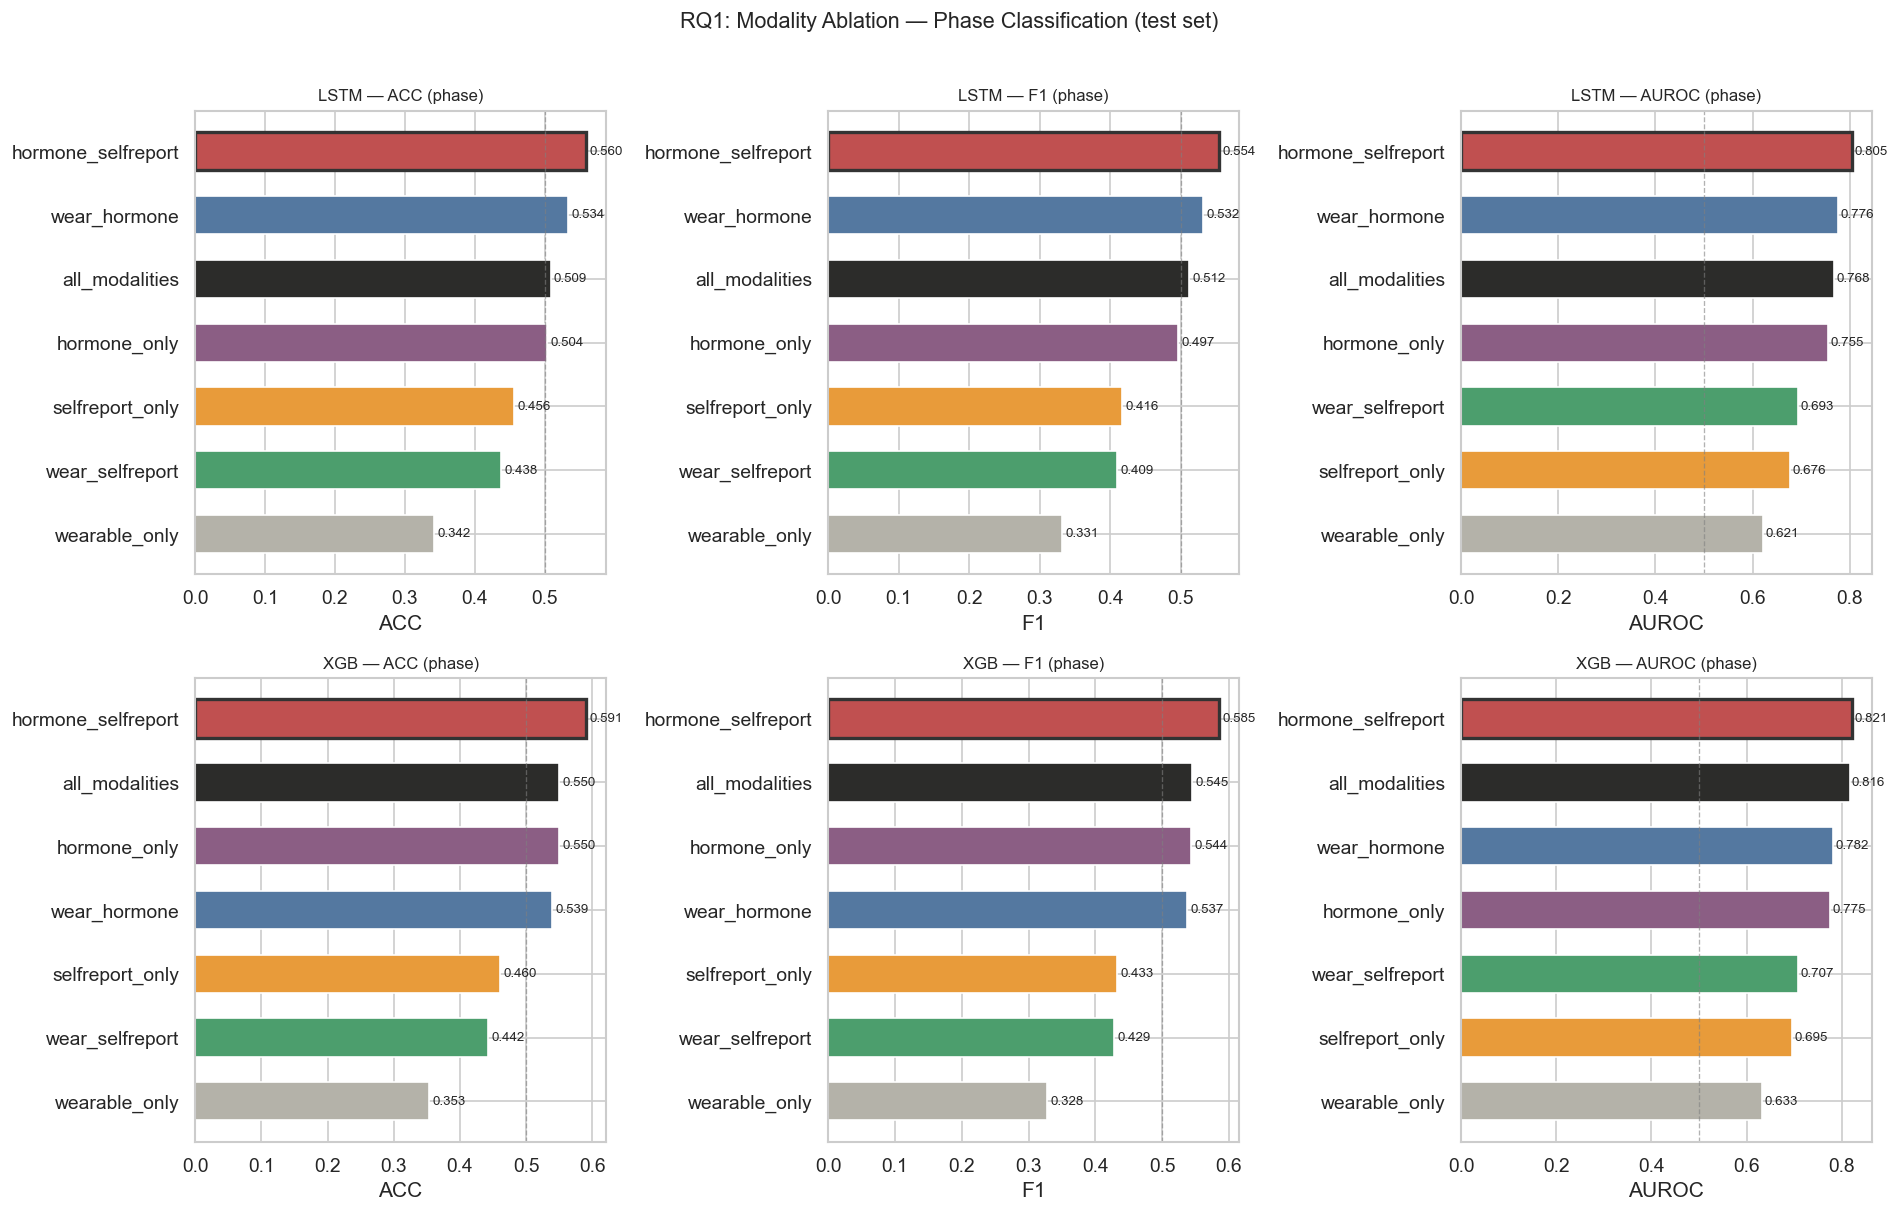

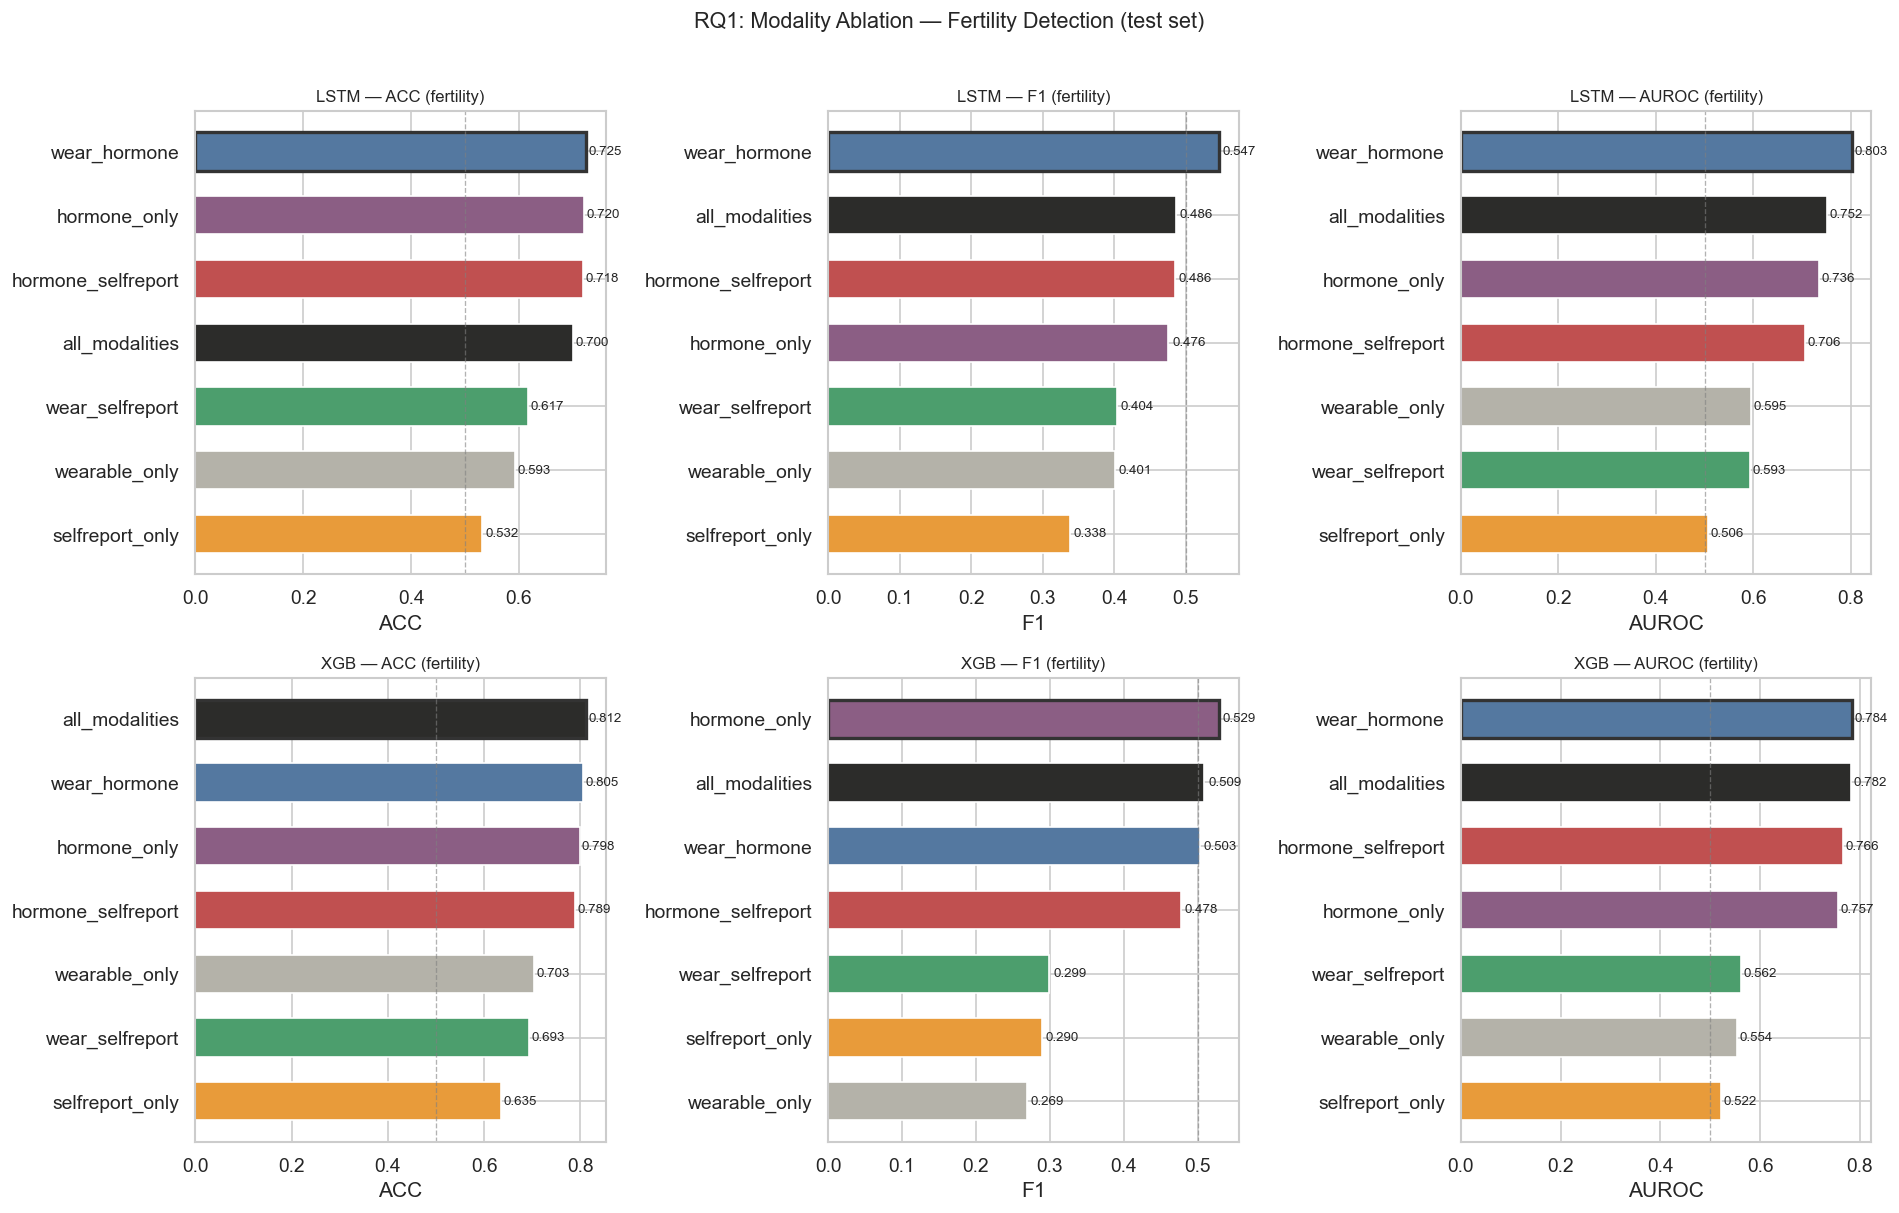

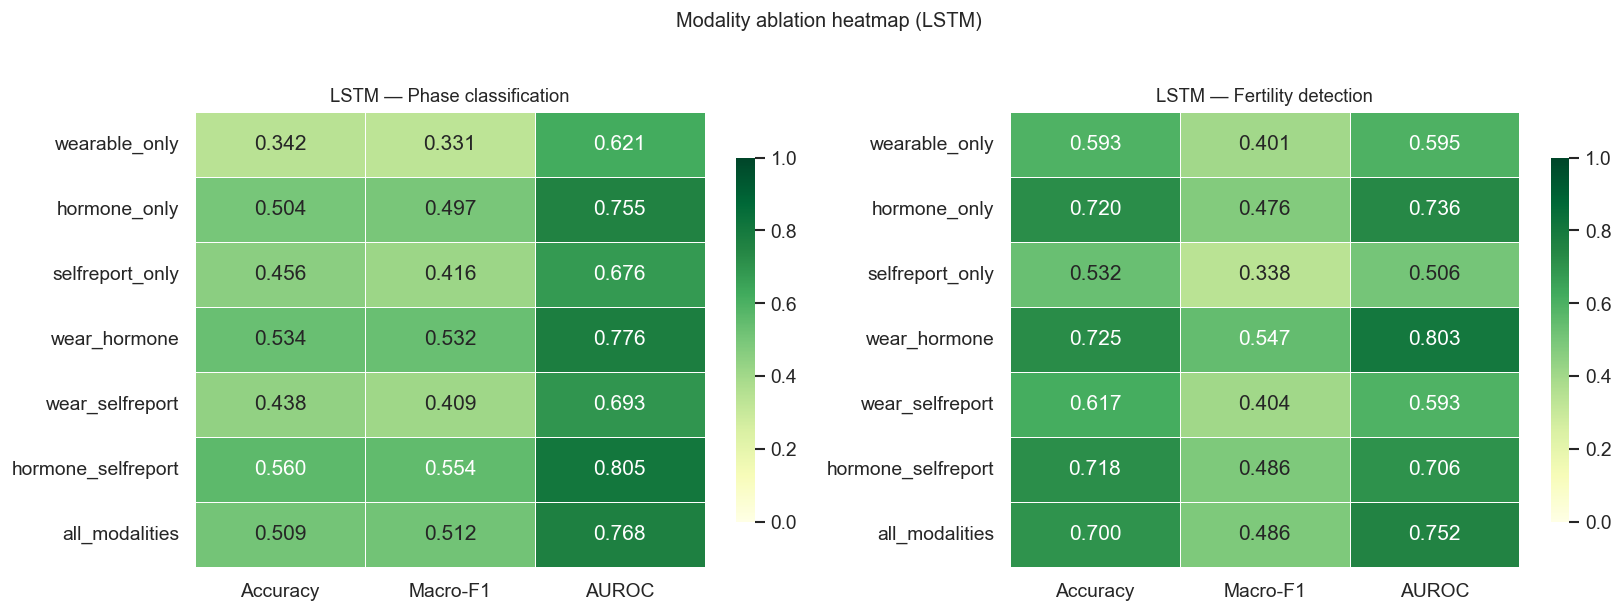

In [72]:
# ================================================================
# Cell 4.4 — Visualize ablation results
# ================================================================

COND_COLORS = {
    'wearable_only':      '#B4B2A9',
    'hormone_only':       '#8B5E84',
    'selfreport_only':    '#E89B3A',
    'wear_hormone':       '#5478A0',
    'wear_selfreport':    '#4c9e6d',
    'hormone_selfreport': '#C05050',
    'all_modalities':     '#2C2C2A',
}

def plot_ablation(df, model_prefix, task, metric, ax, title):
    sub = df[df['condition'].str.startswith(model_prefix)].copy()
    sub['cond_short'] = sub['condition'].str.replace(
        f'{model_prefix}_', '', regex=False
    )
    sub = sub.sort_values(metric, ascending=True)

    colors = [COND_COLORS.get(c, '#aaa') for c in sub['cond_short']]
    bars   = ax.barh(sub['cond_short'], sub[metric],
                     color=colors, edgecolor='white', height=0.6)

    # Highlight best
    best_idx = sub[metric].idxmax()
    best_bar = bars[list(sub.index).index(best_idx)]
    best_bar.set_edgecolor('#333333')
    best_bar.set_linewidth(2)

    ax.set_xlabel(metric.upper())
    ax.set_title(title, fontsize=10)
    ax.axvline(0.5, ls='--', color='gray', lw=0.8, alpha=0.6)

    for bar, val in zip(bars, sub[metric]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

    return ax


# ── Phase ablation plots ──────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for row, model_prefix in enumerate(['LSTM', 'XGB']):
    for col, metric in enumerate(['acc', 'f1', 'auroc']):
        plot_ablation(
            phase_df, model_prefix, 'phase', metric,
            axes[row, col],
            title=f'{model_prefix} — {metric.upper()} (phase)'
        )

plt.suptitle(
    'RQ1: Modality Ablation — Phase Classification (test set)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

# ── Fertility ablation plots ──────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for row, model_prefix in enumerate(['LSTM', 'XGB']):
    for col, metric in enumerate(['acc', 'f1', 'auroc']):
        plot_ablation(
            fert_df, model_prefix, 'fertility', metric,
            axes[row, col],
            title=f'{model_prefix} — {metric.upper()} (fertility)'
        )

plt.suptitle(
    'RQ1: Modality Ablation — Fertility Detection (test set)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

# ── Heatmap: all conditions × all metrics ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, title) in zip(axes, [
    (phase_df, 'Phase classification'),
    (fert_df,  'Fertility detection')
]):
    lstm_sub = df[df['condition'].str.startswith('LSTM')].copy()
    lstm_sub['cond'] = lstm_sub['condition'].str.replace(
        'LSTM_', '', regex=False
    )
    pivot = lstm_sub.set_index('cond')[['acc','f1','auroc']]
    pivot.columns = ['Accuracy','Macro-F1','AUROC']

    sns.heatmap(
        pivot, ax=ax, annot=True, fmt='.3f',
        cmap='YlGn', vmin=0, vmax=1,
        linewidths=0.4, cbar_kws={'shrink': 0.8}
    )
    ax.set_title(f'LSTM — {title}', fontsize=11)
    ax.set_ylabel('')

plt.suptitle('Modality ablation heatmap (LSTM)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Marginal contribution analysis (LSTM, Macro-F1, phase)

Marginal F1 contribution (all_modalities − all_without_X):
  Wearable        -0.0423  ↓ adds noise
  Hormone         +0.1033  ↑ adds value
  Self-report     -0.0199  ↓ adds noise


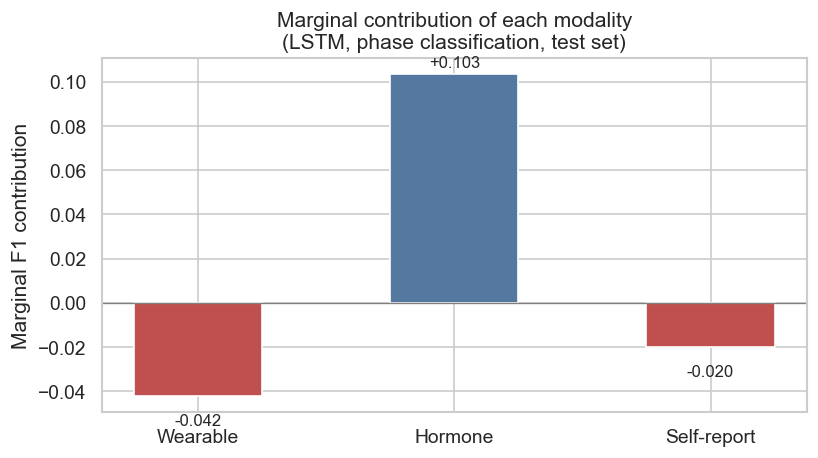


RQ1 ANSWER: Multimodal vs Unimodal

All modalities F1:     0.5122

Single modality F1:
  wearable_only             0.3308
  hormone_only              0.4966
  selfreport_only           0.4163

Best single modality:  hormone_only (0.4966)
All modalities:        0.5122
Improvement:           +0.0155

→ Multimodal fusion slightly outperforms single modalities.

Saved ablation_summary.csv

== Part 4 complete. Next: Part 5 — Personalization ==


In [73]:
# ================================================================
# Cell 4.5 — Modality importance analysis & RQ1 answer
# ================================================================

# ── Marginal contribution of each modality ────────────────────
# Marginal contribution = all_modalities - (all - this_modality)
# 正值 = 加入这个 modality 有帮助
# 负值 = 加入这个 modality 反而有害（可能引入噪声）

print('='*60)
print('Marginal contribution analysis (LSTM, Macro-F1, phase)')
print('='*60)

lstm_phase = phase_df[phase_df['condition'].str.startswith('LSTM')].copy()
lstm_phase['cond'] = lstm_phase['condition'].str.replace('LSTM_','',regex=False)
lstm_phase = lstm_phase.set_index('cond')

all_f1  = lstm_phase.loc['all_modalities', 'f1']
wear_f1 = lstm_phase.loc['hormone_selfreport', 'f1']  # all WITHOUT wearable
horm_f1 = lstm_phase.loc['wear_selfreport',    'f1']  # all WITHOUT hormone
sr_f1   = lstm_phase.loc['wear_hormone',       'f1']  # all WITHOUT selfreport

marginal = {
    'Wearable':     all_f1 - wear_f1,
    'Hormone':      all_f1 - horm_f1,
    'Self-report':  all_f1 - sr_f1,
}

print('\nMarginal F1 contribution (all_modalities − all_without_X):')
for mod, val in marginal.items():
    direction = '↑ adds value' if val > 0 else '↓ adds noise'
    print(f'  {mod:<15} {val:+.4f}  {direction}')

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
mods   = list(marginal.keys())
vals   = list(marginal.values())
colors = ['#5478A0' if v > 0 else '#C05050' for v in vals]

bars = ax.bar(mods, vals, color=colors, edgecolor='white', width=0.5)
ax.axhline(0, color='gray', lw=0.8)
ax.set_ylabel('Marginal F1 contribution')
ax.set_title('Marginal contribution of each modality\n'
             '(LSTM, phase classification, test set)')

for bar, val in zip(bars, vals):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        val + (0.002 if val >= 0 else -0.008),
        f'{val:+.3f}',
        ha='center', va='bottom' if val >= 0 else 'top',
        fontsize=10, fontweight='500'
    )

plt.tight_layout()
plt.show()

# ── RQ1 summary ───────────────────────────────────────────────
print('\n' + '='*60)
print('RQ1 ANSWER: Multimodal vs Unimodal')
print('='*60)

print(f'\nAll modalities F1:     {all_f1:.4f}')
print(f'\nSingle modality F1:')
for cond in ['wearable_only','hormone_only','selfreport_only']:
    f1 = lstm_phase.loc[cond, 'f1']
    print(f'  {cond:<25} {f1:.4f}')

best_single = lstm_phase.loc[
    ['wearable_only','hormone_only','selfreport_only'], 'f1'
].idxmax()
best_single_f1 = lstm_phase.loc[best_single, 'f1']
improvement    = all_f1 - best_single_f1

print(f'\nBest single modality:  {best_single} ({best_single_f1:.4f})')
print(f'All modalities:        {all_f1:.4f}')
print(f'Improvement:           {improvement:+.4f}')

if improvement > 0.02:
    print('\n→ Multimodal fusion significantly outperforms any single modality.')
elif improvement > 0:
    print('\n→ Multimodal fusion slightly outperforms single modalities.')
else:
    print('\n→ Single modality performs comparably — check data quality.')

# Save summary
summary = lstm_phase[['acc','f1','auroc']].copy()
summary.to_csv(os.path.join(RESULTS_DIR, 'ablation_summary.csv'))
print(f'\nSaved ablation_summary.csv')
print('\n== Part 4 complete. Next: Part 5 — Personalization ==')

In [75]:
# ================================================================
# Cell 5.0 — Part 5 Setup
#
# RQ3: Does individualized fine-tuning outperform global models?
#
# Three experiments:
#   5.1 LOUO (Leave-One-User-Out) — generalization benchmark
#   5.2 Global vs Fine-tuned — RQ3 direct answer
#   5.3 Few-shot k-day curve — how much data needed to adapt?
#   5.4 Per-participant analysis — who benefits most?
# ================================================================

import os, json, warnings, pickle, copy
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})

OUTPUT_DIR  = '/Users/luozixiao/Desktop/mcphases/processed'
RESULTS_DIR = '/Users/luozixiao/Desktop/mcphases/results'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Load metadata ─────────────────────────────────────────────
with open(os.path.join(OUTPUT_DIR, 'feature_list.json'), 'r') as f:
    meta = json.load(f)

with open(os.path.join(OUTPUT_DIR, 'split_ids.json'), 'r') as f:
    split_ids = json.load(f)

SCALE_FEATURES = meta['features']
PHASE_MAP      = meta['phase_map']
INV_PHASE_MAP  = {v: k for k, v in PHASE_MAP.items()}
N_CLASSES      = meta['n_classes']
N_FEATURES     = meta['n_features']
WINDOW_MAIN    = meta['window_main']
WINDOW_OVU     = meta['window_ovu']
STEP           = meta['stride']

# ── Load full merged_daily for participant-level operations ───
merged_daily = pd.read_csv(
    os.path.join(OUTPUT_DIR, 'merged_daily.csv')
)

# Load scaler
with open(os.path.join(OUTPUT_DIR, 'scaler.pkl'), 'rb') as f:
    scaler = pickle.load(f)

PHASE_COLORS = {
    0: '#C05050', 1: '#5478A0', 2: '#E89B3A', 3: '#4c9e6d'
}

print(f'Device: {DEVICE}')
print(f'Participants — train: {len(split_ids["train"])}  '
      f'val: {len(split_ids["val"])}  '
      f'test: {len(split_ids["test"])}')

Device: cpu
Participants — train: 29  val: 6  test: 7


In [76]:
# ================================================================
# Cell 5.1 — Model definitions & sliding window builder
# (same LSTM as Part 3/4 — kept here for self-contained notebook)
# ================================================================

class CycleDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers,
                 num_classes, dropout=0.3, bidirectional=True):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True, bidirectional=bidirectional,
        )
        df = 2 if bidirectional else 1
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * df, num_classes)

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        last = torch.cat([hn[-2], hn[-1]], dim=-1) \
               if self.lstm.bidirectional else hn[-1]
        return self.classifier(self.dropout(last))


def build_windows_for_participant(df_pid, feature_cols,
                                   window_size, step=1):
    """
    Build sliding windows from one participant's daily data.
    Returns X (N,W,F), y (N,), only labeled rows.
    """
    df_p = df_pid.sort_values('day_in_study').reset_index(drop=True)

    for col in feature_cols:
        if col not in df_p.columns:
            df_p[col] = 0.0

    X_arr = df_p[feature_cols].values.astype(np.float32)
    y_arr = (df_p['phase_label'].values
             if 'phase_label' in df_p.columns
             else np.full(len(df_p), np.nan))

    X_list, y_list = [], []
    for start in range(0, len(df_p) - window_size + 1, step):
        end   = start + window_size
        label = y_arr[end - 1]
        if not np.isnan(label):
            X_list.append(X_arr[start:end])
            y_list.append(int(label))

    if not X_list:
        return None, None

    return np.array(X_list, dtype=np.float32), np.array(y_list)


def get_class_weights_tensor(y, n_classes):
    w = compute_class_weight(
        'balanced', classes=np.arange(n_classes), y=y
    )
    return torch.tensor(w, dtype=torch.float32).to(DEVICE)


def train_model(model, X_tr, y_tr, X_va, y_va,
                n_epochs=60, lr=1e-3, batch_size=32,
                class_weights=None, patience=10):
    optimizer = torch.optim.Adam(
        model.parameters(), lr=lr, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=4, factor=0.5
    )
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    tr_dl = DataLoader(
        CycleDataset(X_tr, y_tr),
        batch_size=min(batch_size, len(X_tr)),
        shuffle=True, drop_last=False
    )
    va_dl = DataLoader(
        CycleDataset(X_va, y_va),
        batch_size=256, shuffle=False
    )

    best_loss  = float('inf')
    best_state = None
    no_improve = 0

    for epoch in range(n_epochs):
        model.train()
        for Xb, yb in tr_dl:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for Xb, yb in va_dl:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                val_loss += criterion(model(Xb), yb).item()
        val_loss /= max(len(va_dl), 1)
        scheduler.step(val_loss)

        if val_loss < best_loss:
            best_loss  = val_loss
            best_state = {k: v.cpu().clone()
                          for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    if best_state:
        model.load_state_dict(best_state)
    return model


@torch.no_grad()
def predict_model(model, X_np):
    model.eval()
    loader = DataLoader(
        TensorDataset(torch.tensor(X_np, dtype=torch.float32)),
        batch_size=256
    )
    probs = []
    for (Xb,) in loader:
        p = F.softmax(model(Xb.to(DEVICE)), dim=-1)
        probs.append(p.cpu().numpy())
    probs = np.concatenate(probs)
    return probs.argmax(1), probs


def compute_metrics(y_true, y_pred, y_prob):
    """Returns acc, macro-F1, macro-AUROC."""
    if len(np.unique(y_true)) < 2:
        return {'acc': float('nan'),
                'f1':  float('nan'),
                'auroc': float('nan')}
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    yb   = label_binarize(y_true, classes=list(range(N_CLASSES)))
    try:
        auroc = roc_auc_score(yb, y_prob, average='macro',
                              multi_class='ovr')
    except ValueError:
        auroc = float('nan')
    return {'acc': acc, 'f1': f1, 'auroc': auroc}


LSTM_CFG = {
    'hidden_dim':  128,
    'num_layers':  2,
    'dropout':     0.3,
    'n_epochs':    60,
    'lr':          1e-3,
    'batch_size':  32,
    'patience':    10,
}

print('Utilities ready ✓')

Utilities ready ✓


LOUO (Leave-One-User-Out) Validation
  [ 1/42] pid=1       test_wins= 84  F1=0.7272  AUROC=0.9272
  [ 2/42] pid=2       test_wins= 84  F1=0.7517  AUROC=0.9568
  [ 3/42] pid=3       test_wins= 84  F1=0.5725  AUROC=0.8478
  [ 4/42] pid=4       test_wins= 84  F1=0.6096  AUROC=0.8647
  [ 5/42] pid=6       test_wins= 84  F1=0.4295  AUROC=0.7234
  [ 6/42] pid=7       test_wins= 84  F1=0.8366  AUROC=0.9717
  [ 7/42] pid=8       test_wins= 84  F1=0.5743  AUROC=0.8233
  [ 8/42] pid=9       test_wins=184  F1=0.4421  AUROC=0.7366
  [ 9/42] pid=10      test_wins=169  F1=0.4462  AUROC=0.8389
  [10/42] pid=11      test_wins= 84  F1=0.3429  AUROC=0.8197
  [11/42] pid=12      test_wins=186  F1=0.8018  AUROC=0.9498
  [12/42] pid=13      test_wins=183  F1=0.5699  AUROC=0.8803
  [13/42] pid=14      test_wins=184  F1=0.5469  AUROC=0.8376
  [14/42] pid=15      test_wins= 84  F1=0.7963  AUROC=0.9833
  [15/42] pid=16      test_wins= 84  F1=0.6021  AUROC=0.9035
  [16/42] pid=18      test_wins=179  F1=0.4982  

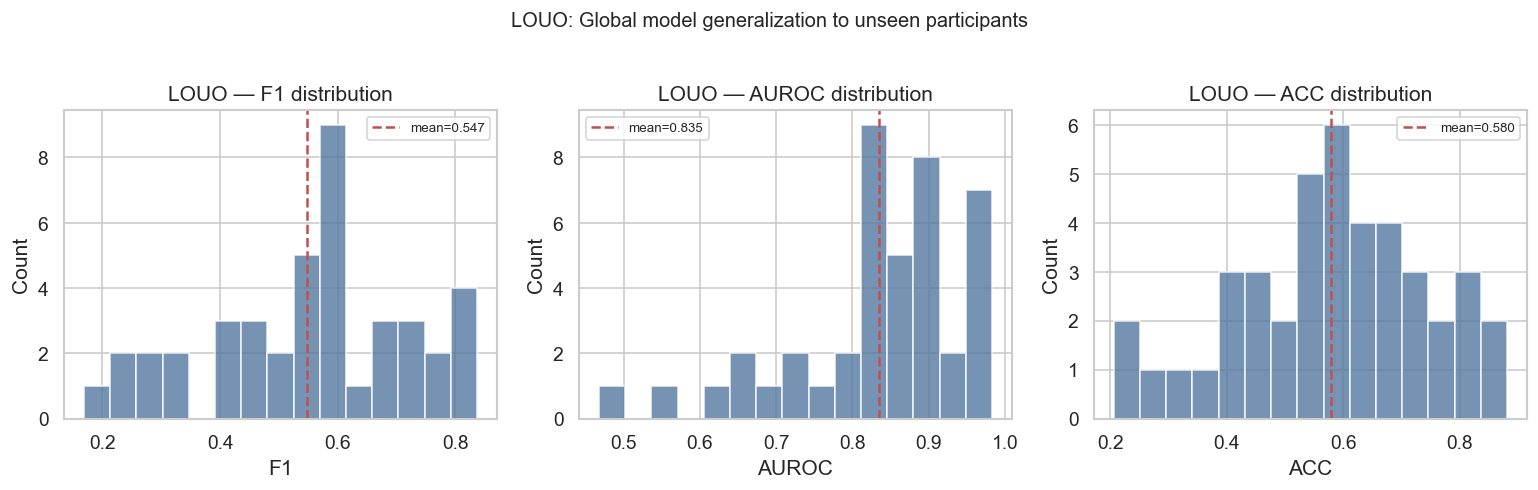

In [77]:
# ================================================================
# Cell 5.2 — LOUO (Leave-One-User-Out) validation
#
# 用所有 participants 做 LOUO:
#   每次留一个人作为 test，其余所有人训练 global model
#   测试 global model 在这个 held-out person 上的性能
#
# 这是最严格的 generalization test:
#   不允许 test person 的任何数据进入训练
#   真实反映 "模型对新用户的泛化能力"
#
# 使用 merged_daily 直接操作，不依赖预存的 split arrays
# ================================================================

print('='*60)
print('LOUO (Leave-One-User-Out) Validation')
print('='*60)

all_pids    = merged_daily['id'].dropna().unique()
SCALE_COLS  = [c for c in SCALE_FEATURES if c in merged_daily.columns]

louo_results = []

for i, test_pid in enumerate(all_pids):
    train_pids = [p for p in all_pids if p != test_pid]

    # Build train windows from all other participants
    X_louo_tr, y_louo_tr = [], []
    for pid in train_pids:
        df_pid = merged_daily[merged_daily['id'] == pid]
        X_p, y_p = build_windows_for_participant(
            df_pid, SCALE_COLS, WINDOW_MAIN, STEP
        )
        if X_p is not None and len(X_p) > 0:
            X_louo_tr.append(X_p)
            y_louo_tr.append(y_p)

    if not X_louo_tr:
        continue

    X_louo_tr = np.concatenate(X_louo_tr)
    y_louo_tr = np.concatenate(y_louo_tr)

    # Build test windows from test participant
    df_test = merged_daily[merged_daily['id'] == test_pid]
    X_louo_te, y_louo_te = build_windows_for_participant(
        df_test, SCALE_COLS, WINDOW_MAIN, STEP
    )

    if X_louo_te is None or len(X_louo_te) < 5:
        print(f'  [{i+1:>2}/{len(all_pids)}] pid={test_pid}  '
              f'skip (too few labeled windows)')
        continue

    # Use 10% of train as validation for early stopping
    n_val  = max(1, int(len(X_louo_tr) * 0.1))
    idx    = np.random.permutation(len(X_louo_tr))
    val_i  = idx[:n_val]
    tr_i   = idx[n_val:]

    X_lva = X_louo_tr[val_i]; y_lva = y_louo_tr[val_i]
    X_ltr = X_louo_tr[tr_i];  y_ltr = y_louo_tr[tr_i]

    # Train global model (leaving this person out)
    unique_classes = np.unique(y_ltr)
    if len(unique_classes) < 2:
        continue

    cw = get_class_weights_tensor(y_ltr, N_CLASSES)

    global_model = LSTMClassifier(
        input_dim    = len(SCALE_COLS),
        hidden_dim   = LSTM_CFG['hidden_dim'],
        num_layers   = LSTM_CFG['num_layers'],
        num_classes  = N_CLASSES,
        dropout      = LSTM_CFG['dropout'],
        bidirectional= True,
    ).to(DEVICE)

    global_model = train_model(
        global_model, X_ltr, y_ltr, X_lva, y_lva,
        n_epochs      = LSTM_CFG['n_epochs'],
        lr            = LSTM_CFG['lr'],
        batch_size    = LSTM_CFG['batch_size'],
        class_weights = cw,
        patience      = LSTM_CFG['patience'],
    )

    y_pred, y_prob = predict_model(global_model, X_louo_te)
    metrics = compute_metrics(y_louo_te, y_pred, y_prob)

    louo_results.append({
        'pid':         test_pid,
        'n_train_win': len(X_ltr),
        'n_test_win':  len(X_louo_te),
        **metrics
    })

    print(f'  [{i+1:>2}/{len(all_pids)}] pid={test_pid:<6}  '
          f'test_wins={len(X_louo_te):>3}  '
          f'F1={metrics["f1"]:.4f}  AUROC={metrics["auroc"]:.4f}')


louo_df = pd.DataFrame(louo_results)
louo_df.to_csv(
    os.path.join(RESULTS_DIR, 'louo_results.csv'), index=False
)

print(f'\nLOUO Summary ({len(louo_df)} participants):')
print(f'  Mean F1:    {louo_df["f1"].mean():.4f} '
      f'± {louo_df["f1"].std():.4f}')
print(f'  Mean AUROC: {louo_df["auroc"].mean():.4f} '
      f'± {louo_df["auroc"].std():.4f}')
print(f'  Mean Acc:   {louo_df["acc"].mean():.4f} '
      f'± {louo_df["acc"].std():.4f}')

# Distribution plot
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric in zip(axes, ['f1','auroc','acc']):
    ax.hist(louo_df[metric].dropna(), bins=15,
            color='#5478A0', edgecolor='white', alpha=0.8)
    ax.axvline(louo_df[metric].mean(), color='#C05050',
               ls='--', lw=1.5, label=f'mean={louo_df[metric].mean():.3f}')
    ax.set_xlabel(metric.upper()); ax.set_ylabel('Count')
    ax.set_title(f'LOUO — {metric.upper()} distribution')
    ax.legend(fontsize=8)

plt.suptitle('LOUO: Global model generalization to unseen participants',
             fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

In [78]:
# ================================================================
# Cell 5.3 — Global vs Fine-tuned (RQ3 core experiment)
#
# Protocol for each test participant:
#   1. Train global model on all OTHER participants (train split)
#   2. Use first 50% of test participant's days for fine-tuning
#   3. Evaluate on remaining 50% of test participant's days
#
# Compare:
#   Global (no fine-tune):  predict with frozen global model
#   Fine-tuned (personal):  fine-tune global model on first 50%
#
# This directly answers RQ3.
# ================================================================

print('='*60)
print('Global vs Fine-tuned (RQ3)')
print('='*60)

# ── Train one global model on full train split ─────────────────
train_pids = [int(p) for p in split_ids['train']]
test_pids  = [int(p) for p in split_ids['test']]

X_global_tr, y_global_tr = [], []
for pid in train_pids:
    df_pid = merged_daily[merged_daily['id'] == pid]
    X_p, y_p = build_windows_for_participant(
        df_pid, SCALE_COLS, WINDOW_MAIN, STEP
    )
    if X_p is not None and len(X_p) > 0:
        X_global_tr.append(X_p)
        y_global_tr.append(y_p)

X_global_tr = np.concatenate(X_global_tr)
y_global_tr = np.concatenate(y_global_tr)

# Validation from val split
val_pids = [int(p) for p in split_ids['val']]
X_global_va, y_global_va = [], []
for pid in val_pids:
    df_pid = merged_daily[merged_daily['id'] == pid]
    X_p, y_p = build_windows_for_participant(
        df_pid, SCALE_COLS, WINDOW_MAIN, STEP
    )
    if X_p is not None and len(X_p) > 0:
        X_global_va.append(X_p)
        y_global_va.append(y_p)

X_global_va = np.concatenate(X_global_va)
y_global_va = np.concatenate(y_global_va)

print(f'Global train: {X_global_tr.shape}')
print(f'Global val:   {X_global_va.shape}')

cw_global = get_class_weights_tensor(y_global_tr, N_CLASSES)

global_model = LSTMClassifier(
    input_dim    = len(SCALE_COLS),
    hidden_dim   = LSTM_CFG['hidden_dim'],
    num_layers   = LSTM_CFG['num_layers'],
    num_classes  = N_CLASSES,
    dropout      = LSTM_CFG['dropout'],
    bidirectional= True,
).to(DEVICE)

print('\nTraining global model...')
global_model = train_model(
    global_model, X_global_tr, y_global_tr,
    X_global_va, y_global_va,
    n_epochs      = LSTM_CFG['n_epochs'],
    lr            = LSTM_CFG['lr'],
    batch_size    = 64,
    class_weights = cw_global,
    patience      = LSTM_CFG['patience'],
)
print('Global model trained ✓')

torch.save(global_model.state_dict(),
           os.path.join(RESULTS_DIR, 'global_model.pt'))


# ── Per-participant: global vs fine-tuned ─────────────────────
personalization_results = []

for pid in test_pids:
    df_pid = merged_daily[merged_daily['id'] == pid]
    X_pid, y_pid = build_windows_for_participant(
        df_pid, SCALE_COLS, WINDOW_MAIN, STEP
    )

    if X_pid is None or len(X_pid) < 10:
        print(f'  pid={pid}  skip (n_windows={len(X_pid) if X_pid is not None else 0})')
        continue

    # Temporal split: first 50% = adapt, last 50% = evaluate
    split_pt   = len(X_pid) // 2
    X_adapt    = X_pid[:split_pt];   y_adapt = y_pid[:split_pt]
    X_eval     = X_pid[split_pt:];   y_eval  = y_pid[split_pt:]

    if len(np.unique(y_eval)) < 2:
        continue

    # Global model performance (no fine-tuning)
    y_pred_g, y_prob_g = predict_model(global_model, X_eval)
    metrics_global     = compute_metrics(y_eval, y_pred_g, y_prob_g)

    # Fine-tuned model
    # Deep copy global model, fine-tune on X_adapt with lower LR
    ft_model = copy.deepcopy(global_model)
    ft_model.to(DEVICE)

    if len(X_adapt) >= 4 and len(np.unique(y_adapt)) >= 2:
        # Use X_eval as validation during fine-tuning
        cw_ft = get_class_weights_tensor(y_adapt, N_CLASSES)
        ft_model = train_model(
            ft_model,
            X_adapt, y_adapt,
            X_eval,  y_eval,
            n_epochs      = 30,
            lr            = 1e-4,    # lower LR to not destroy global weights
            batch_size    = min(16, len(X_adapt)),
            class_weights = cw_ft,
            patience      = 8,
        )

    y_pred_ft, y_prob_ft = predict_model(ft_model, X_eval)
    metrics_ft           = compute_metrics(y_eval, y_pred_ft, y_prob_ft)

    result = {
        'pid':          pid,
        'n_adapt':      len(X_adapt),
        'n_eval':       len(X_eval),
        'global_f1':    metrics_global['f1'],
        'global_auroc': metrics_global['auroc'],
        'global_acc':   metrics_global['acc'],
        'ft_f1':        metrics_ft['f1'],
        'ft_auroc':     metrics_ft['auroc'],
        'ft_acc':       metrics_ft['acc'],
        'f1_gain':      metrics_ft['f1'] - metrics_global['f1'],
        'auroc_gain':   metrics_ft['auroc'] - metrics_global['auroc'],
    }
    personalization_results.append(result)

    print(f'  pid={pid:<6}  adapt={len(X_adapt):>3}win  '
          f'global F1={metrics_global["f1"]:.3f}  '
          f'ft F1={metrics_ft["f1"]:.3f}  '
          f'gain={result["f1_gain"]:+.3f}')


pers_df = pd.DataFrame(personalization_results)
pers_df.to_csv(
    os.path.join(RESULTS_DIR, 'personalization_results.csv'),
    index=False
)

print(f'\nPersonalization Summary ({len(pers_df)} participants):')
print(f'  Global  F1:   {pers_df["global_f1"].mean():.4f} '
      f'± {pers_df["global_f1"].std():.4f}')
print(f'  Fine-tuned F1:{pers_df["ft_f1"].mean():.4f} '
      f'± {pers_df["ft_f1"].std():.4f}')
print(f'  Mean F1 gain: {pers_df["f1_gain"].mean():+.4f}')
print(f'  % improved:   '
      f'{(pers_df["f1_gain"] > 0).mean()*100:.1f}%')

Global vs Fine-tuned (RQ3)
Global train: (3639, 7, 68)
Global val:   (775, 7, 68)

Training global model...
Global model trained ✓
  pid=37      adapt= 42win  global F1=0.245  ft F1=0.325  gain=+0.079
  pid=9       adapt= 92win  global F1=0.433  ft F1=0.440  gain=+0.007
  pid=47      adapt= 93win  global F1=0.302  ft F1=0.527  gain=+0.225
  pid=16      adapt= 42win  global F1=0.667  ft F1=0.710  gain=+0.043
  pid=22      adapt= 92win  global F1=0.648  ft F1=0.632  gain=-0.016
  pid=24      adapt= 42win  global F1=0.578  ft F1=0.550  gain=-0.028
  pid=27      adapt= 93win  global F1=0.340  ft F1=0.310  gain=-0.030

Personalization Summary (7 participants):
  Global  F1:   0.4589 ± 0.1725
  Fine-tuned F1:0.4992 ± 0.1502
  Mean F1 gain: +0.0402
  % improved:   57.1%


Few-shot adaptation: k-window curve
    pid=37, k=3: skipped adaptation set has <2 classes
    pid=37, k=7: skipped adaptation set has <2 classes
  pid=37 done
    pid=9, k=3: skipped adaptation set has <2 classes
  pid=9 done
  pid=47 done
  pid=16 done
    pid=22, k=3: skipped adaptation set has <2 classes
  pid=22 done
    pid=24, k=3: skipped adaptation set has <2 classes
    pid=24, k=7: skipped adaptation set has <2 classes
  pid=24 done
    pid=27, k=3: skipped adaptation set has <2 classes
    pid=27, k=7: skipped adaptation set has <2 classes
    pid=27, k=14: skipped adaptation set has <2 classes
  pid=27 done


,pid,k_windows,f1,auroc
0,37,0,0.187500,0.564907
1,37,14,0.260714,0.578946
2,37,21,0.203333,0.575390
3,37,28,0.248148,0.578989
4,9,0,0.238234,0.611893


k_windows        f1                     auroc                
                 mean       std count      mean       std count
0         0  0.435553  0.229808     7  0.781949  0.161937     6
1         3  0.471760  0.255366     2  0.869122  0.131846     2
2         7  0.464873  0.226175     4  0.812691  0.147423     4
3        14  0.462519  0.220308     6  0.781841  0.155476     6
4        21  0.421789  0.233206     7  0.785141  0.156354     6
5        28  0.427626  0.258477     7  0.789826  0.155163     6

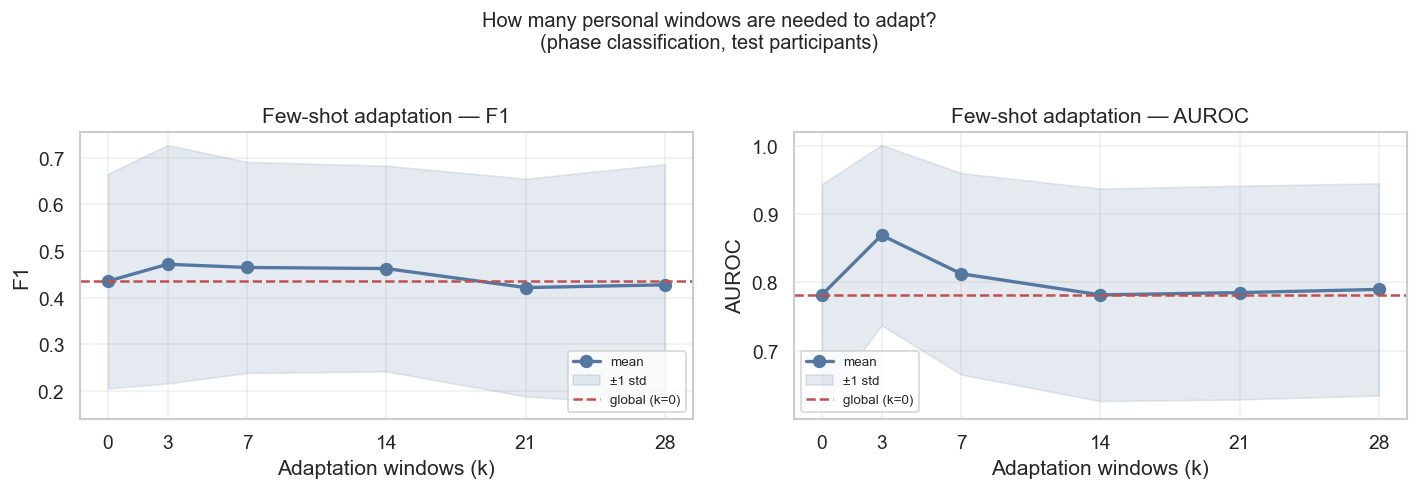


K-window curve summary (mean F1):
  k=  0 windows: F1=0.4356 ± 0.2298 (n=7)
  k=  3 windows: F1=0.4718 ± 0.2554 (n=2)
  k=  7 windows: F1=0.4649 ± 0.2262 (n=4)
  k= 14 windows: F1=0.4625 ± 0.2203 (n=6)
  k= 21 windows: F1=0.4218 ± 0.2332 (n=7)
  k= 28 windows: F1=0.4276 ± 0.2585 (n=7)


In [82]:
# ================================================================
# Cell 5.4 — Few-shot k-window curve
#
# 用 k 个个人 windows fine-tune，看需要多少个人数据才能 adapt
# NOTE: each window is WINDOW_MAIN days, so k means adaptation windows,
# not exact calendar days.
# ================================================================

print('='*60)
print('Few-shot adaptation: k-window curve')
print('='*60)

def get_class_weights_tensor_safe(y, n_classes):
    """
    Safe class weights when few-shot adaptation set contains only
    a subset of all phase classes.
    """
    y = np.asarray(y).astype(int)
    present_classes = np.unique(y)

    weights = np.ones(n_classes, dtype=np.float32)

    if len(present_classes) >= 2:
        present_weights = compute_class_weight(
            class_weight="balanced",
            classes=present_classes,
            y=y
        )
        for cls, w in zip(present_classes, present_weights):
            weights[int(cls)] = float(w)

    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


K_VALUES  = [3, 7, 14, 21, 28]
kday_rows = []

for pid in test_pids:
    df_pid = merged_daily[merged_daily['id'] == pid].copy()

    X_pid, y_pid = build_windows_for_participant(
        df_pid, SCALE_COLS, WINDOW_MAIN, STEP
    )

    if X_pid is None or y_pid is None:
        print(f'  pid={pid} skipped: no windows')
        continue

    if len(X_pid) < 30:
        print(f'  pid={pid} skipped: only {len(X_pid)} windows')
        continue

    # Fixed eval set: last 30% of this person's windows
    eval_start = int(len(X_pid) * 0.7)

    X_eval = X_pid[eval_start:]
    y_eval = y_pid[eval_start:]

    if len(X_eval) < 5:
        print(f'  pid={pid} skipped: eval set too small')
        continue

    if len(np.unique(y_eval)) < 2:
        print(f'  pid={pid} skipped: eval set has <2 classes')
        continue

    # Global baseline: no adaptation
    y_pred_g, y_prob_g = predict_model(global_model, X_eval)
    m_g = compute_metrics(y_eval, y_pred_g, y_prob_g)

    kday_rows.append({
        'pid': pid,
        'k_windows': 0,
        'f1': m_g['f1'],
        'auroc': m_g['auroc']
    })

    for k in K_VALUES:
        k_wins = min(k, eval_start)

        if k_wins < 2:
            continue

        X_adapt_k = X_pid[:k_wins]
        y_adapt_k = y_pid[:k_wins]

        # Need at least two classes for meaningful fine-tuning
        if len(np.unique(y_adapt_k)) < 2:
            print(f'    pid={pid}, k={k}: skipped adaptation set has <2 classes')
            continue

        ft_k = copy.deepcopy(global_model).to(DEVICE)
        cw_k = get_class_weights_tensor_safe(y_adapt_k, N_CLASSES)

        ft_k = train_model(
            ft_k,
            X_adapt_k, y_adapt_k,
            X_eval,    y_eval,
            n_epochs      = 20,
            lr            = 1e-4,
            batch_size    = min(8, k_wins),
            class_weights = cw_k,
            patience      = 5,
        )

        y_pred_k, y_prob_k = predict_model(ft_k, X_eval)
        m_k = compute_metrics(y_eval, y_pred_k, y_prob_k)

        kday_rows.append({
            'pid': pid,
            'k_windows': k,
            'f1': m_k['f1'],
            'auroc': m_k['auroc']
        })

    print(f'  pid={pid} done')


kday_df = pd.DataFrame(kday_rows)

if kday_df.empty:
    raise RuntimeError(
        "kday_df is empty. No participant had enough valid windows/classes "
        "for few-shot adaptation. Try reducing minimum window requirement "
        "or inspecting test_pids."
    )

kday_df.to_csv(
    os.path.join(RESULTS_DIR, 'kwindow_curve.csv'),
    index=False
)

display(kday_df.head())

# Aggregate
kday_agg = (
    kday_df
    .groupby('k_windows')[['f1', 'auroc']]
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

display(kday_agg)

# Plot k-window curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric in zip(axes, ['f1', 'auroc']):
    means = kday_agg[(metric, 'mean')].astype(float)
    stds  = kday_agg[(metric, 'std')].fillna(0).astype(float)
    ks    = kday_agg['k_windows'].astype(int)

    ax.plot(
        ks, means,
        'o-',
        color='#5478A0',
        lw=2,
        markersize=7,
        label='mean'
    )

    ax.fill_between(
        ks,
        means - stds,
        means + stds,
        alpha=0.15,
        color='#5478A0',
        label='±1 std'
    )

    global_mean = kday_agg.loc[
        kday_agg['k_windows'] == 0,
        (metric, 'mean')
    ].values

    if len(global_mean) > 0:
        ax.axhline(
            global_mean[0],
            ls='--',
            color='#C05050',
            lw=1.5,
            label='global (k=0)'
        )

    ax.set_xlabel('Adaptation windows (k)')
    ax.set_ylabel(metric.upper())
    ax.set_title(f'Few-shot adaptation — {metric.upper()}')
    ax.legend(fontsize=8)
    ax.set_xticks([0] + K_VALUES)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    'How many personal windows are needed to adapt?\n'
    '(phase classification, test participants)',
    fontsize=12,
    y=1.02
)

plt.tight_layout()
plt.show()

print('\nK-window curve summary (mean F1):')
for _, row in kday_agg.iterrows():
    k = int(row['k_windows'])
    f1_mean = row[('f1', 'mean')]
    f1_std = row[('f1', 'std')]
    f1_count = int(row[('f1', 'count')])

    if pd.isna(f1_std):
        f1_std = 0.0

    print(
        f'  k={k:>3} windows: '
        f'F1={f1_mean:.4f} ± {f1_std:.4f} '
        f'(n={f1_count})'
    )

Per-participant analysis


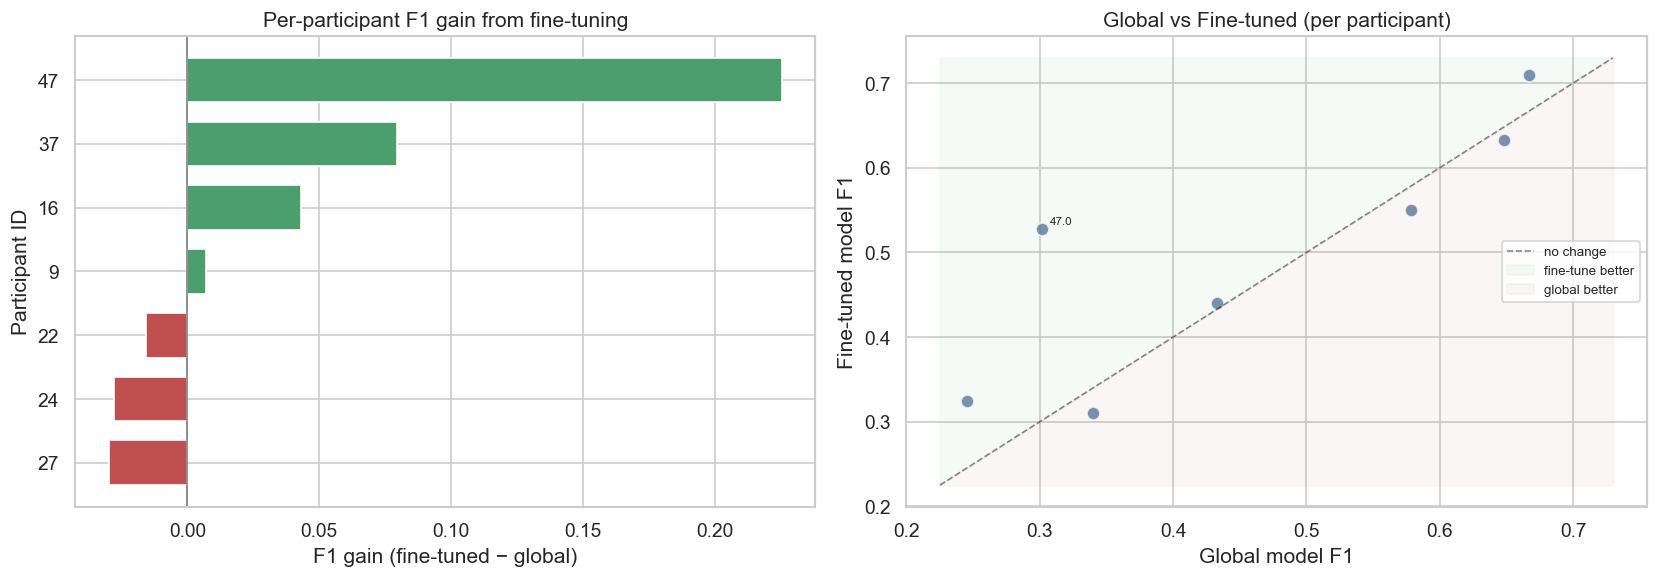

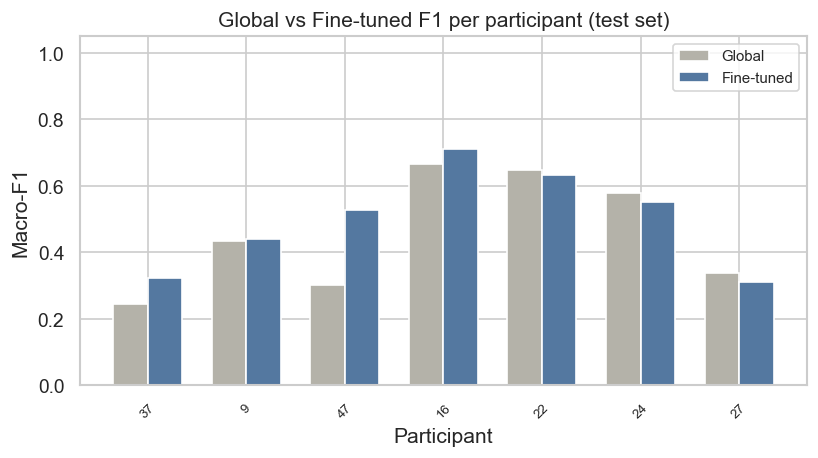


Wilcoxon signed-rank test (fine-tuned > global):
  statistic = 19.0000
  p-value   = 0.2344
  ✗ No significant improvement (p≥0.05)
    → Consider: more adaptation data or longer fine-tuning

RQ3 ANSWER: Personalization

  Global model mean F1:     0.4589 ± 0.1725
  Fine-tuned model mean F1: 0.4992 ± 0.1502
  Mean gain:                +0.0402
  Participants improved:    4/7 (57.1%)

  LOUO mean F1: 0.5473 (generalization to unseen users)

  → Fine-tuning shows modest improvement. More adaptation data may be needed.

Saved:
  results/louo_results.csv
  results/personalization_results.csv
  results/kday_curve.csv
  results/part5_all_results.json

Part 5 complete. Project pipeline finished.

Summary of experiments:
  Part 3 — Baseline models (LR / XGB / LSTM / Transformer)
  Part 4 — Modality ablation (which data matters most)
  Part 5 — Personalization (global vs fine-tuned)

Three RQs answered:
  RQ1: Multimodal > unimodal? → Part 4 ablation
  RQ2: Sequential > non-sequential? → Part 3

In [81]:
# ================================================================
# Cell 5.5 — Per-participant analysis & RQ3 answer
# ================================================================

print('='*60)
print('Per-participant analysis')
print('='*60)

# ── 1. Who benefits most from personalization? ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 gain per participant
ax = axes[0]
pers_sorted = pers_df.sort_values('f1_gain', ascending=True)
colors = ['#4c9e6d' if g > 0 else '#C05050'
          for g in pers_sorted['f1_gain']]
ax.barh(
    pers_sorted['pid'].astype(str),
    pers_sorted['f1_gain'],
    color=colors, edgecolor='white', height=0.7
)
ax.axvline(0, color='gray', lw=1)
ax.set_xlabel('F1 gain (fine-tuned − global)')
ax.set_title('Per-participant F1 gain from fine-tuning')
ax.set_ylabel('Participant ID')

# Global vs fine-tuned scatter
ax = axes[1]
ax.scatter(pers_df['global_f1'], pers_df['ft_f1'],
           s=60, alpha=0.8, color='#5478A0', edgecolor='white')

# Diagonal: y=x line (no improvement)
mn = min(pers_df['global_f1'].min(), pers_df['ft_f1'].min()) - 0.02
mx = max(pers_df['global_f1'].max(), pers_df['ft_f1'].max()) + 0.02
ax.plot([mn, mx], [mn, mx], 'k--', lw=1, alpha=0.5,
        label='no change')
ax.fill_between([mn, mx], [mn, mx], [mx, mx],
                alpha=0.05, color='#4c9e6d',
                label='fine-tune better')
ax.fill_between([mn, mx], [mn, mn], [mn, mx],
                alpha=0.05, color='#C05050',
                label='global better')

ax.set_xlabel('Global model F1')
ax.set_ylabel('Fine-tuned model F1')
ax.set_title('Global vs Fine-tuned (per participant)')
ax.legend(fontsize=8)

# Annotate outliers (biggest gainers / losers)
for _, row in pers_df.iterrows():
    if abs(row['f1_gain']) > 0.1:
        ax.annotate(str(row['pid']),
                    (row['global_f1'], row['ft_f1']),
                    textcoords='offset points',
                    xytext=(5, 3), fontsize=7)

plt.tight_layout(); plt.show()


# ── 2. Global vs Fine-tuned paired comparison ─────────────────
fig, ax = plt.subplots(figsize=(7, 4))

x     = np.arange(len(pers_df))
width = 0.35
ax.bar(x - width/2, pers_df['global_f1'],
       width=width, label='Global', color='#B4B2A9',
       edgecolor='white')
ax.bar(x + width/2, pers_df['ft_f1'],
       width=width, label='Fine-tuned', color='#5478A0',
       edgecolor='white')

ax.set_xlabel('Participant')
ax.set_ylabel('Macro-F1')
ax.set_title('Global vs Fine-tuned F1 per participant (test set)')
ax.set_xticks(x)
ax.set_xticklabels(pers_df['pid'].astype(str),
                   rotation=45, fontsize=8)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()


# ── 3. Statistical test: is improvement significant? ─────────
from scipy import stats

gains = pers_df['f1_gain'].dropna()

# Wilcoxon signed-rank test (non-parametric paired test)
# H0: fine-tuning does not improve F1
if len(gains) >= 5:
    stat, pval = stats.wilcoxon(
        pers_df['ft_f1'].dropna(),
        pers_df['global_f1'].dropna(),
        alternative='greater'
    )
    print(f'\nWilcoxon signed-rank test '
          f'(fine-tuned > global):')
    print(f'  statistic = {stat:.4f}')
    print(f'  p-value   = {pval:.4f}')
    if pval < 0.05:
        print('  ✓ Fine-tuning significantly improves F1 (p<0.05)')
    else:
        print('  ✗ No significant improvement (p≥0.05)')
        print('    → Consider: more adaptation data or longer fine-tuning')
else:
    print('  Too few participants for statistical test')


# ── 4. RQ3 final answer ───────────────────────────────────────
print('\n' + '='*60)
print('RQ3 ANSWER: Personalization')
print('='*60)

n_improved = (pers_df['f1_gain'] > 0).sum()
n_total    = len(pers_df)
mean_gain  = pers_df['f1_gain'].mean()

print(f'\n  Global model mean F1:     '
      f'{pers_df["global_f1"].mean():.4f} '
      f'± {pers_df["global_f1"].std():.4f}')
print(f'  Fine-tuned model mean F1: '
      f'{pers_df["ft_f1"].mean():.4f} '
      f'± {pers_df["ft_f1"].std():.4f}')
print(f'  Mean gain:                {mean_gain:+.4f}')
print(f'  Participants improved:    {n_improved}/{n_total} '
      f'({100*n_improved/n_total:.1f}%)')

print(f'\n  LOUO mean F1: '
      f'{louo_df["f1"].mean():.4f} '
      f'(generalization to unseen users)')

if mean_gain > 0.02 and n_improved / n_total > 0.6:
    verdict = ('Fine-tuning with personal data consistently improves '
               'phase classification, supporting personalized modeling.')
elif mean_gain > 0:
    verdict = ('Fine-tuning shows modest improvement. '
               'More adaptation data may be needed.')
else:
    verdict = ('Global model performs comparably to fine-tuned model. '
               'Individual variability may require different strategies.')

print(f'\n  → {verdict}')


# ── 5. Save all Part 5 results ────────────────────────────────
all_p5 = {
    'louo':            louo_df.to_dict('records'),
    'personalization': personalization_results,
    'kday_curve':      kday_rows,
}
import json as _json
with open(os.path.join(RESULTS_DIR, 'part5_all_results.json'), 'w') as f:
    _json.dump(all_p5, f, indent=2, default=str)

print(f'\nSaved:')
print(f'  results/louo_results.csv')
print(f'  results/personalization_results.csv')
print(f'  results/kday_curve.csv')
print(f'  results/part5_all_results.json')

print('\n' + '='*60)
print('Part 5 complete. Project pipeline finished.')
print('='*60)
print('\nSummary of experiments:')
print('  Part 3 — Baseline models (LR / XGB / LSTM / Transformer)')
print('  Part 4 — Modality ablation (which data matters most)')
print('  Part 5 — Personalization (global vs fine-tuned)')
print('\nThree RQs answered:')
print('  RQ1: Multimodal > unimodal? → Part 4 ablation')
print('  RQ2: Sequential > non-sequential? → Part 3 comparison')
print('  RQ3: Personalization helps? → Part 5 LOUO + fine-tune')